# Class Prediction
**Background**  
- 【背景】カフェチェーンの需要予測とCRM最適化
  - あるカフェチェーン。10店舗（Store A〜J）、1万人規模のアプリ会員を持つ
  - 「ラテ」の販促キャンペーンを本部にて検討中。的確な需要予測と合理的説明をもって店舗の支持を得ながら進行したい
- 【課題】利益の最大化、店舗オペレーションの最適化、本部提案の納得感
  - 過去の失敗経験: 昨年の同様企画では予測精度が不十分で、店舗の理解も得られず、期待を下回る結果だった
  - 予算の制約: 以前にも増して本部販促費の投資対効果が注視されており、次回施策のためにも予測精度は担保したい
  - 店舗の裁量: 発注やシフト作成は店舗判断のため、納得感ある説明および行動しやすい判断材料が求められている
  
- 【問題の設定】分類予測（誰がラテを購入するかを予測する）
  - クーポン配布という施策内容に反応しやすい顧客層を特定することでROIを最大化しつつ、予測の理由を解釈しやすい判断材料を提供する
- 【解法】LGBM, Tabular DLなど
（仮案）
1. LightGBMで素早く初動回答することで、関係者合意を取り付けやすい土壌を作りやすい企画進行を支援する
1. GBDTやTabular DLなども使うことで、説明可能性や予測精度を検証
1. hoge



- 【テーマ】
  - あるカフェチェーン。都心近郊に10店舗をドミナント展開、1万人規模の自社アプリ会員を持つ。
  - アプリ会員はお店での注文時は必ずアプリを提示する。来店せずともアプリを閲覧することはある。来店せずともアプリ会員登録は可能。
  - 主にアプリ新規・ライト会員を対象にした、「明日（来店したとしたら）ラテを購入するかどうか（1/0）」の需要予測およびロイヤル化の兆候検知
- 【実務のストーリー】
  - まだ行動が定まっていないライト会員の中から、明日ラテを買う確率（LGBMの予測値）が高い人をスクリーニングする。
  - 明日来店するとしたら「買う」と予測されたライト会員は、まさに今熱量が上がっている「未来の優良顧客の卵」。
  - 彼らが明日来店した瞬間に、店舗で最高の体験（おもてなし）を提供して常連客にロックインする。　

In [1]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# import scipy
import sklearn
import shap
import lightgbm as lgb
# import xgboost as xgb

# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
import sys;print("Python", sys.version.split()[0])
import platform;print("OS", platform.platform())
print("is_google_colab:", "google.colab" in sys.modules)
from importlib.metadata import version
packages = [
"pandas",
"numpy",
"matplotlib",
"seaborn",
"scikit-learn",
"shap",
"lightgbm",
]
for pkg in packages:
    try:
        print(pkg, version(pkg))
    except Exception as e:
        print(pkg, "not installed")

Created(JST) 2026-06-12 18:04:07
Python 3.11.15
OS macOS-26.5.1-arm64-arm-64bit
is_google_colab: False
pandas 3.0.2
numpy 2.4.3
matplotlib 3.10.9
seaborn 0.13.2
scikit-learn 1.8.0
shap 0.51.0
lightgbm 4.6.0


サンプルデータの設定  
- 配下10店舗それぞれの過去3ヶ月の、顧客別ラテ注文実績＋関連データ
- 結果変数 is_purchased: 顧客がその日にラテを購入したかどうかの二値
- 予測には役立ちそうもない特徴量を混ぜたり、一部を欠損値にしたりゴミを混ぜたりしている（現実データっぽい感じにしつつ、素早く初動回答するにあたり最低限のデータクリーニングチェックすることを意図）


In [2]:
# # # サンプルのdataframeを生成する
# import string

# # --- 基本設定 ---
# # start_date = pd.to_datetime("2025-09-01")  # 開始日
# # n_days = 92  # 3ヶ月分くらいある設定にする
# # n_stores = 10  # 10店舗くらいある設定にする
# # n_customers = 10000  # 顧客は10000人くらい


# def generate_cafe_data_v3(n_days=92, n_stores=10, n_customers=10000):
#     np.random.seed(42)
    
#     # --- 1. マスタ作成 ---
#     store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
#     dates = pd.date_range(start='2025-09-01', periods=n_days)
    
#     # 顧客マスタ（10,000人）
#     chars = list(string.ascii_lowercase + string.digits)
#     unique_customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
#     customer_master = pd.DataFrame({
#         'customer_id': unique_customer_ids,
#         # 会員歴（年）: 指数分布っぽく（新しい人の方が多い）
#         'membership_years': np.random.exponential(2, n_customers).clip(0.5, 10),
#         # 過去のラテ購入率（潜在的な好みの代理指標: 存在しなくて自前で用意、定義すべきような指標かも）0.1〜0.9の間で分布
#         'past_latte_ratio': np.random.beta(2, 5, n_customers),
#         # 過去のクーポン利用率（感度の代理指標）
#         'past_coupon_usage_rate': np.random.beta(1, 3, n_customers)
#     })

#     # 店舗×日付単位の外部環境マスタを作成
#     env_data = []
#     for d in dates:
#         is_raining = np.random.binomial(1, 0.20)  # 20%の確率で雨の日
#         is_weekend = 1 if d.dayofweek >= 5 else 0
#         daily_temp_base = 15 + (d.day % 5)  # 15〜19度
        
#         for s in store_ids:
#             env_data.append({
#                 'date': d,
#                 'store_id': s,
#                 'is_raining': is_raining,
#                 'is_weekend': is_weekend,
#                 'current_temp': daily_temp_base + np.random.normal(0, 0.5),
#                 # わざと役立ちそうにない特徴量を含める
#                 'station_congestion_index': np.random.normal(100, 15),  # 各店舗の最寄駅のその日の混雑度
#                 'daily_staffing_cost': np.random.randint(50000, 150000)  # 各店舗のその日の人件費
#             })
#     df_env = pd.DataFrame(env_data)

#     # --- 2. 来店イベントの生成 ---
#     # 各顧客が期間中に合計何回来店するか（ポアソン分布でバラつきを出す）
#     # customer_master['total_visits'] = np.random.poisson(8, n_customers)  # 平均8回来店
#     avg_visits_per_7days = 3  # 7日で平均3回来店する設定
#     lambda_visits = (avg_visits_per_7days / 7) * n_days  # 1日あたりの来店回数×全期間=期間中の合計来店回数
#     customer_master['total_visits'] = np.random.poisson(lambda_visits, n_customers)

#     all_visits = []
#     for _, row in customer_master.iterrows():
#         if row['total_visits'] == 0: continue
        
#         # 来店回数分だけ行を生成
#         for _ in range(row['total_visits']):
#             all_visits.append({
#                 'customer_id': row['customer_id'],
#                 'date': np.random.choice(dates),  # ランダムな日に来店
#                 'store_id': np.random.choice(store_ids)  # ランダムな店に来店
#             })
    
#     df_main = pd.DataFrame(all_visits)
#     # マスタとマージ
#     df = df_main.merge(customer_master.drop(columns='total_visits'), on='customer_id')
#     df = df.merge(df_env, on=['date', 'store_id'])

#     # --- 3. 購買ロジックの適用 ---
#     # 店舗ごとの地力（固定効果）
#     store_bias = {s: np.random.normal(0, 0.8) for s in store_ids}
    
#     # 処置（クーポン配布）は来店ごとに50%の確率
#     df['is_treatment'] = np.random.binomial(1, 0.5, len(df))
#     # わざと役立ちそうにない特徴量を含める: アプリPV（顧客×来店ごとにランダム）
#     df['app_total_pv'] = np.random.poisson(5, len(df))

#     # 現実には観測できない真の値（購買ロジック: 不要な特徴量は含めない）
#     logit = (
#         -3.0
#         + (df['past_latte_ratio'] * 7.0)  # 強烈に効く
#         + (df['is_treatment'] * df['past_coupon_usage_rate'] * 6.0)  # クーポンも効く
#         + df['store_id'].map(store_bias)  # 店舗バイアスある
#         + (df['is_weekend'] * 1.0)  # 週末はラテ売れやすい
#         - (df['is_raining'] * 2.0)  # 雨だとはラテ売れにくい
#     )
    
#     prob = 1 / (1 + np.exp(-logit))
#     df['is_purchased'] = np.random.binomial(1, prob)
    
#     # わざと欠損値を含める
#     df.loc[df.sample(frac=0.03).index, 'current_temp'] = np.nan
#     # わざとobject型にする
#     df['past_latte_ratio'] = df['past_latte_ratio'].astype(object)
#     # わざと?を混入させる
#     dirty_idx = df.sample(frac=0.005).index
#     df.loc[dirty_idx, 'past_latte_ratio'] = '?'
#     # 過去のクーポン利用率を一部不明（新規やデータ不備など）にする
#     df.loc[df.sample(frac=0.1).index, 'past_coupon_usage_rate'] = np.nan

#     # return df.sort_values(['date', 'store_id']).reset_index(drop=True)
#     return df  # わざとソートせずに出力

# df1 = generate_cafe_data_v3()

In [3]:
# # # サンプルのdataframeを生成する
# import string

# # --- 基本設定 ---
# # start_date = pd.to_datetime("2025-09-01")  # 開始日
# # n_days = 92  # 3ヶ月分くらいある設定にする
# # n_stores = 10  # 10店舗くらいある設定にする
# # n_customers = 10000  # 顧客は10000人くらい


# def generate_cafe_data_v3(n_days=92, n_stores=10, n_customers=10000):
#     np.random.seed(42)
    
#     # --- 1. マスタ作成 ---
#     store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
#     dates = pd.date_range(start='2025-09-01', periods=n_days)
    
#     # 顧客マスタ（10,000人）
#     chars = list(string.ascii_lowercase + string.digits)
#     unique_customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
#     customer_master = pd.DataFrame({
#         'customer_id': unique_customer_ids,
#         # 会員歴（年）: 指数分布っぽく（新しい人の方が多い）
#         'membership_years': np.random.exponential(2, n_customers).clip(0.5, 10),
#         # 過去のラテ購入率（潜在的な好みの代理指標: 存在しなくて自前で用意、定義すべきような指標かも）0.1〜0.9の間で分布
#         'past_latte_ratio': np.random.beta(2, 5, n_customers),
#         # 過去のクーポン利用率（感度の代理指標）
#         'past_coupon_usage_rate': np.random.beta(1, 3, n_customers)
#     })

#     # 店舗×日付単位の外部環境マスタを作成
#     env_data = []
#     for d in dates:
#         is_raining = np.random.binomial(1, 0.20)  # 20%の確率で雨の日
#         is_weekend = 1 if d.dayofweek >= 5 else 0
#         daily_temp_base = 15 + (d.day % 5)  # 15〜19度
        
#         for s in store_ids:
#             env_data.append({
#                 'date': d,
#                 'store_id': s,
#                 'is_raining': is_raining,
#                 'is_weekend': is_weekend,
#                 'current_temp': daily_temp_base + np.random.normal(0, 0.5),
#                 # わざと役立ちそうにない特徴量を含める
#                 'station_congestion_index': np.random.normal(100, 15),  # 各店舗の最寄駅のその日の混雑度
#                 'daily_staffing_cost': np.random.randint(50000, 150000)  # 各店舗のその日の人件費
#             })
#     df_env = pd.DataFrame(env_data)

#     # --- 2. 来店イベントの生成 ---
#     # 各顧客が期間中に合計何回来店するか（ポアソン分布でバラつきを出す）
#     # customer_master['total_visits'] = np.random.poisson(8, n_customers)  # 平均8回来店
#     avg_visits_per_7days = 3  # 7日で平均3回来店する設定
#     lambda_visits = (avg_visits_per_7days / 7) * n_days  # 1日あたりの来店回数×全期間=期間中の合計来店回数
#     customer_master['total_visits'] = np.random.poisson(lambda_visits, n_customers)

#     all_visits = []
#     for _, row in customer_master.iterrows():
#         if row['total_visits'] == 0: continue
        
#         # 来店回数分だけ行を生成
#         for _ in range(row['total_visits']):
#             all_visits.append({
#                 'customer_id': row['customer_id'],
#                 'date': np.random.choice(dates),  # ランダムな日に来店
#                 'store_id': np.random.choice(store_ids)  # ランダムな店に来店
#             })
    
#     df_main = pd.DataFrame(all_visits)
#     # マスタとマージ
#     df = df_main.merge(customer_master.drop(columns='total_visits'), on='customer_id')
#     df = df.merge(df_env, on=['date', 'store_id'])

#     # --- 3. 購買ロジックの適用 ---
#     # 店舗ごとの地力（固定効果）
#     store_bias = {s: np.random.normal(0, 0.8) for s in store_ids}
    
#     # 処置（クーポン配布）は来店ごとに50%の確率
#     df['is_treatment'] = np.random.binomial(1, 0.5, len(df))
#     # わざと役立ちそうにない特徴量を含める: アプリPV（顧客×来店ごとにランダム）
#     df['app_total_pv'] = np.random.poisson(5, len(df))

#     # 現実には観測できない真の値（購買ロジック: 不要な特徴量は含めない）
#     logit = (
#         -4.5
#         + (df['past_latte_ratio'] * 7.0)  # 強烈に効く
#         + (df['is_treatment'] * df['past_coupon_usage_rate'] * 3.0)  # クーポンも効く
#         + df['store_id'].map(store_bias)  # 店舗バイアスある
#         + (df['is_weekend'] * 1.0)  # 週末はラテ売れやすい
#         - (df['is_raining'] * 2.0)  # 雨だとはラテ売れにくい
#     )
    
#     prob = 1 / (1 + np.exp(-logit))
#     df['is_purchased'] = np.random.binomial(1, prob)
    
#     # わざと欠損値を含める
#     df.loc[df.sample(frac=0.03).index, 'current_temp'] = np.nan
#     # わざとobject型にする
#     df['past_latte_ratio'] = df['past_latte_ratio'].astype(object)
#     # わざと?を混入させる
#     dirty_idx = df.sample(frac=0.005).index
#     df.loc[dirty_idx, 'past_latte_ratio'] = '?'
#     # 過去のクーポン利用率を一部不明（新規やデータ不備など）にする
#     df.loc[df.sample(frac=0.1).index, 'past_coupon_usage_rate'] = np.nan

#     # return df.sort_values(['date', 'store_id']).reset_index(drop=True)
#     return df  # わざとソートせずに出力

# df1 = generate_cafe_data_v3()

In [4]:
# import string

# def generate_cafe_raw_log_data_dirty(n_customers=10000, n_stores=10, seed=42):
#     """
#     2025年9月1日〜11月30日（92日間）のカフェチェーンにおける
#     顧客単位×日次の「生の行動履歴ログ（パネルデータ）」を疑似生成する関数。
    
#     ★データサイエンティストの腕の見せ所となる「汚いデータ（Dirty Data）」仕様★
#     - 欠損値（NaN）の混入
#     - 不適切なデータ型（Object型）への変換
#     - 異常値・特殊文字（'?' や 空文字 ''）の混入
#     - 時系列データのシャッフル（ソート崩れ）
#     """
#     np.random.seed(seed)
    
#     # --- 1. 期間の設定 (2025-09-01 〜 2025-11-30: 計92日間) ---
#     start_date = pd.Timestamp('2025-09-01')
#     end_date = pd.Timestamp('2025-11-30')
#     date_range = pd.date_range(start_date, end_date)
    
#     # 祝日リスト（ハードコーディング用）
#     holidays = [
#         '2025-09-15', '2025-09-23', '2025-10-13', 
#         '2025-11-03', '2025-11-23', '2025-11-24'
#     ]
#     holidays = [pd.Timestamp(h) for h in holidays]
    
#     # --- 2. マスタ作成 ---
#     store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
#     chars = list(string.ascii_lowercase + string.digits)
#     customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    
#     # 顧客マスタ
#     df_customers = pd.DataFrame({
#         'customer_id': customer_ids,
#         'membership_years': np.random.exponential(1.5, n_customers).clip(0.1, 10),
#         'base_latte_preference': np.random.beta(1.5, 5, n_customers),
#         'base_visit_freq': np.random.poisson(3, n_customers).clip(1, 15)
#     })
    
#     # 店舗バイアス
#     store_effect = {s: np.random.normal(0, 0.4) for s in store_ids}
#     df_customers['main_store_id'] = np.random.choice(store_ids, n_customers)
    
#     # --- 3. 92日間 × 1万人のクロスジョインによるベースパネルデータの作成 ---
#     df_date = pd.DataFrame({'date': date_range})
#     df_date['is_weekend'] = df_date['date'].dt.dayofweek.isin([5, 6]).astype(int)
#     df_date['is_holiday_inner'] = df_date['date'].isin(holidays).astype(int)
#     df_date['is_day_off'] = ((df_date['is_weekend'] == 1) | (df_date['is_holiday_inner'] == 1)).astype(int)
    
#     df_customers['key'] = 1
#     df_date['key'] = 1
#     df_log = pd.merge(df_customers, df_date, on='key').drop('key', axis=1)
    
#     # 金の卵（熱量急上昇するライトユーザー）の仕込み
#     gold_egg_mask = (df_log['membership_years'] < 1.0) & (np.random.rand(len(df_log)) < 0.10)
    
#     # --- 4. 日々の行動ログ（来店・アプリPV・購買）の疑似生成 ---
#     # ① 来店フラグ (is_visited)
#     visit_logit = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
#     visit_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), visit_logit + 1.2, visit_logit)
#     visit_prob = 1 / (1 + np.exp(-visit_logit))
#     df_log['is_visited'] = np.random.binomial(1, visit_prob)
    
#     # ② アプリPV数 (app_pv)
#     base_pv = np.random.poisson(2, len(df_log)) + df_log['is_visited'] * 3
#     df_log['app_pv'] = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), base_pv * 3 + np.random.poisson(5, len(df_log)), base_pv)
    
#     # ③ ラテ購入フラグ (is_purchased) ※条件付き確率
#     store_bias = df_log['main_store_id'].map(store_effect)
#     purchase_logit = -3.0 + (df_log['base_latte_preference'] * 7.0) + store_bias + (df_log['is_day_off'] * 0.7)
#     purchase_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15') & (df_log['is_day_off'] == 1), purchase_logit + 4.0, purchase_logit)
#     purchase_prob = 1 / (1 + np.exp(-purchase_logit))
#     df_log['is_purchased'] = np.random.binomial(1, purchase_prob) * df_log['is_visited']
    
#     # 気温データの初期生成
#     df_log['current_temp'] = np.random.normal(18, 3, len(df_log))
    
#     # 基本の切り出し
#     df_dirty = df_log[[
#         'date', 'customer_id', 'main_store_id', 'membership_years', 
#         'is_visited', 'app_pv', 'current_temp', 'is_purchased'
#     ]].rename(columns={'main_store_id': 'store_id'})
    
    
#     # =================================================================
#     # ★ ここから「あえてデータを汚す」処理をガッツリ追加！ ★
#     # =================================================================
#     print("データを意図的に汚損中（前処理の練習用）...")
    
#     # 汚損処理を安全に行うために、一度オブジェクト型を許容する形式にする
#     df_dirty = df_dirty.copy()
    
#     # ①【数値データの欠損】 気温（current_temp）に3%の欠損値を混入
#     df_dirty.loc[df_dirty.sample(frac=0.03).index, 'current_temp'] = np.nan
    
#     # ②【型崩れと特殊文字】 会員歴（membership_years）をわざと「Object型」にし、一部に「?」や「空文字」を混ぜる
#     # これにより、数値計算しようとするとエラーを吐く実務あるあるを再現
#     df_dirty['membership_years'] = df_dirty['membership_years'].astype(object)
#     dirty_years_idx1 = df_dirty.sample(frac=0.005).index
#     dirty_years_idx2 = df_dirty.sample(frac=0.003).index
#     df_dirty.loc[dirty_years_idx1, 'membership_years'] = '?'
#     df_dirty.loc[dirty_years_idx2, 'membership_years'] = ''  # 空文字のトラップ
    
#     # ③【フラグ・カウントデータの欠損】 アプリPV（app_pv）を一部不明（データ連携不備を想定）として1%をNaNにする
#     df_dirty['app_pv'] = df_dirty['app_pv'].astype(float) # NaNを入れるために一旦floatに
#     df_dirty.loc[df_dirty.sample(frac=0.01).index, 'app_pv'] = np.nan
    
#     # ④【IDの表記ゆれトラップ】店舗ID（store_id）の一部（0.5%）を、小文字混じり（Store_a など）にする
#     # そのままgroupbyすると店舗数が10個以上になって集計が歪むトラップ
#     dirty_store_idx = df_dirty.sample(frac=0.005).index
#     df_dirty.loc[dirty_store_idx, 'store_id'] = df_dirty.loc[dirty_store_idx, 'store_id'].str.lower()
    
#     # ⑤【時系列のシャッフル（ソート崩れ）】あえて日付や顧客IDをバラバラにして出力
#     # rolling関数やshift関数をそのまま使うと、他人のデータや未来のデータが混ざって死ぬ、時系列最大のトラップ
#     df_dirty = df_dirty.sample(frac=1.0).reset_index(drop=True)
    
#     print(f"データ汚損完了！ 行数: {len(df_dirty)}行 (1万顧客×92日・シャッフル済)")
#     return df_dirty

# # 汚い生ログデータの生成
# df1 = generate_cafe_raw_log_data_dirty()

In [5]:
# import string

# def generate_cafe_raw_log_data_final(n_customers=10000, n_stores=10, seed=42):
#     """
#     2025年9月1日〜11月30日（92日間）のカフェチェーンにおける
#     顧客単位×日次の「生の行動履歴ログ（パネルデータ）」を疑似生成する関数。
    
#     - 気温データは月ごとのリアルな季節感（9月:約24度, 10月:約17度, 11月:約12度）に日次の揺らぎをプラス
#     - 汚損処理（欠損値、Object型化、異常文字、シャッフル）のバグを完全修正
#     """
#     np.random.seed(seed)
    
#     # --- 1. 期間の設定 (2025-09-01 〜 2025-11-30: 計92日間) ---
#     start_date = pd.Timestamp('2025-09-01')
#     end_date = pd.Timestamp('2025-11-30')
#     date_range = pd.date_range(start_date, end_date)
    
#     # 祝日リスト（ハードコーディング用）
#     holidays = [
#         '2025-09-15', '2025-09-23', '2025-10-13', 
#         '2025-11-03', '2025-11-23', '2025-11-24'
#     ]
#     holidays = [pd.Timestamp(h) for h in holidays]
    
#     # --- 2. マスタ作成 ---
#     store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
#     chars = list(string.ascii_lowercase + string.digits)
#     customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    
#     # 顧客マスタ
#     df_customers = pd.DataFrame({
#         'customer_id': customer_ids,
#         'membership_years': np.random.exponential(1.5, n_customers).clip(0.1, 10),
#         'base_latte_preference': np.random.beta(1.5, 5, n_customers),
#         'base_visit_freq': np.random.poisson(3, n_customers).clip(1, 15)
#     })
    
#     # 店舗バイアス
#     store_effect = {s: np.random.normal(0, 0.4) for s in store_ids}
#     df_customers['main_store_id'] = np.random.choice(store_ids, n_customers)
    
#     # --- 3. 92日間 × 1万人のクロスジョインによるベースパネルデータの作成 ---
#     df_date = pd.DataFrame({'date': date_range})
#     df_date['is_weekend'] = df_date['date'].dt.dayofweek.isin([5, 6]).astype(int)
#     df_date['is_holiday_inner'] = df_date['date'].isin(holidays).astype(int)
#     df_date['is_day_off'] = ((df_date['is_weekend'] == 1) | (df_date['is_holiday_inner'] == 1)).astype(int)
    
#     # ★ カズくんの気温ロジックをここで実装！ ★
#     # 月別のベース（9月:24度, 10月:17度, 11月:12度）に、日次の周期的な揺らぎを足す
#     def calculate_daily_temp(row):
#         d = row['date']
#         if d.month == 9:
#             month_base = 24
#         elif d.month == 10:
#             month_base = 17
#         else:
#             month_base = 12
        
#         # d.day % 5 で0〜4の範囲を動く。平均が上記になるように調整
#         daily_temp_base = month_base + (d.day % 5) - 2 
#         # さらに当日のランダムなノイズ（標準偏差0.5）を加える
#         return daily_temp_base + np.random.normal(0, 0.5)
    
#     df_date['current_temp'] = df_date.apply(calculate_daily_temp, axis=1)
    
#     # クロスジョイン
#     df_customers['key'] = 1
#     df_date['key'] = 1
#     df_log = pd.merge(df_customers, df_date, on='key').drop('key', axis=1)
    
#     # 金の卵（熱量急上昇するライトユーザー）の仕込み
#     gold_egg_mask = (df_log['membership_years'] < 1.0) & (np.random.rand(len(df_log)) < 0.10)
    
#     # --- 4. 日々の行動ログ（来店・アプリPV・購買）の疑似生成 ---
#     # ① 来店フラグ (is_visited)
#     visit_logit = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
#     visit_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), visit_logit + 1.2, visit_logit)
#     visit_prob = 1 / (1 + np.exp(-visit_logit))
#     df_log['is_visited'] = np.random.binomial(1, visit_prob)
    
#     # ② アプリPV数 (app_pv)
#     base_pv = np.random.poisson(2, len(df_log)) + df_log['is_visited'] * 3
#     df_log['app_pv'] = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), base_pv * 3 + np.random.poisson(5, len(df_log)), base_pv)
    
#     # ③ ラテ購入フラグ (is_purchased) ※条件付き確率
#     store_bias = df_log['main_store_id'].map(store_effect)
#     # 通年の購買ロジック（気温自体は特徴量としてLGBMに入りますが、裏ロジックでは大きな季節変動はさせない設定）
#     purchase_logit = -3.0 + (df_log['base_latte_preference'] * 7.0) + store_bias + (df_log['is_day_off'] * 0.7)
#     purchase_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15') & (df_log['is_day_off'] == 1), purchase_logit + 4.0, purchase_logit)
#     purchase_prob = 1 / (1 + np.exp(-purchase_logit))
#     df_log['is_purchased'] = np.random.binomial(1, purchase_prob) * df_log['is_visited']
    
#     # 基本の切り出し
#     df_dirty = df_log[[
#         'date', 'customer_id', 'main_store_id', 'membership_years', 
#         'is_visited', 'app_pv', 'current_temp', 'is_purchased'
#     ]].rename(columns={'main_store_id': 'store_id'})
    
#     # =================================================================
#     # ★ データを意図的に汚損する処理（NameErrorを完全に修正にゃん！） ★
#     # =================================================================
#     print("データを意図的に汚損中（前処理の練習用）...")
#     df_dirty = df_dirty.copy()
    
#     # ①【数値データの欠損】 気温（current_temp）に3%の欠損値を混入
#     df_dirty.loc[df_dirty.sample(frac=0.03).index, 'current_temp'] = np.nan
    
#     # ②【型崩れと特殊文字】 会員歴（membership_years）をわざと「Object型」にし、一部に「?」や「空文字」を混ぜる
#     df_dirty['membership_years'] = df_dirty['membership_years'].astype(object)
#     dirty_years_idx1 = df_dirty.sample(frac=0.005).index
#     dirty_years_idx2 = df_dirty.sample(frac=0.003).index
    
#     df_dirty.loc[dirty_years_idx1, 'membership_years'] = '?'
#     df_dirty.loc[dirty_years_idx2, 'membership_years'] = ''  # 空文字トラップ
    
#     # ③【フラグ・カウントデータの欠損】 アプリPV（app_pv）の1%をNaNにする
#     df_dirty['app_pv'] = df_dirty['app_pv'].astype(float)
#     df_dirty.loc[df_dirty.sample(frac=0.01).index, 'app_pv'] = np.nan
    
#     # ④【IDの表記ゆれトラップ】店舗ID（store_id）の一部（0.5%）を小文字混じりにする
#     dirty_store_idx = df_dirty.sample(frac=0.005).index
#     df_dirty.loc[dirty_store_idx, 'store_id'] = df_dirty.loc[dirty_store_idx, 'store_id'].str.lower()
    
#     # ⑤【時系列のシャッフル（ソート崩れ）】
#     df_dirty = df_dirty.sample(frac=1.0).reset_index(drop=True)
    
#     print(f"データ生成完了！ 行数: {len(df_dirty)}行 (1万顧客×92日・シャッフル済)")
#     return df_dirty

# # 汚い生ログデータの生成
# df1= generate_cafe_raw_log_data_final()

In [6]:
# import string

# def generate_cafe_raw_log_data_ultimate(n_customers=10000, n_stores=10, seed=42):
#     """
#     2025年9月1日〜11月30日（92日間）のカフェチェーンにおける
#     顧客単位×日次の「生の行動履歴ログ（パネルデータ）」を疑似生成する関数。
    
#     ★アップデート内容:
#     - 過去最大3年（1000日前）の範囲でランダムな「入会日（signup_date）」を定義。
#     - ログの当日の日付（date）時点で「未入会」の期間は、来店・PV・購買が一切発生しない（0になる）リアルな制約を実装。
#     - 出力カラムに、その日時点の入会経過日数である「membership_days」を連続値として持たせ、後からのダウンサンプリングを可能に。
#     - 気温の月別トレンド（9月:24度, 10月:17度, 11月:12度）＋日次揺らぎの実装。
#     - 5大データ汚損処理（欠損、Object型化、異常文字、表記ゆれ、シャッフル）のバグ完全修正版。
#     """
#     np.random.seed(seed)
    
#     # --- 1. 期間の設定 (2025-09-01 〜 2025-11-30: 計92日間) ---
#     start_date = pd.Timestamp('2025-09-01')
#     end_date = pd.Timestamp('2025-11-30')
#     date_range = pd.date_range(start_date, end_date)
    
#     # 祝日リスト（ハードコーディング）
#     holidays = [
#         '2025-09-15', '2025-09-23', '2025-10-13', 
#         '2025-11-03', '2025-11-23', '2025-11-24'
#     ]
#     holidays = [pd.Timestamp(h) for h in holidays]
    
#     # --- 2. マスタ作成 ---
#     store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
#     chars = list(string.ascii_lowercase + string.digits)
#     customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    
#     # 【★神アプデ★】顧客マスタ（入会日 signup_date を過去3年の範囲でランダム生成）
#     # 今回のログの最終日（2025-11-30）から最大1000日前までの間で入会日を決める
#     # これにより、この3ヶ月の期間中に新規入会する（生まれる）顧客も自然にシミュレートできる
#     max_days_ago = 1000
#     random_days_ago = np.random.randint(0, max_days_ago, n_customers)
    
#     df_customers = pd.DataFrame({
#         'customer_id': customer_ids,
#         'signup_date': pd.Timestamp('2025-11-30') - pd.to_timedelta(random_days_ago, unit='D'),
#         'base_latte_preference': np.random.beta(1.5, 5, n_customers),
#         'base_visit_freq': np.random.poisson(3, n_customers).clip(1, 15)
#     })
    
#     # 店舗バイアス
#     store_effect = {s: np.random.normal(0, 0.4) for s in store_ids}
#     df_customers['main_store_id'] = np.random.choice(store_ids, n_customers)
    
#     # --- 3. 92日間 × 1万人のクロスジョインによるベースパネルデータの作成 ---
#     df_date = pd.DataFrame({'date': date_range})
#     df_date['is_weekend'] = df_date['date'].dt.dayofweek.isin([5, 6]).astype(int)
#     df_date['is_holiday_inner'] = df_date['date'].isin(holidays).astype(int)
#     df_date['is_day_off'] = ((df_date['is_weekend'] == 1) | (df_date['is_holiday_inner'] == 1)).astype(int)
    
#     # 気温ロジック（月別ベース ＋ 日次周期揺らぎ ＋ ランダムノイズ）
#     def calculate_daily_temp(row):
#         d = row['date']
#         if d.month == 9:
#             month_base = 24
#         elif d.month == 10:
#             month_base = 17
#         else:
#             month_base = 12
#         daily_temp_base = month_base + (d.day % 5) - 2 
#         return daily_temp_base + np.random.normal(0, 0.5)
    
#     df_date['current_temp'] = df_date.apply(calculate_daily_temp, axis=1)
    
#     # クロスジョイン（1万顧客×92日＝92万行の土台）
#     df_customers['key'] = 1
#     df_date['key'] = 1
#     df_log = pd.merge(df_customers, df_date, on='key').drop('key', axis=1)
    
#     # 【★神アプデ★】その日時点での入会経過日数（membership_days）を動的に計算！
#     df_log['membership_days'] = (df_log['date'] - df_log['signup_date']).dt.days
    
#     # 制約条件：ログ発生日時点で「まだ未入会（membership_days < 0）」の行を特定するマスク
#     is_not_signed_up_yet = df_log['membership_days'] < 0
    
#     # 金の卵（熱量急上昇するライトユーザー）の仕込み（入会1年未満の新規層から抽出）
#     # 日数に換算して365日未満の人から10%をランダムに「金の卵フラグ」を立てる
#     gold_egg_mask = (df_log['membership_days'] >= 0) & (df_log['membership_days'] < 365) & (np.random.rand(len(df_log)) < 0.10)
    
#     # --- 4. 日々の行動ログ（来店・アプリPV・購買）の疑似生成 ---
#     # ① 来店フラグ (is_visited)
#     visit_logit = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
#     visit_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), visit_logit + 1.2, visit_logit)
#     visit_prob = 1 / (1 + np.exp(-visit_logit))
#     df_log['is_visited'] = np.random.binomial(1, visit_prob)
    
#     # ② アプリPV数 (app_pv)
#     base_pv = np.random.poisson(2, len(df_log)) + df_log['is_visited'] * 3
#     df_log['app_pv'] = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), base_pv * 3 + np.random.poisson(5, len(df_log)), base_pv)
    
#     # ③ ラテ購入フラグ (is_purchased) ※条件付き確率
#     store_bias = df_log['main_store_id'].map(store_effect)
#     purchase_logit = -3.0 + (df_log['base_latte_preference'] * 7.0) + store_bias + (df_log['is_day_off'] * 0.7)
#     purchase_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15') & (df_log['is_day_off'] == 1), purchase_logit + 4.0, purchase_logit)
#     purchase_prob = 1 / (1 + np.exp(-purchase_logit))
#     df_log['is_purchased'] = np.random.binomial(1, purchase_prob) * df_log['is_visited']
    
#     # 【★神アプデ★】未入会期間のデータを「絶対零度（すべて0）」にする制約の適用
#     # これにより、期間中に新規入会する人のデータ構造を完璧に再現
#     df_log.loc[is_not_signed_up_yet, 'is_visited'] = 0
#     df_log.loc[is_not_signed_up_yet, 'app_pv'] = 0
#     df_log.loc[is_not_signed_up_yet, 'is_purchased'] = 0
    
#     # 基本の切り出し
#     df_dirty = df_log[[
#         'date', 'customer_id', 'main_store_id', 'membership_days', 
#         'is_visited', 'app_pv', 'current_temp', 'is_purchased'
#     ]].rename(columns={'main_store_id': 'store_id'})
    
#     # =================================================================
#     # ★ データを意図的に汚損する処理（前処理の練習用・バグ修正版） ★
#     # =================================================================
#     print("データを意図的に汚損中（前処理の練習用）...")
#     df_dirty = df_dirty.copy()
    
#     # ①【数値データの欠損】 気温（current_temp）に3%の欠損値を混入
#     df_dirty.loc[df_dirty.sample(frac=0.03).index, 'current_temp'] = np.nan
    
#     # ②【型崩れと特殊文字】 会員日数をわざと「Object型」にし、一部に「?」や「空文字」を混ぜる
#     # ※未入会のマイナス値も含めてobject型にキャストされるため、前処理の難易度がアップ！
#     df_dirty['membership_days'] = df_dirty['membership_days'].astype(object)
#     dirty_years_idx1 = df_dirty.sample(frac=0.005).index
#     dirty_years_idx2 = df_dirty.sample(frac=0.003).index
    
#     df_dirty.loc[dirty_years_idx1, 'membership_days'] = '?'
#     df_dirty.loc[dirty_years_idx2, 'membership_days'] = ''  # 空文字トラップ
    
#     # ③【フラグ・カウントデータの欠損】 アプリPV（app_pv）の1%をNaNにする
#     df_dirty['app_pv'] = df_dirty['app_pv'].astype(float)
#     df_dirty.loc[df_dirty.sample(frac=0.01).index, 'app_pv'] = np.nan
    
#     # ④【IDの表記ゆれトラップ】店舗ID（store_id）の一部（0.5%）を小文字混じりにする
#     dirty_store_idx = df_dirty.sample(frac=0.005).index
#     df_dirty.loc[dirty_store_idx, 'store_id'] = df_dirty.loc[dirty_store_idx, 'store_id'].str.lower()
    
#     # ⑤【時系列のシャッフル（ソート崩れ）】
#     df_dirty = df_dirty.sample(frac=1.0).reset_index(drop=True)
    
#     print(f"データ生成完了！ 行数: {len(df_dirty)}行 (1万顧客×92日・シャッフル済)")
#     return df_dirty

# # 汚い生ログデータの生成
# df1 = generate_cafe_raw_log_data_ultimate()

In [7]:
# import string

# def generate_cafe_raw_log_data_realistic(n_customers=10000, n_stores=10, seed=42):
#     """
#     2025年9月1日〜11月30日（91日間）のカフェチェーンにおける
#     顧客単位×日次の「生の行動履歴ログ（パネルデータ）」を疑似生成する関数。
    
#     ★構造の適正化（ササさんの指摘を反映）:
#     - ログ発生日（date）時点で「未入会（signup_date > date）」のレコードは、0埋めすら存在せず【行ごと無し】にする。
#     - これにより、Transaction left join Master のリアルな実務データセットを再現。
#     - 顧客ごとに持っている行数が「入会日」に応じて可変になるため、時系列前処理の難易度とリアリティが大幅に向上！
#     """
#     np.random.seed(seed)
    
#     # --- 1. 期間の設定 (2025-09-01 〜 2025-11-30: 計91日間) ---
#     start_date = pd.Timestamp('2025-09-01')
#     end_date = pd.Timestamp('2025-11-30')
#     date_range = pd.date_range(start_date, end_date)
    
#     # 祝日リスト
#     holidays = [
#         '2025-09-15', '2025-09-23', '2025-10-13', 
#         '2025-11-03', '2025-11-23', '2025-11-24'
#     ]
#     holidays = [pd.Timestamp(h) for h in holidays]
    
#     # --- 2. マスタ作成 ---
#     store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
#     chars = list(string.ascii_lowercase + string.digits)
#     customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    
#     # 顧客マスタ（入会日 signup_date を過去3年〜今回の期間中の範囲でランダム生成）
#     max_days_ago = 1000
#     random_days_ago = np.random.randint(0, max_days_ago, n_customers)
    
#     df_customers = pd.DataFrame({
#         'customer_id': customer_ids,
#         'signup_date': pd.Timestamp('2025-11-30') - pd.to_timedelta(random_days_ago, unit='D'),
#         'base_latte_preference': np.random.beta(1.5, 5, n_customers),
#         'base_visit_freq': np.random.poisson(3, n_customers).clip(1, 15)
#     })
    
#     # 店舗バイアス
#     store_effect = {s: np.random.normal(0, 0.4) for s in store_ids}
#     df_customers['main_store_id'] = np.random.choice(store_ids, n_customers)
    
#     # --- 3. 91日間 × 1万人のクロスジョインによるベースパネルデータの作成 ---
#     df_date = pd.DataFrame({'date': date_range})
#     df_date['is_weekend'] = df_date['date'].dt.dayofweek.isin([5, 6]).astype(int)
#     df_date['is_holiday_inner'] = df_date['date'].isin(holidays).astype(int)
#     df_date['is_day_off'] = ((df_date['is_weekend'] == 1) | (df_date['is_holiday_inner'] == 1)).astype(int)
    
#     # 気温ロジック
#     def calculate_daily_temp(row):
#         d = row['date']
#         if d.month == 9:
#             month_base = 24
#         elif d.month == 10:
#             month_base = 17
#         else:
#             month_base = 12
#         daily_temp_base = month_base + (d.day % 5) - 2 
#         return daily_temp_base + np.random.normal(0, 0.5)
    
#     df_date['current_temp'] = df_date.apply(calculate_daily_temp, axis=1)
    
#     # クロスジョイン
#     df_customers['key'] = 1
#     df_date['key'] = 1
#     df_log = pd.merge(df_customers, df_date, on='key').drop('key', axis=1)
    
#     # 日数計算
#     df_log['membership_days'] = (df_log['date'] - df_log['signup_date']).dt.days
    
#     # ★【ササさん流・神アプデ】入会前のレコード（membership_days < 0）を完全に「無し（削除）」にする！
#     df_log = df_log[df_log['membership_days'] >= 0].reset_index(drop=True)
    
#     # 金の卵（熱量急上昇するライトユーザー）の仕込み（入会1年未満の新規層から抽出）
#     gold_egg_mask = (df_log['membership_days'] < 365) & (np.random.rand(len(df_log)) < 0.10)
    
#     # --- 4. 日々の行動ログ（来店・アプリPV・購買）の疑似生成 ---
#     # ① 来店フラグ (is_visited)
#     visit_logit = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
#     visit_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), visit_logit + 1.2, visit_logit)
#     visit_prob = 1 / (1 + np.exp(-visit_logit))
#     df_log['is_visited'] = np.random.binomial(1, visit_prob)
    
#     # ② アプリPV数 (app_pv)
#     base_pv = np.random.poisson(2, len(df_log)) + df_log['is_visited'] * 3
#     df_log['app_pv'] = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), base_pv * 3 + np.random.poisson(5, len(df_log)), base_pv)
    
#     # ③ ラテ購入フラグ (is_purchased) ※条件付き確率
#     store_bias = df_log['main_store_id'].map(store_effect)
#     purchase_logit = -3.0 + (df_log['base_latte_preference'] * 7.0) + store_bias + (df_log['is_day_off'] * 0.7)
#     purchase_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15') & (df_log['is_day_off'] == 1), purchase_logit + 4.0, purchase_logit)
#     purchase_prob = 1 / (1 + np.exp(-purchase_logit))
#     df_log['is_purchased'] = np.random.binomial(1, purchase_prob) * df_log['is_visited']
    
#     # 基本の切り出し
#     df_dirty = df_log[[
#         'date', 'customer_id', 'main_store_id', 'membership_days', 
#         'is_visited', 'app_pv', 'current_temp', 'is_purchased'
#     ]].rename(columns={'main_store_id': 'store_id'})
    
#     # =================================================================
#     # ★ データを意図的に汚損する処理 ★
#     # =================================================================
#     print("データを意図的に汚損中（前処理の練習用）...")
#     df_dirty = df_dirty.copy()
    
#     # ①【数値データの欠損】 気温（current_temp）に3%の欠損値を混入
#     df_dirty.loc[df_dirty.sample(frac=0.03).index, 'current_temp'] = np.nan
    
#     # ②【型崩れと特殊文字】 会員日数をわざと「Object型」にし、一部に「?」や「空文字」を混ぜる
#     df_dirty['membership_days'] = df_dirty['membership_days'].astype(object)
#     dirty_years_idx1 = df_dirty.sample(frac=0.005).index
#     dirty_years_idx2 = df_dirty.sample(frac=0.003).index
    
#     df_dirty.loc[dirty_years_idx1, 'membership_days'] = '?'
#     df_dirty.loc[dirty_years_idx2, 'membership_days'] = ''  # 空文字トラップ
    
#     # ③【フラグ・カウントデータの欠損】 アプリPV（app_pv）の1%をNaNにする
#     df_dirty['app_pv'] = df_dirty['app_pv'].astype(float)
#     df_dirty.loc[df_dirty.sample(frac=0.01).index, 'app_pv'] = np.nan
    
#     # ④【IDの表記ゆれトラップ】店舗ID（store_id）の一部（0.5%）を小文字混じりにする
#     dirty_store_idx = df_dirty.sample(frac=0.005).index
#     df_dirty.loc[dirty_store_idx, 'store_id'] = df_dirty.loc[dirty_store_idx, 'store_id'].str.lower()
    
#     # ⑤【時系列のシャッフル（ソート崩れ）】
#     df_dirty = df_dirty.sample(frac=1.0).reset_index(drop=True)
    
#     print(f"データ生成完了！ 行数: {len(df_dirty)}行 (未入会期間を排除・シャッフル済)")
#     return df_dirty

# # 汚い生ログデータの生成
# df1 = generate_cafe_raw_log_data_realistic()

In [8]:
# # サンプルデータ生成のSQL的なイメージ

# SELECT 
#     -- 1. ベースとなる日次のトランザクション（アプリPVや来店フラグ）
#     t.date,
#     t.customer_id,
#     t.is_visited,
#     t.app_pv,
#     t.is_purchased,
    
#     -- 2. 顧客マスターから Left Join (入会経過日数をその場で計算)
#     m.signup_date,
#     DATEDIFF(t.date, m.signup_date) AS membership_days,
    
#     -- 3. 店舗・日付マスターから Left Join
#     -- ★ここがササさん流！来店した(t.is_visited = 1)の時だけ、その店舗の情報をくっつける
#     CASE WHEN t.is_visited = 1 THEN s.store_id ELSE NULL END AS store_id,
#     CASE WHEN t.is_visited = 1 THEN s.is_raining ELSE NULL END AS is_raining,
#     CASE WHEN t.is_visited = 1 THEN s.station_congestion_index ELSE NULL END AS station_congestion_index,
#     CASE WHEN t.is_visited = 1 THEN s.daily_staffing_cost ELSE NULL END AS daily_staffing_cost,
    
#     -- 4. 全体共通の環境変数
#     t.current_temp
# FROM 
#     fact_daily_app_logs t
# LEFT JOIN 
#     dim_customers m ON t.customer_id = m.customer_id
# LEFT JOIN 
#     dim_store_daily_metrics s ON m.main_store_id = s.store_id AND t.date = s.date
# WHERE 
#     t.date >= m.signup_date -- 入会前のレコードはハナから除外！

In [9]:
# import string

# def generate_cafe_raw_log_data_clean_architecture(n_customers=10000, n_stores=10, seed=42):
#     """
#     ササさんのSQLイメージ（Transaction left join 顧客Master left join 店舗Master）を
#     そのままコードの構造として再現した、可読性・メンテナンス性抜群の決定版コードだにゃん。
#     """
#     np.random.seed(seed)
    
#     # 共通の期間設定 (2025-09-01 〜 2025-11-30: 計91日間)
#     start_date = pd.Timestamp('2025-09-01')
#     end_date = pd.Timestamp('2025-11-30')
#     date_range = pd.date_range(start_date, end_date)
#     holidays = [pd.Timestamp(h) for h in ['2025-09-15', '2025-09-23', '2025-10-13', '2025-11-03', '2025-11-23', '2025-11-24']]
    
#     # IDなどの基本パーツ
#     store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
#     chars = list(string.ascii_lowercase + string.digits)
#     customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    
#     # =================================================================
#     # テーブル1: 【顧客マスター (dim_customers)】 1人1行
#     # =================================================================
#     random_days_ago = np.random.randint(0, 1000, n_customers)
#     df_customers_master = pd.DataFrame({
#         'customer_id': customer_ids,
#         'signup_date': pd.Timestamp('2025-11-30') - pd.to_timedelta(random_days_ago, unit='D'),
#         'main_store_id': np.random.choice(store_ids, n_customers),  # その人のマイ店舗
#         'base_latte_preference': np.random.beta(1.5, 5, n_customers),
#         'base_visit_freq': np.random.poisson(3, n_customers).clip(1, 15)
#     })
    
#     # =================================================================
#     # テーブル2: 【店舗×日付マスター (dim_store_daily_metrics)】 1店舗×1日1行
#     # =================================================================
#     store_date_records = []
#     for s in store_ids:
#         for d in date_range:
#             store_date_records.append({
#                 'store_id': s,
#                 'date': d,
#                 'is_raining': np.random.binomial(1, 0.2), # 確率20%で雨
#                 'station_congestion_index': np.random.normal(100, 15),
#                 'daily_staffing_cost': int(np.random.randint(50000, 150000))
#             })
#     df_store_master = pd.DataFrame(store_date_records)
#     store_effect = {s: np.random.normal(0, 0.4) for s in store_ids} # 店舗バイアス裏値
    
#     # =================================================================
#     # テーブル3: 【日次アプリログ（ベースTransaction）】 1万人×91日間
#     # =================================================================
#     df_date_base = pd.DataFrame({'date': date_range})
#     df_date_base['is_weekend'] = df_date_base['date'].dt.dayofweek.isin([5, 6]).astype(int)
#     df_date_base['is_holiday'] = df_date_base['date'].isin(holidays).astype(int)
#     df_date_base['is_day_off'] = ((df_date_base['is_weekend'] == 1) | (df_date_base['is_holiday'] == 1)).astype(int)
    
#     def calculate_daily_temp(d):
#         month_base = 24 if d.month == 9 else (17 if d.month == 10 else 12)
#         return month_base + (d.day % 5) - 2 + np.random.normal(0, 0.5)
#     df_date_base['current_temp'] = df_date_base['date'].apply(calculate_daily_temp)
    
#     # クロスジョインで「全顧客×全日付」のログ枠を生成
#     df_cust_stub = pd.DataFrame({'customer_id': customer_ids})
#     df_cust_stub['key'], df_date_base['key'] = 1, 1
#     df_transaction = pd.merge(df_cust_stub, df_date_base, on='key').drop('key', axis=1)
    
#     # -----------------------------------------------------------------
#     # 🛠️ ここからササさんのSQLイメージ通りにガッチャンコ（結合フェーズ）
#     # -----------------------------------------------------------------
    
#     # STEP1: トランザクション に 「顧客マスター」 を Left Join
#     df_log = pd.merge(df_transaction, df_customers_master, on='customer_id', how='left')
    
#     # 【ササさんルール】入会前のレコードはハナからカット！＆会員日数を計算
#     df_log['membership_days'] = (df_log['date'] - df_log['signup_date']).dt.days
#     df_log = df_log[df_log['membership_days'] >= 0].reset_index(drop=True)
    
#     # STEP2: 確率計算をして、日々の行動フラグ（来店・PV・購買）を決定
#     # (※確率計算のために、一時的にその日の雨フラグだけ裏で店舗マスタから貰ってくる)
#     df_log = pd.merge(df_log, df_store_master[['store_id', 'date', 'is_raining']], 
#                       left_on=['main_store_id', 'date'], right_on=['store_id', 'date'], how='left').drop('store_id', axis=1)
    
#     # 金の卵（10/15以降に熱量が跳ね上がる新規層）のマスク
#     gold_egg_mask = (df_log['membership_days'] < 365) & (np.random.rand(len(df_log)) < 0.10)
    
#     # ① 来店フラグ (is_visited)
#     visit_logit = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
#     visit_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), visit_logit + 1.2, visit_logit)
#     df_log['is_visited'] = np.random.binomial(1, 1 / (1 + np.exp(-visit_logit)))
    
#     # ② アプリPV数 (app_pv)
#     base_pv = np.random.poisson(2, len(df_log)) + df_log['is_visited'] * 3
#     df_log['app_pv'] = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), base_pv * 3 + np.random.poisson(5, len(df_log)), base_pv)
    
#     # ③ ラテ購入フラグ (is_purchased) ※雨の日は確率が下がるデバフ付き
#     store_bias = df_log['main_store_id'].map(store_effect)
#     purchase_logit = -3.0 + (df_log['base_latte_preference'] * 7.0) + store_bias + (df_log['is_day_off'] * 0.7)
#     purchase_logit = np.where(df_log['is_raining'] == 1, purchase_logit - 1.5, purchase_logit) # 雨デバフ
#     purchase_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15') & (df_log['is_day_off'] == 1), purchase_logit + 4.0, purchase_logit)
#     df_log['is_purchased'] = np.random.binomial(1, 1 / (1 + np.exp(-purchase_logit))) * df_log['is_visited']
    
#     # 一時的に使った雨フラグと、不要になった顧客マスタの感度用内部カラムを落とす
#     df_log = df_log.drop(['is_raining', 'base_latte_preference', 'base_visit_freq'], axis=1)
    
#     # STEP3: 【ササさんのこだわり】「来店した日」のキー（join_store_id）を作る！
#     # 来店してない日は NaN になるので、店舗マスタと結合できずにNull出力になる仕組み
#     df_log['join_store_id'] = np.where(df_log['is_visited'] == 1, df_log['main_store_id'], np.nan)
#     df_log = df_log.drop('main_store_id', axis=1) # マイ店舗の漏洩を防ぐ
    
#     # STEP4: トランザクション に 「店舗×日付マスター」 を Left Join
#     df_final = pd.merge(
#         df_log,
#         df_store_master,
#         left_on=['join_store_id', 'date'],
#         right_on=['store_id', 'date'],
#         how='left'
#     ).drop('join_store_id', axis=1)
    
#     # カラムの並び順をお上品に整理
#     df_dirty = df_final[[
#         'date', 'customer_id', 'store_id', 'membership_days', 
#         'is_visited', 'app_pv', 'current_temp', 
#         'is_raining', 'station_congestion_index', 'daily_staffing_cost', 
#         'is_purchased'
#     ]]
    
#     # =================================================================
#     # 😈 データを意図的に汚損する処理（前処理の練習用トラップ）
#     # =================================================================
#     print("データを意図的に汚損中（地雷埋め込み）...")
#     df_dirty = df_dirty.copy()
    
#     df_dirty.loc[df_dirty.sample(frac=0.03).index, 'current_temp'] = np.nan
#     df_dirty['membership_days'] = df_dirty['membership_days'].astype(object)
#     df_dirty.loc[df_dirty.sample(frac=0.005).index, 'membership_days'] = '?'
#     df_dirty.loc[df_dirty.sample(frac=0.003).index, 'membership_days'] = ''
#     df_dirty['app_pv'] = df_dirty['app_pv'].astype(float)
#     df_dirty.loc[df_dirty.sample(frac=0.01).index, 'app_pv'] = np.nan
    
#     # 表記ゆれ（※ササさん仕様：すでに店舗情報が NaN になっている行は避けて汚損する）
#     valid_store_idx = df_dirty[df_dirty['store_id'].notnull()].sample(frac=0.005).index
#     df_dirty.loc[valid_store_idx, 'store_id'] = df_dirty.loc[valid_store_idx, 'store_id'].str.lower()
    
#     # 時系列のシャッフル
#     df_dirty = df_dirty.sample(frac=1.0).reset_index(drop=True)
    
#     print(f"🎉 究極のデータセット生成完了！ 総行数: {len(df_dirty)}行")
#     return df_dirty

# # 実行
# df1 = generate_cafe_raw_log_data_clean_architecture()

In [10]:
# import string

# def generate_cafe_raw_log_data_realistic(n_customers=10000, n_stores=10, seed=42):
#     """
#     「幽霊部員（離脱）」や「気まぐれなアプリ起動」の概念を組み込み、
#     実務と全く同じ『凸凹したリアルな時系列ログ』を吐き出すアップグレード版だにゃん！
#     """
#     np.random.seed(seed)
    
#     # 共通の期間設定 (2025-09-01 〜 2025-11-30: 計91日間)
#     start_date = pd.Timestamp('2025-09-01')
#     end_date = pd.Timestamp('2025-11-30')
#     date_range = pd.date_range(start_date, end_date)
#     holidays = [pd.Timestamp(h) for h in ['2025-09-15', '2025-09-23', '2025-10-13', '2025-11-03', '2025-11-23', '2025-11-24']]
    
#     # IDなどの基本パーツ
#     store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
#     chars = list(string.ascii_lowercase + string.digits)
#     customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    
#     # =================================================================
#     # テーブル1: 【顧客マスター (dim_customers)】
#     # =================================================================
#     random_days_ago = np.random.randint(0, 1000, n_customers)
    
#     # 💥 【現実化カスタム】入会からの経過日数（ tenure ）が長い人ほど、飽きてアプリを開かない確率（デバフ）を作る
#     # 新規入会者はアクティブ（確率高）、1年以上前の人は幽霊部員になりやすい構造にするにゃん
#     app_engagement_base = np.random.beta(5, 2, n_customers) # 基本のアプリ大好き度
#     tenure_decay = np.exp(-random_days_ago / 365) # 入会からの日数による減衰（半年〜1年でガクッと落ちる）
#     app_open_prob = (app_engagement_base * tenure_decay).clip(0.02, 1.0) # 最低でも2%は開く
    
#     df_customers_master = pd.DataFrame({
#         'customer_id': customer_ids,
#         'signup_date': pd.Timestamp('2025-11-30') - pd.to_timedelta(random_days_ago, unit='D'),
#         'main_store_id': np.random.choice(store_ids, n_customers),
#         'base_latte_preference': np.random.beta(1.5, 5, n_customers),
#         'base_visit_freq': np.random.poisson(3, n_customers).clip(1, 15),
#         'app_open_prob': app_open_prob # 内部用の起動確率
#     })
    
#     # =================================================================
#     # テーブル2: 【店舗×日付マスター】 (変更なし)
#     # =================================================================
#     store_date_records = []
#     for s in store_ids:
#         for d in date_range:
#             store_date_records.append({
#                 'store_id': s,
#                 'date': d,
#                 'is_raining': np.random.binomial(1, 0.2),
#                 'station_congestion_index': np.random.normal(100, 15),
#                 'daily_staffing_cost': int(np.random.randint(50000, 150000))
#             })
#     df_store_master = pd.DataFrame(store_date_records)
#     store_effect = {s: np.random.normal(0, 0.4) for s in store_ids}
    
#     # =================================================================
#     # テーブル3: 【日次アプリログ（ベースデータフレーム）】
#     # =================================================================
#     df_date_base = pd.DataFrame({'date': date_range})
#     df_date_base['is_weekend'] = df_date_base['date'].dt.dayofweek.isin([5, 6]).astype(int)
#     df_date_base['is_holiday'] = df_date_base['date'].isin(holidays).astype(int)
#     df_date_base['is_day_off'] = ((df_date_base['is_weekend'] == 1) | (df_date_base['is_holiday'] == 1)).astype(int)
    
#     def calculate_daily_temp(d):
#         month_base = 24 if d.month == 9 else (17 if d.month == 10 else 12)
#         return month_base + (d.day % 5) - 2 + np.random.normal(0, 0.5)
#     df_date_base['current_temp'] = df_date_base['date'].apply(calculate_daily_temp)
    
#     # クロスジョインで一旦枠を作る
#     df_cust_stub = pd.DataFrame({'customer_id': customer_ids})
#     df_cust_stub['key'], df_date_base['key'] = 1, 1
#     df_transaction = pd.merge(df_cust_stub, df_date_base, on='key').drop('key', axis=1)
    
#     # 結合フェーズ
#     df_log = pd.merge(df_transaction, df_customers_master, on='customer_id', how='left')
    
#     # 入会前のレコードをカット＆会員日数の計算
#     df_log['membership_days'] = (df_log['date'] - df_log['signup_date']).dt.days
#     df_log = df_log[df_log['membership_days'] >= 0].reset_index(drop=True)
    
#     # 💥 【ここが今回の主役：現実化フィルター】 💥
#     # 各ユーザー×各日付に対してサイコロを振り、その日の起動確率を下回った日は「行ごと消滅」させる！
#     # ただし、「当日お店に行く日（後述のvisit_logitが上振れる日）」のログが消えるとバグるので、
#     # 『お店に行く、またはアプリを自主的に開いた日』だけを生存させるロジックにするにゃん。
#     visit_logit_temp = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
#     visit_prob_temp = 1 / (1 + np.exp(-visit_logit_temp))
    
#     # 「お店に行く確率」か「アプリを開く確率」のどちらかで生存判定
#     survival_prob = np.maximum(visit_prob_temp, df_log['app_open_prob'])
#     df_log = df_log[np.random.rand(len(df_log)) < survival_prob].reset_index(drop=True)
    
#     # -----------------------------------------------------------------
#     # フラグ決定フェーズ（行が間引かれた状態で実行されるにゃん）
#     # -----------------------------------------------------------------
#     df_log = pd.merge(df_log, df_store_master[['store_id', 'date', 'is_raining']], 
#                       left_on=['main_store_id', 'date'], right_on=['store_id', 'date'], how='left').drop('store_id', axis=1)
    
#     gold_egg_mask = (df_log['membership_days'] < 365) & (np.random.rand(len(df_log)) < 0.10)
    
#     # ① 来店フラグ (is_visited)
#     visit_logit = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
#     visit_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), visit_logit + 1.2, visit_logit)
#     df_log['is_visited'] = np.random.binomial(1, 1 / (1 + np.exp(-visit_logit)))
    
#     # ② アプリPV数 (app_pv) 
#     # 💥 【現実化カスタム】お店に行かない日は、PV数が0や1の日が大量に発生するようにポアソン分布を調整
#     base_pv = np.random.poisson(0.5, len(df_log)) + df_log['is_visited'] * 4
#     df_log['app_pv'] = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), base_pv * 3 + np.random.poisson(3, len(df_log)), base_pv)
#     # 最低でもアプリの起動ログがある以上、1PVは発生させる
#     df_log['app_pv'] = df_log['app_pv'].clip(lower=1)
    
#     # ③ ラテ購入フラグ (is_purchased)
#     store_bias = df_log['main_store_id'].map(store_effect)
#     purchase_logit = -3.0 + (df_log['base_latte_preference'] * 7.0) + store_bias + (df_log['is_day_off'] * 0.7)
#     purchase_logit = np.where(df_log['is_raining'] == 1, purchase_logit - 1.5, purchase_logit)
#     purchase_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15') & (df_log['is_day_off'] == 1), purchase_logit + 4.0, purchase_logit)
#     df_log['is_purchased'] = np.random.binomial(1, 1 / (1 + np.exp(-purchase_logit))) * df_log['is_visited']
    
#     # 内部用の不要カラムを落とす
#     df_log = df_log.drop(['is_raining', 'base_latte_preference', 'base_visit_freq', 'app_open_prob'], axis=1)
    
#     # STEP3: 来店キーの作成
#     df_log['join_store_id'] = np.where(df_log['is_visited'] == 1, df_log['main_store_id'], np.nan)
#     df_log = df_log.drop('main_store_id', axis=1)
    
#     # STEP4: 店舗マスターの結合
#     df_final = pd.merge(df_log, df_store_master, left_on=['join_store_id', 'date'], right_on=['store_id', 'date'], how='left').drop('join_store_id', axis=1)
    
#     df_dirty = df_final[[
#         'date', 'customer_id', 'store_id', 'membership_days', 
#         'is_visited', 'app_pv', 'current_temp', 
#         'is_raining', 'station_congestion_index', 'daily_staffing_cost', 
#         'is_purchased'
#     ]]
    
#     # 😈 意図的なデータ汚損（地雷埋め込み）
#     print("データを意図的に汚損中（地雷埋め込み）...")
#     df_dirty = df_dirty.copy()
#     df_dirty.loc[df_dirty.sample(frac=0.03).index, 'current_temp'] = np.nan
#     df_dirty['membership_days'] = df_dirty['membership_days'].astype(object)
#     df_dirty.loc[df_dirty.sample(frac=0.005).index, 'membership_days'] = '?'
#     df_dirty.loc[df_dirty.sample(frac=0.003).index, 'membership_days'] = ''
#     df_dirty['app_pv'] = df_dirty['app_pv'].astype(float)
#     df_dirty.loc[df_dirty.sample(frac=0.01).index, 'app_pv'] = np.nan
    
#     valid_store_idx = df_dirty[df_dirty['store_id'].notnull()].sample(frac=0.005).index
#     df_dirty.loc[valid_store_idx, 'store_id'] = df_dirty.loc[valid_store_idx, 'store_id'].str.lower()
    
#     # 時系列のシャッフル
#     df_dirty = df_dirty.sample(frac=1.0).reset_index(drop=True)
    
#     print(f"🎉 現実味MAXのデータセット生成完了！ 総行数: {len(df_dirty)}行 (※毎日一斉起動が解消されて行数が間引かれたにゃん)")
#     return df_dirty

# # 新しいデータフレームを作成！
# df1 = generate_cafe_raw_log_data_realistic()

In [11]:
import string

def generate_cafe_raw_log_data_perfect_realistic(n_customers=10000, n_stores=10, seed=42):
    """
    不自然な5日周期のギザギザ（モアレ現象）を完全に排除し、
    現実の気象（ランダムウォーク）と顧客の自然な凸凹を両立させた究極のリアル版だにゃん！
    """
    np.random.seed(seed)
    
    # 共通の期間設定 (2025-09-01 〜 2025-11-30: 計91日間)
    start_date = pd.Timestamp('2025-09-01')
    end_date = pd.Timestamp('2025-11-30')
    date_range = pd.date_range(start_date, end_date)
    holidays = [pd.Timestamp(h) for h in ['2025-09-15', '2025-09-23', '2025-10-13', '2025-11-03', '2025-11-23', '2025-11-24']]
    
    # IDなどの基本パーツ
    store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
    chars = list(string.ascii_lowercase + string.digits)
    customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    
    # =================================================================
    # テーブル1: 【顧客マスター (dim_customers)】
    # =================================================================
    random_days_ago = np.random.randint(0, 1000, n_customers)
    app_engagement_base = np.random.beta(5, 2, n_customers)
    tenure_decay = np.exp(-random_days_ago / 365)
    app_open_prob = (app_engagement_base * tenure_decay).clip(0.02, 1.0)
    
    # 💥【修正箇所】ポアソン(整数)を廃止し、ガンマ分布(小数点float)にしてバラつきを滑らかにするにゃん！
    # これで「1.2回来る人」や「4.7回来る人」が生まれ、ギザギザのダブつきが完全に消滅するよ
    base_visit_freq_smooth = np.random.gamma(shape=3.0, scale=1.0, size=n_customers).clip(0.5, 15.0)
    
    df_customers_master = pd.DataFrame({
        'customer_id': customer_ids,
        'signup_date': pd.Timestamp('2025-11-30') - pd.to_timedelta(random_days_ago, unit='D'),
        'main_store_id': np.random.choice(store_ids, n_customers),
        'base_latte_preference': np.random.beta(1.5, 5, n_customers),
        'base_visit_freq': base_visit_freq_smooth, # ← 滑らかな値をセット
        'app_open_prob': app_open_prob
    })
    
    # =================================================================
    # テーブル2: 【店舗×日付マスター】
    # =================================================================
    store_date_records = []
    for s in store_ids:
        for d in date_range:
            store_date_records.append({
                'store_id': s,
                'date': d,
                'is_raining': np.random.binomial(1, 0.2),
                'station_congestion_index': np.random.normal(100, 15),
                'daily_staffing_cost': int(np.random.randint(50000, 150000))
            })
    df_store_master = pd.DataFrame(store_date_records)
    store_effect = {s: np.random.normal(0, 0.4) for s in store_ids}
    
    # =================================================================
    # テーブル3: 【日次アプリログ（ベースデータフレーム）】
    # =================================================================
    df_date_base = pd.DataFrame({'date': date_range})
    df_date_base['is_weekend'] = df_date_base['date'].dt.dayofweek.isin([5, 6]).astype(int)
    df_date_base['is_holiday'] = df_date_base['date'].isin(holidays).astype(int)
    df_date_base['is_day_off'] = ((df_date_base['is_weekend'] == 1) | (df_date_base['is_holiday'] == 1)).astype(int)
    
    # 💥 【ここを大改造！】固定サイクルを廃止して、自然な連続値としての気温を作る 💥
    # 9月、10月、11月のベースを滑らかに繋ぎつつ、前日の気温をベースにランダムウォークさせるにゃん
    temps = []
    current_t = 24.0 # 初期値（9月1日の気温ベース）
    for d in date_range:
        # 月ごとの目標となる平均気温
        target_m = 24.0 if d.month == 9 else (17.0 if d.month == 10 else 12.0)
        # 前日の気温を引きずりつつ、今月の目標気温に少し引っ張られつつ、ランダムに変動（±1度程度）
        current_t = current_t * 0.8 + target_m * 0.2 + np.random.normal(0, 1.2)
        temps.append(current_t)
        
    df_date_base['current_temp'] = temps
    
    # クロスジョイン
    df_cust_stub = pd.DataFrame({'customer_id': customer_ids})
    df_cust_stub['key'], df_date_base['key'] = 1, 1
    df_transaction = pd.merge(df_cust_stub, df_date_base, on='key').drop('key', axis=1)
    
    # 結合フェーズ
    df_log = pd.merge(df_transaction, df_customers_master, on='customer_id', how='left')
    
    # 入会前のレコードをカット＆会員日数の計算
    df_log['membership_days'] = (df_log['date'] - df_log['signup_date']).dt.days
    df_log = df_log[df_log['membership_days'] >= 0].reset_index(drop=True)
    
    # 現実化フィルター
    visit_logit_temp = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
    visit_prob_temp = 1 / (1 + np.exp(-visit_logit_temp))
    
    survival_prob = np.maximum(visit_prob_temp, df_log['app_open_prob'])
    df_log = df_log[np.random.rand(len(df_log)) < survival_prob].reset_index(drop=True)
    
    # フラグ決定フェーズ
    df_log = pd.merge(df_log, df_store_master[['store_id', 'date', 'is_raining']], 
                      left_on=['main_store_id', 'date'], right_on=['store_id', 'date'], how='left').drop('store_id', axis=1)
    
    gold_egg_mask = (df_log['membership_days'] < 365) & (np.random.rand(len(df_log)) < 0.10)
    
    # ① 来店フラグ (is_visited)
    visit_logit = -2.5 + (df_log['base_visit_freq'] * 0.15) + (df_log['is_day_off'] * 0.8)
    visit_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), visit_logit + 1.2, visit_logit)
    df_log['is_visited'] = np.random.binomial(1, 1 / (1 + np.exp(-visit_logit)))
    
    # ② アプリPV数 (app_pv)
    base_pv = np.random.poisson(0.5, len(df_log)) + df_log['is_visited'] * 4
    df_log['app_pv'] = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15'), base_pv * 3 + np.random.poisson(3, len(df_log)), base_pv)
    df_log['app_pv'] = df_log['app_pv'].clip(lower=1)
    
    # ③ ラテ購入フラグ (is_purchased)
    store_bias = df_log['main_store_id'].map(store_effect)
    purchase_logit = -3.0 + (df_log['base_latte_preference'] * 7.0) + store_bias + (df_log['is_day_off'] * 0.7)
    purchase_logit = np.where(df_log['is_raining'] == 1, purchase_logit - 1.5, purchase_logit)
    purchase_logit = np.where(gold_egg_mask & (df_log['date'] >= '2025-10-15') & (df_log['is_day_off'] == 1), purchase_logit + 4.0, purchase_logit)
    df_log['is_purchased'] = np.random.binomial(1, 1 / (1 + np.exp(-purchase_logit))) * df_log['is_visited']
    
    # 内部用の不要カラムを落とす
    df_log = df_log.drop(['is_raining', 'base_latte_preference', 'base_visit_freq', 'app_open_prob'], axis=1)
    
    # STEP3: 来店キーの作成
    df_log['join_store_id'] = np.where(df_log['is_visited'] == 1, df_log['main_store_id'], np.nan)
    df_log = df_log.drop('main_store_id', axis=1)
    
    # STEP4: 店舗マスターの結合
    df_final = pd.merge(df_log, df_store_master, left_on=['join_store_id', 'date'], right_on=['store_id', 'date'], how='left').drop('join_store_id', axis=1)
    
    df_dirty = df_final[[
        'date', 'customer_id', 'store_id', 'membership_days', 
        'is_visited', 'app_pv', 'current_temp', 
        'is_raining', 'station_congestion_index', 'daily_staffing_cost', 
        'is_purchased'
    ]]
    
    # 😈 意図的なデータ汚損（地雷埋め込み）
    print("データを意図的に汚損中（地雷埋め込み）...")
    df_dirty = df_dirty.copy()
    df_dirty.loc[df_dirty.sample(frac=0.03).index, 'current_temp'] = np.nan
    df_dirty['membership_days'] = df_dirty['membership_days'].astype(object)
    df_dirty.loc[df_dirty.sample(frac=0.005).index, 'membership_days'] = '?'
    df_dirty.loc[df_dirty.sample(frac=0.003).index, 'membership_days'] = ''
    df_dirty['app_pv'] = df_dirty['app_pv'].astype(float)
    df_dirty.loc[df_dirty.sample(frac=0.01).index, 'app_pv'] = np.nan
    
    valid_store_idx = df_dirty[df_dirty['store_id'].notnull()].sample(frac=0.005).index
    df_dirty.loc[valid_store_idx, 'store_id'] = df_dirty.loc[valid_store_idx, 'store_id'].str.lower()
    
    # 時系列のシャッフル
    df_dirty = df_dirty.sample(frac=1.0).reset_index(drop=True)
    
    print(f"🎉 究極のリアリティデータセット生成完了！ 総行数: {len(df_dirty)}行")
    return df_dirty

# 実行して上書きするにゃん！
df1 = generate_cafe_raw_log_data_perfect_realistic()

データを意図的に汚損中（地雷埋め込み）...
🎉 究極のリアリティデータセット生成完了！ 総行数: 226596行


## 前提シナリオ
- 分析者は前述の分析テーマは知っているが、サンプルデータの生成ロジックは知らない
- データセットを受け取り、カラム内容については以下情報を得た
- だが各カラムの意味や構造については詳しくないし、わかる人がしばらくは近くにいない
- そのため自力でデータセットを眺めてデータセットを理解するところから始まる
- データ量は多くはないのでエクセルに読み込んで眺めてもよいがここではPythonで完結する体裁で進める

データセットの内容（カラムの説明）
- date ログデータ発生日
- customer_id 顧客ID
- store_id 店舗ID
- membership_days アプリ会員になってからの経過日数
- is_visited 来店有無
- app_pv アプリ閲覧数
- current_temp その日の気温
- is_raining 降雨フラグ
- station_congestion_index 店舗の最寄駅の混雑指数
- daily_staffing_cost その日のそのお店のパート、バイト人件費総額
- is_purchased ラテ購入有無

# Speedy Check
- データセットの中身、行列数、データ型は意図通りか、混入物がないか確認
- データの不完全さを素早く直感的に把握し、データのクリーニング方法などを適切に判断する
- この段階ではデータをキレイにするところがゴール
- Null（NaN）をどう扱うかは後回し

In [12]:
# 中身をざっと眺める（カラム名と中身が一致してそうか）
print(df1.head())
# print(df1.sample(5))
# print(df1.tail())

# カラム名と中身が違ってそうな場合、そのデータセットは本来のものなのか、単にカラム名が違ってただけなのか、列がズレてるのかなどを疑う必要あり
# dateの並び順がソートされてなさそうなこと、一部のカラムでnullがあることがわかる

        date customer_id store_id membership_days  is_visited  app_pv  \
0 2025-10-11    ck14i0lh  Store_I             187           1     5.0   
1 2025-10-28    ooe2sjld      NaN             306           0     1.0   
2 2025-10-18    usxglk6y  Store_J             145           1    25.0   
3 2025-09-29    5kdl3jxw      NaN             526           0     1.0   
4 2025-11-19    2riv1lr7      NaN             306           0     1.0   

   current_temp  is_raining  station_congestion_index  daily_staffing_cost  \
0           NaN         0.0                105.390626             140832.0   
1     17.348793         NaN                       NaN                  NaN   
2     17.869952         0.0                 98.224839             147376.0   
3     19.461843         NaN                       NaN                  NaN   
4     13.711538         NaN                       NaN                  NaN   

   is_purchased  
0             0  
1             0  
2             1  
3             0  
4 

In [13]:
# データ構造（行列数）を把握する
print(df1.shape)

# データ型の把握
# 期待してるデータ型になってそうか？nullがありそうか？（次のdescribeでも把握可能）
print(df1.info())

(226596, 11)
<class 'pandas.DataFrame'>
RangeIndex: 226596 entries, 0 to 226595
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   date                      226596 non-null  datetime64[us]
 1   customer_id               226596 non-null  str           
 2   store_id                  37871 non-null   str           
 3   membership_days           226596 non-null  object        
 4   is_visited                226596 non-null  int64         
 5   app_pv                    224330 non-null  float64       
 6   current_temp              219798 non-null  float64       
 7   is_raining                37871 non-null   float64       
 8   station_congestion_index  37871 non-null   float64       
 9   daily_staffing_cost       37871 non-null   float64       
 10  is_purchased              226596 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(2), object(1), str(2)
m

In [14]:
# 各カラムがどんな性格っぽいのかざっと眺める
# 数値型カラムの要約統計量
df1.describe(include='number').round(2)

# is_visited, is_raining, is_purchasedは2値っぽい
# 2値っぽくない他4カラムについてはこれだけではよくわからない（極端な外れ値は含まれてるのかもだし、妥当な範囲かもしれない）
# とはいえ4カラムのうち、app_pvはmin=1（min=0ではない）。残り3カラムも同様にmin=0ではないが、名称からして妥当にも思える。
# であれば、app_pvのmin=0ではない、そしてis_visitedやis_purchasedはmin=0であるからして、このデータセットは（来店や購入せずとも）app_pvが発生したときに行が存在するようなデータ構造になっていそうに思える。

,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,is_purchased
count,226596.00,224330.00,219798.00,37871.00,37871.00,37871.00,226596.00
mean,0.17,1.88,18.31,0.19,99.81,101465.76,0.05
std,0.37,2.14,4.56,0.39,14.60,29440.15,0.21
min,0.00,1.00,9.73,0.00,48.44,50162.00,0.00
25%,0.00,1.00,14.95,0.00,90.38,74905.00,0.00
50%,0.00,1.00,17.64,0.00,99.74,102260.00,0.00
75%,0.00,2.00,21.57,0.00,109.34,126524.00,0.00
max,1.00,29.00,27.35,1.00,152.67,149982.00,1.00


In [15]:
# 各カラムがどんな性格っぽいのかざっと眺める
# 非数値型カラムの要約統計量（datetime型なら期間の範囲、文字列ならばユニーク値や頻出値かなど）
df1.describe(exclude='number')

# dateカラムはdatetime型になってる。範囲はわかる（でも毎日分あるかは不明）
# customer_idやstore_idは文字列扱いなので情報少ない（ユニーク値や頻出値が妥当なのかはよくわからない）
# membership_daysはカラム名からすると数値型っぽいがそうなってないこと。数値以外のデータが混じってるらしいことがわかる

,date,customer_id,store_id,membership_days
count,226596,226596,37871,226596
unique,NaN,9995,20,1002
top,NaN,byfytndh,Store_A,?
freq,NaN,74,3954,1129
mean,2025-10-17 18:50:03.844728,NaN,NaN,NaN
min,2025-09-01 00:00:00,NaN,NaN,NaN
25%,2025-09-25 00:00:00,NaN,NaN,NaN
50%,2025-10-19 00:00:00,NaN,NaN,NaN
75%,2025-11-10 00:00:00,NaN,NaN,NaN
max,2025-11-30 00:00:00,NaN,NaN,NaN


In [16]:
# データを並べ替えて眺めてみる

# 事前情報（カラム説明）とここまでの工程からして、日次単位のデータであること、識別子としてcustomer_idとstore_idがあること、時点順や識別子順でソートされてはなさそうなことはわかった
# だがカラム間の関係性や、データセットの最小単位はまだつかみかねている

# 識別子であるcustomer_id, store_idと、時点データであるdateの計3つでソートしてみる
df1.sort_values(by=['customer_id', 'date', 'store_id']).reset_index(drop=True).head(10)

# 顧客、日付、お店順で眺めると、同じ人が複数日で登場する、そして毎日連続したデータが並ぶわけでははなさそうとわかる

# store_idなどnullが多いカラムは、どういうときにnullになるのかが人間の目でも規則性が見えそう
# 以下の場合、store_idがnullだとis_raining, station_congestion_index, daily_staffing_costもnullになっている。そしてis_visited, is_purchasedは0になっているように思える。nullのカラムはひょっとするとstore_idに関連する情報なのかもしれない。来店や購入してない場合はstore_id関連情報がnullになるのかもしれない

# ここまでの情報からすると、app_pvが発生した日のみでのtransactionログをベースに、来店や購入したときにはお店関連のmaster情報を突合したようなデータ構造なのかもしれない。
# 顧客関連のmaster情報はmembership_daysのみで、これはdateに応じてカウントアップした値が突合されているのかもしれない。
# current_tempがどのdateでも格納されているのはよくわからない。10店舗あるがおおむね特定エリアに集中していることから、そのdateのそのエリアの気温なのかもしれない。

,date,customer_id,store_id,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,is_purchased
0,2025-09-03,002ec2m6,NaN,281,0,1.0,27.166951,NaN,NaN,NaN,0
1,2025-09-07,002ec2m6,NaN,285,0,1.0,25.900945,NaN,NaN,NaN,0
2,2025-09-08,002ec2m6,NaN,286,0,1.0,25.791471,NaN,NaN,NaN,0
3,2025-09-13,002ec2m6,NaN,291,0,1.0,24.583391,NaN,NaN,NaN,0
4,2025-09-14,002ec2m6,NaN,292,0,1.0,25.007084,NaN,NaN,NaN,0
5,2025-09-15,002ec2m6,NaN,293,0,1.0,24.516164,NaN,NaN,NaN,0
6,2025-09-16,002ec2m6,NaN,294,0,1.0,26.732161,NaN,NaN,NaN,0
7,2025-09-20,002ec2m6,Store_J,298,1,4.0,23.798007,0.0,93.811113,76970.0,0
8,2025-09-22,002ec2m6,NaN,300,0,1.0,21.898971,NaN,NaN,NaN,0
9,2025-09-24,002ec2m6,NaN,302,0,1.0,20.873756,NaN,NaN,NaN,0


In [17]:
# データの最小単位を探索する Granularity（粒度）

# 識別子であるcustomer_id, store_idと、時点データであるdateの計3つで集約して、その行数（size）を数える
# 最大の行数が1を超えているなら、この集約単位が最小単位とはいえない
# 最大の行数が1なら、この集約単位が最小単位かもだし、さらに減らした状態が最小単位かもしれない

# nullも1つのグループとして扱えるように引数指定する（groupbyでの指定カラムにnullがあっても無視しないようにする）
max_duplicate_count = df1.groupby(['customer_id', 'store_id', 'date'], dropna=False).size().max()

print(f"現状集約単位での最大行数: {max_duplicate_count}")
if max_duplicate_count > 1:
    print("🚨 この組み合わせは最小単位ではなさそうにゃん!")
else:
    print("✨ この組み合わせは最小単位かもにゃん!")

# 同じ顧客が同じ日に同じ店で複数のログが発生することはなさそうとわかる

現状集約単位での最大行数: 1
✨ この組み合わせは最小単位かもにゃん!


In [18]:
# customer_id, store_id,dateでソートした結果から、この組み合わせが最小単位とは思えないが念のため

max_duplicate_count = df1.groupby(['customer_id', 'store_id']).size().max()
print(f"現状集約単位での最大行数: {max_duplicate_count}")
if max_duplicate_count > 1:
    print("🚨 この組み合わせは最小単位ではなさそうにゃん!")
else:
    print("✨ この組み合わせは最小単位かもにゃん!")

現状集約単位での最大行数: 26
🚨 この組み合わせは最小単位ではなさそうにゃん!


In [19]:
# 重複してる行は何なのかをみてみる

df_duplicates = df1[df1.duplicated(subset=['customer_id', 'store_id'], keep=False)]
# subsetの中にnullが含まれていても、null同士を同じものとして重複検知してくれる（nullを無視することはない）

print(f"🚨 重複している行数: {len(df_duplicates)} 行")  # 重複しているデータの件数を確認
df_duplicates.sort_values(by=['customer_id', 'store_id']).head(10)  # ソートして目視確認

# 同じ顧客が同じお店で期間内に複数のログが発生することはある

🚨 重複している行数: 224845 行


,date,customer_id,store_id,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,is_purchased
165938,2025-10-28,002ec2m6,Store_J,336,1,4.0,17.348793,0.0,106.285387,67191.0,0
212655,2025-09-20,002ec2m6,Store_J,298,1,4.0,23.798007,0.0,93.811113,76970.0,0
2294,2025-10-30,002ec2m6,NaN,338,0,1.0,18.025141,NaN,NaN,NaN,0
9251,2025-09-07,002ec2m6,NaN,285,0,1.0,25.900945,NaN,NaN,NaN,0
22920,2025-09-15,002ec2m6,NaN,293,0,1.0,24.516164,NaN,NaN,NaN,0
32048,2025-09-24,002ec2m6,NaN,302,0,1.0,20.873756,NaN,NaN,NaN,0
33600,2025-11-29,002ec2m6,NaN,368,0,1.0,14.582942,NaN,NaN,NaN,0
46898,2025-11-11,002ec2m6,NaN,350,0,1.0,10.563279,NaN,NaN,NaN,0
62855,2025-10-18,002ec2m6,NaN,326,0,6.0,17.869952,NaN,NaN,NaN,0
63679,2025-10-17,002ec2m6,NaN,325,0,1.0,19.711725,NaN,NaN,NaN,0


In [20]:
max_duplicate_count = df1.groupby(['customer_id', 'date']).size().max()
print(f"現状集約単位での最大行数: {max_duplicate_count}")
if max_duplicate_count > 1:
    print("🚨 この組み合わせは最小単位ではなさそうにゃん!")
else:
    print("✨ この組み合わせは最小単位かもにゃん!")

# 同じ顧客が同じ日に複数のログが発生することはなさそうとわかる
# groupbyをさらに減らすと重複行が発生することはわかっている（customer_idのみでは配下に複数のdateがあるとソートしたときにわかっている。dateについては期間と総レコード数からして同様であろうと類推するが気になるなら調べておけば確実）
# df1.sort_values(by=['date','customer_id']).reset_index(drop=True).head(10)

# よってこの組み合わせが、このデータセットの最小単位と判明

現状集約単位での最大行数: 1
✨ この組み合わせは最小単位かもにゃん!


- なお以降の工程でデータをクリーニング、前処理するにあたっては、dataframeを上書きしていく形で進める想定
- 本来ならcopyしてやっておく方が無難とは思うが、順番を入れ替えるかもだし、実際にやる時も順番が前後するかもなので
- ある程度テンプレが固まったならば、ここでcopyしようねって形式に変えるかもね

# Understand Data Mechanism
- nullに焦点を当ててデータを眺めることで、データ構造を理解する
- すでに一部のカラムで、nullがあることやデータ型があってなさそうなどがみえている
- データセットに対する事前知識があまりない場合、なぜこうなっているかの理由がつかみにくいのでみていく

## null check
- 各カラムのnullの出現の仕方に関連性はあるのか？をみることで、データ構造の理解を深める

In [21]:
# nullの相関（共起性）をみる

# カラムAがnullのとき、カラムBも絶対にNullになる、といった関係性があるかを把握
# 相関強いカラム同士: データセットの構造的要因など、なんらかの規則性によって連動してnullは発生していそう
# 相関弱いカラム同士: nullに規則性がない、nullはランダムに発生していそう、が見えてくる
 
null_pattern_df = df1.isnull().astype(int)  # 全カラムをnullかそうでないかの2値に変換したdataframe作成
null_pattern_df.loc[:, null_pattern_df.sum() > 0].corr().round(3)  # null同士の相関係数を計算

,store_id,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost
store_id,1.000,0.001,0.002,1.000,1.000,1.000
app_pv,0.001,1.000,0.002,0.001,0.001,0.001
current_temp,0.002,0.002,1.000,0.002,0.002,0.002
is_raining,1.000,0.001,0.002,1.000,1.000,1.000
station_congestion_index,1.000,0.001,0.002,1.000,1.000,1.000
daily_staffing_cost,1.000,0.001,0.002,1.000,1.000,1.000


- 相関係数が1だったものたち
  - 'store_id', 'is_raining', 'station_congestion_index', 'daily_staffing_cost'
  - store_idがnullのときは他の3つも必ずnullになるなど完全に連動してnullが発生している。
  - したがってこの4カラムのnullは、同じ理由、規則性で発生している（データセットの構造的要因に起因しそう）と見当がつきそう。
  - MNAR: Missing Not At Random 非ランダムにnullが発生している状態。
  - これらのnullはnullのままにしておくのがよさそう、という目処も立つ。

- 相関係数がほぼ0だったものたち
  - 'current_temp', 'app_pv' この2カラムのnullは、他カラムのnullとはほぼ独立して発生している（規則性なさそう）。
  - データセットの構造的要因ではなく、偶発的、ランダムに発生したnullと見当がつきそう。
  - M(C)AR: Missing (Completely) At Random （完全に）ランダムにnullが発生している状態。 
  - これらのnullは、あとで何かに置換してもいいのかもしれない（あるいはレコード削除したり、そのままでもいいかもしれない）。

- 相関係数がほどほどにあったものたち（このデータセットでは存在しない）
  - 特定のセグメントや条件でのみnullが連動して発生している可能性あり。
  - 仮にstore_idとcurrent_tempでほどほどの相関だった場合。あるお店だけcurrent_tempがnullなのかもしれない。例えば気温の計測機器が故障していたお店はnullだった？とも考えられる（全店舗でnullだったら相関係数は1になるし、どのお店でもnullが発生してたらほぼ0になる。機器故障という第3の要因が背後にあったことで相関があるように見えていた）。
  - セグメントや条件を変えてデータを眺めると、nullの発生要因が浮かびあがってきそう（例えば以下決定木や、後続のwhere null工程で探索するなど）

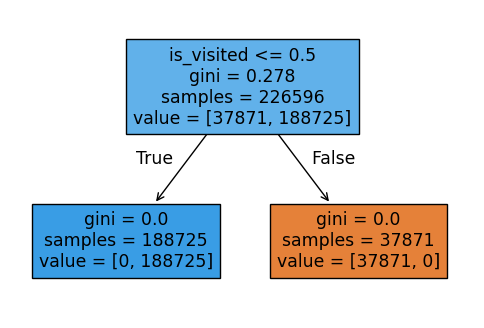

In [22]:
# nullの発生条件を決定木（Decision Tree）に予測させる
# あるカラムがnullになるのはどんな条件のときなのかを機械学習モデルに逆探知（逆エンジニアリング）させる

# 例えばstore_idが nullかどうか（0か1か）を正解ラベルにして、浅い決定木（max_depth=2くらい）を学習させることで、store_idがnullになる条件をあぶり出す
from sklearn.tree import DecisionTreeClassifier, plot_tree
y_null = df1['store_id'].isnull().astype(int)  # store_idがnullなら1、値があるなら0というダミーの目的変数を作る
X_null = df1[['is_visited', 'app_pv', 'current_temp']].fillna(-999)  # 特徴量として、それ以外のカラムを使う
tree = DecisionTreeClassifier(max_depth=2)
tree.fit(X_null, y_null)

# 木構造をプロットしてルールを目視
plt.figure(figsize=(6, 4))
plot_tree(tree, feature_names=X_null.columns, filled=True)
plt.show()

# 最初の分岐条件がis_visited<=0.5（is_visited==0なら100%nullになる）との結果
# どうやら来店してないときはstore_idがnullになるらしい。といったルールからデータセット構造を把握する手がかりになりそう

## null rate
- nullが全体に占める割合や、ユニークカウント値を集計
- その特徴量をどう扱うか、nullをどう扱うかの検討材料に（例えばnullはnullのままにしておく、レコード自体削除する、なんらか補完する、あまりにもnull率高い特徴量は使わないなど）
- データ構造の把握にも役立つ

In [23]:
def check_null_and_uniques(df, columns=None):
    """
    各カラムのnull率、ユニーク数などを集計するにゃん。
    df: 対象のデータフレーム
    columns: 集計したいカラムのリスト。省略（None）した場合は、すべてのカラムが対象    
    """
    if columns is None:
        target_df = df  # カラム未指定時は全カラムを対象にする
    else:
        if isinstance(columns, str):
            columns = [columns]  # 単一カラム指定時用
            
        # 指定されたカラムの中に、元のdfに存在しないものがないかチェック
        missing_cols = [c for c in columns if c not in df.columns]
        if missing_cols:
            raise ValueError(f"エラー：指定カラム {missing_cols} はそのデータフレームに存在しないにゃん!")
            
        # 指定されたカラムだけに絞り込む
        target_df = df[columns]

    total_rows = len(target_df)
    null_counts = target_df.isnull().sum()
    non_null_counts = total_rows - null_counts
    unique_counts = target_df.nunique()

    report_df = pd.DataFrame({
        'type': target_df.dtypes,                              # データ型
        'total_count': total_rows,                            # 全体の行数（null率の分母）
        'non_null': non_null_counts,                          # 非欠損値の行数
        'null': null_counts,                                  # 欠損値の数
        'null_rate(%)': (null_counts / total_rows * 100),     # 欠損率（%）全体の何％が欠損しているか
        'unique': unique_counts,                              # ユニーク数
        'non_null/unique': non_null_counts / unique_counts   # 頻度（1ユニークあたりの平均行数）
    })

    return report_df.sort_values(by='null', ascending=False).round(2)  # nullの数が多い順でソート

In [24]:
# 実行
check_null_and_uniques(df1)

# null相関が1だった4カラムは当然null率が同じ、null率自体高い
# null相関がほぼ0だった2カラムのnull率は微量
# 全体のレコード数とユニークカウント値との桁数の違いも、データ構造を推し量る材料になる
# 例えば22万行あるが、dateは91日分ということは、1つのdateが何度も登場するらしい。同様にcustomer_idも1万弱なので同じ顧客が何度も登場するらしい。そして22万行あるが、日付×顧客IDがこのデータセットの最小単位なのでdate91日×customer_id1万人=91万件　よりは少ないので、全員が毎日登場するわけではないらしいこともみえてくる

,type,total_count,non_null,null,null_rate(%),unique,non_null/unique
store_id,str,226596,37871,188725,83.29,20,1893.55
is_raining,float64,226596,37871,188725,83.29,2,18935.50
station_congestion_index,float64,226596,37871,188725,83.29,910,41.62
daily_staffing_cost,float64,226596,37871,188725,83.29,905,41.85
current_temp,float64,226596,219798,6798,3.00,91,2415.36
app_pv,float64,226596,224330,2266,1.00,29,7735.52
date,datetime64[us],226596,226596,0,0.00,91,2490.07
customer_id,str,226596,226596,0,0.00,9995,22.67
membership_days,object,226596,226596,0,0.00,1002,226.14
is_visited,int64,226596,226596,0,0.00,2,113298.00


## null or not
- nullのTrue/False別で、主要カラムを集計してみる
- 集計値に大きな違いがあるようなら、null自体が特徴量として意味がある、null発生に規則性があるなどと判断しやすい
- nullの扱いをどうするかの検討材料にもなる

In [25]:
def check_nan_impact(df, target_nan_col, metrics_cols):
    """
    nullを含むカラムをnull or not別に、数値型カラム（目的変数や主要カラム）の平均値を比較するにゃん。
    """
    res = df.groupby(df[target_nan_col].isna())[metrics_cols].mean().round(4)
    # 対象カラム自体の件数(行数)をsize()でcountしてデータフレームの先頭に差し込む
    res.insert(0, "count", df.groupby(df[target_nan_col].isna()).size())
    return res

In [26]:
# nullを含むカラム一覧
print(check_null_and_uniques(df1).query('null > 0').sort_values('null', ascending=False).index.tolist())

# これらのカラムを主に対象としてみていく

['store_id', 'is_raining', 'station_congestion_index', 'daily_staffing_cost', 'current_temp', 'app_pv']


In [27]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "store_id", ["is_purchased", "is_visited", "app_pv"])

,count,is_purchased,is_visited,app_pv
store_id,,,,
False,37871,0.2879,1.0,5.3380
True,188725,0.0000,0.0,1.1887


In [28]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "is_raining", ["is_purchased", "is_visited", "app_pv"])

,count,is_purchased,is_visited,app_pv
is_raining,,,,
False,37871,0.2879,1.0,5.3380
True,188725,0.0000,0.0,1.1887


In [29]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "station_congestion_index", ["is_purchased", "is_visited", "app_pv"])

,count,is_purchased,is_visited,app_pv
station_congestion_index,,,,
False,37871,0.2879,1.0,5.3380
True,188725,0.0000,0.0,1.1887


In [30]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "daily_staffing_cost", ["is_purchased", "is_visited", "app_pv"])

,count,is_purchased,is_visited,app_pv
daily_staffing_cost,,,,
False,37871,0.2879,1.0,5.3380
True,188725,0.0000,0.0,1.1887


- null相関が1だった4カラムは主要カラムの集計値が同じだった
- どうやら'store_id', 'is_raining', 'station_congestion_index', 'daily_staffing_cost'たちは、is_purchased, is_visitedが0だとnullらしい
- そしてnullかそうでないかで主要カラムの集計値に大きな違いがあった。すなわち、nullの発生には規則性がありそうなことがわかる（データセットの構造的要因に起因しそう）
- （is_purchased, is_visitedについても、その名称からすると来店してない時は購入してない扱いのデータ構造になってるかも、まで類推しちゃうかも）

In [31]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "current_temp", ["is_purchased", "is_visited", "app_pv"])

,count,is_purchased,is_visited,app_pv
current_temp,,,,
False,219798,0.0481,0.1672,1.8831
True,6798,0.0497,0.1634,1.8606


In [32]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_nan_impact(df1, "app_pv", ["is_purchased", "is_visited", "current_temp"])

,count,is_purchased,is_visited,current_temp
app_pv,,,,
False,224330,0.0482,0.1672,18.3150
True,2266,0.0415,0.1620,18.2309


- null相関がほぼ0だった2カラムは、nullかそうでないかで主要カラムの集計値に大きな違いはなかった
- どうやら'current_temp', 'app_pv'のnullは、MAR(Missing At Random) すなわちnull発生に規則性はなさそう

## where null
- nullの出現の仕方に規則性があるか（nullが特定のセグメントや条件で発生、集中していそうか）をみる
- nullの相関（共起性）をみた際に（null check工程）、相関係数がほどほどにあったカラムたちが主に対象（このデータセットでは存在しない）
- ここではstore_id, customer_idをみることで、データ構造の理解を深める

In [33]:
def check_nan_by_segment(df, group_col):
    """
    特定のセグメントにnullが集中していないかをチェックするにゃん。
    df: 対象のデータフレーム
    group_col: 集計の軸にするセグメントのカラム名（例: 'store_id'）
    """
    # 1. 軸になるカラム自体のnullを除外して考える（念のため）
    # 2. 各行がnull（True/False）のデータフレームを作り、group_col でグループ化して合計（件数）を出す
    null_counts_by_grp = df.isnull().groupby(df[group_col]).sum()

    # 3. nullが1件でも存在するカラムだけに絞り込む
    target_nan_cols = null_counts_by_grp.columns[null_counts_by_grp.sum() > 0]

    if len(target_nan_cols) == 0:
        print("🎉 nullを含むカラムは存在しなかったにゃん")
        return None

    res_df = null_counts_by_grp[target_nan_cols]  # 絞り込んだ結果のデータフレーム
    res_df["total_null_count"] = res_df.sum(axis=1)  # nullが登場するカラムたちの値を横方向に合計した列を追加
    group_sizes = df.groupby(group_col).size().to_frame(name="count")  # 各セグメントの件数count（分母）を集計
    final_res = group_sizes.join(res_df)  # 横に結合

    return final_res

In [34]:
# 特定のカラム（nullの出現の仕方に規則性ありそうと目されるもの）とdataframeを指定して実行
check_nan_by_segment(df1, group_col='store_id').head(15)  # 出力件数が多い場合を考慮してhead指定

# store_idのnull出現に規則性なさそうなことはわかっててそれを追認した形
# ただし、なんだか表記揺れが発生していそうな雰囲気が感じられる

,count,app_pv,current_temp,total_null_count
store_id,,,,
Store_A,3954,27,117,144
Store_B,3737,42,118,160
Store_C,3864,40,104,144
Store_D,3801,39,118,157
Store_E,3903,37,120,157
Store_F,3746,33,117,150
Store_G,3642,36,112,148
Store_H,3537,36,100,136
Store_I,3545,35,96,131


In [35]:
# 特定のカラム（nullの出現の仕方に規則性ありそうと目されるもの）とdataframeを指定して実行

# customer_idは出力件数が多すぎてheadでは状況不明なので、ソートして上位を表示
check_nan_by_segment(df1, group_col='customer_id').sort_values('total_null_count', ascending=False).head(15)

# customer_idにはもともとnullはないし、集計対象カラムたちのnull発生にも規則性はなさそう
# null出現に不審点ある場合は、さらに特定のカラムでソートしたり、比率など計算のうえdataframeに格納してチェックするとよい

,count,store_id,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,total_null_count
customer_id,,,,,,,,
byfytndh,74,68,0,2,68,68,68,274
5c3sjysu,70,63,0,2,63,63,63,254
rnjjfcvb,66,62,0,2,62,62,62,250
v05h7rda,71,61,1,3,61,61,61,248
q0cbdrtu,67,61,0,2,61,61,61,246
rz6uqbys,67,61,0,2,61,61,61,246
eqh7iw8g,71,60,1,4,60,60,60,245
b8xm3kw1,66,61,0,1,61,61,61,245
kuxocbge,69,60,1,2,60,60,60,243


- データ理解の構造についてのまとめ
  - null出現に規則性のあるカラムと、randomなカラム（null件数は少ない）があった
  - nullをどう扱うかはここではいったん保留
  - データ構造はなんとなくみえてきた
  - 副産物として変なデータが混入してそうなことがわかったので次の工程でクリーニングしていく

# data cleaning

## dtypes number
- 数値型扱いになっているが、例えばカテゴリ変数や文字列として扱いたいカラムが混ざっていないか？のチェック
  - 非数値型を思わせるid/code/typeのような文字を含むカラム名だったり、ユニーク数が極端に少ないカラムなど
  - yyyymmddが年/月/日に分かれて格納されてるなど、hh時間帯や曜日など
  - 顧客属性やなんらかの区分を表す名義尺度のような情報が数値で格納されているなど
- 自作関数で洗い出したり、ユニーク値を目視していく（要約統計量をみるのもいい）

In [36]:
# データ型の把握（数値型のみ）
df1.select_dtypes(include=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 226596 entries, 0 to 226595
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   is_visited                226596 non-null  int64  
 1   app_pv                    224330 non-null  float64
 2   current_temp              219798 non-null  float64
 3   is_raining                37871 non-null   float64
 4   station_congestion_index  37871 non-null   float64
 5   daily_staffing_cost       37871 non-null   float64
 6   is_purchased              226596 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 12.1 MB


In [37]:
def suggest_non_number_columns(df):
    """
    数値型だけど、実は非数値型（カテゴリ型やフラグ型）かもしれないカラムを提案するにゃん。
    """
    suspicious_cols = []
    
    for col in df.select_dtypes(include=['number']).columns:
        unique_count = df[col].nunique()
        
        # 条件A: カラム名に識別子を思わせるキーワードが含まれているか
        has_keyword = any(keyword in col.lower() for keyword in ["id", "code", "type", "day", "flag"])
        
        # 条件B: ユニークな値の数が極端に少ないか（例：0と1の2種類など5件以下）
        is_low_cardinality = unique_count <= 5
        
        # 条件A、または条件Bのどちらかを満たしたら怪しいと判定する
        if has_keyword or is_low_cardinality:
            suspicious_cols.append((col, unique_count))
            
    if suspicious_cols:
        print("💡 以下の数値型カラムは、非数値型（カテゴリやBool）に変えたほうがいいかもしれないにゃん：")
        for col, count in suspicious_cols:
            print(f"   ∟ {col} (ユニーク値: {count}件)")
    else:
        print("✅ 数値型カラムに非数値型っぽいものは見当たらないにゃん。")

# 実行
suggest_non_number_columns(df1)

# 出力結果は指定ルールにヒットしたものをあくまで提案してるだけなので、実際に変えるかは以降内容踏まえて都度判断する

💡 以下の数値型カラムは、非数値型（カテゴリやBool）に変えたほうがいいかもしれないにゃん：
   ∟ is_visited (ユニーク値: 2件)
   ∟ is_raining (ユニーク値: 2件)
   ∟ is_purchased (ユニーク値: 2件)


In [38]:
# 提案されたカラムはいずれもcategory型やboolにする必要性は薄いんだが、変更を検討する場合を想定して、

print(df1['is_raining'].unique())  # ユニーク値の種別を把握
df1.groupby('is_raining').size()  # ユニーク値別に頻度（行数）を見てみる

# このカラムは（2値なので）数値型扱いでも支障なさそうなのでこのままとする

[ 0. nan  1.]


is_raining
0.0    30550
1.0     7321
dtype: int64

In [39]:
# # 数値型カラムのうち、数値型の必要性がないカラムを文字列型に変換するなら、
# df1["value_id"] = df1["value_id"].astype('str') 
# df1["value_id"] = df1["value_id"].astype('string')   # pandasが古い例えばv1.5とかならstringを指定した方がいいかも

# # NaNはNaNのまま残して、数字だけを文字列（str）に変換する
# df1["value_id"] = df1["value_id"].map(lambda x: str(int(x)) if pd.notnull(x) else x)
# # ※小数点以下も含むような数値を想定して、int(x)を挟んでからstr()にしている

In [40]:
# 数値型カラムのうち、カテゴリ変数にしたいカラムを型変換するなら、

# 一度文字列にしてからcategory型にする
# df1["value_id"] = df1["value_id"].astype(str).astype("category")

# 順序に意味があるカテゴリ変数にしたい場合（満足度 high/mid/lowや曜日など）
# 並び順を指定してcategory型にする
# weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
# df1["weekday"] = pd.Categorical(df1["weekday"].astype(str), categories=weekday_order, ordered=True)
# 特徴量として使う際に、モデルがこの並び順でなんらか傾向があるかも？と並び順の情報を保持したまま学習してくれる

In [41]:
# 数値型カラムのうち、明らかにyyyymmddなのでdatetime型に変換するなら、
# df1["date"] = pd.to_datetime(df1["date"].astype(str))　　# 一度文字列にしてから変換

# 数値型カラムのうち、例えばyyyymmddが年/月/日に分かれて格納されてるのを、束ねてdatetimeに型変換するなら、
# カラム名が 'year', 'month', 'day' ならこれで
# df1['date'] = pd.to_datetime(df1[['year', 'month', 'day']])
# あるいは辞書形式で指定する
# df1['date'] = pd.to_datetime({'year': df1['yyyy'], 'month': df1['mm'], 'day': df1['dd']})

## dtypes exclude number
- 非数値型扱いになっているが、数値として扱いたいカラムが混ざっていないか？のチェック
  - 連続値データだけと思ってたら、?や空文字（スペースだけ）のような文字が混入しているなど
  - エクセルで数値の先頭に'をつけてたり、エクセル書式で文字列設定していた影響が残っているなど

In [42]:
# データ型の把握（非数値型のだけ）
df1.select_dtypes(exclude=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 226596 entries, 0 to 226595
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             226596 non-null  datetime64[us]
 1   customer_id      226596 non-null  str           
 2   store_id         37871 non-null   str           
 3   membership_days  226596 non-null  object        
dtypes: datetime64[us](1), object(1), str(2)
memory usage: 6.9+ MB


## why not numeric
- 文字列カラム（str, string, object）の中身を把握
- 数値型であって欲しいのに、文字列扱いになっているカラムへの混入物を目視したい意図（isnullではヒットしない）

In [43]:
# チェックしたいカラムをリストアップ（文字列扱いカラムのうち、そうであって欲しくないカラムのみ）
# ここでは文字列扱いじゃないカラムもうっかり含めちゃった想定にしている（自作関数のフィルタチェック目的でもある）
target_numeric_cols = ['membership_days', 'app_pv', 'current_temp']

In [44]:
def scan_numeric_columns(df, target_cols):
    """
    数値型であって欲しいカラムをスキャンし、数値以外のデータが混ざっていないかチェックするにゃん。
    """
    # 存在するカラム、かつまだ文字列扱いのカラムだけを抽出
    # 数値型に変換済みのカラムがtarget_colsに含まれていた場合に不要なチェックを回避するフィルタ
    check_cols = [c for c in target_cols if c in df.columns and df[c].dtype == 'object']

    if not check_cols:
        print("✅ 対象のカラムはすべて数値型になってるにゃん！")
        return

    print("--- 🔍 数値型であって欲しいカラムの混入・欠損チェック ---")
    total_count = len(df)
    
    for col in check_cols:
        # 1. もともとnullだった数をカウント
        original_nan_count = df[col].isna().sum()
        original_nan_rate = (original_nan_count / total_count) * 100
        
        # 2. 数値に変換を試みる（数値にできないエラーのぶんは強制的にNaNになる）
        converted = pd.to_numeric(df[col], errors='coerce')
        
        # 3. もともとnullではなく、数値変換によって新たにNaNになった値（＝混入物）を特定
        non_numeric_rows = df.loc[converted.isna() & df[col].notna(), col]
        
        # 画面に出力するフェーズ
        print(f"⚠️ {col}")
        print(f"   ∟ 総行数: {total_count:,} 件")
        print(f"   ∟ ① もともとの欠損値(Null)   : {original_nan_count:,} 件 ({original_nan_rate:.2f} %)")
        
        if not non_numeric_rows.empty:
            counts = non_numeric_rows.value_counts()
            total_non_numeric = counts.sum()
            trash_rate = (total_non_numeric / total_count) * 100
            
            print(f"   ∟ ② 数値以外のデータ : {total_non_numeric:,} 件 ({trash_rate:.2f} %)")
            print(f"      [詳細内訳]")
            for val, cnt in counts.items():
                # 空文字（長さ0）はわかりにくいので、明示的にテキスト表現する
                display_val = '"" (空文字)' if str(val).strip() == '' else f"'{val}'"
                print(f"         - {display_val}: {cnt:,} 件")
        else:            
            print(f"   ∟ ② 数値以外のデータ : 0 件 (0.00 %) -> 混入物なし！")
            
        print("-" * 45)

In [45]:
scan_numeric_columns(df1, target_numeric_cols)

# membership_daysはカラム名からすると数値型っぽいがそうなってなかったのは、'?'や''が混入してたからと判明
# 混入物が占める割合は多くはない
# だがnullの件と同様に、この混入物がどんな条件のときに発生しているのか（規則性あるか）を見ておく

--- 🔍 数値型であって欲しいカラムの混入・欠損チェック ---
⚠️ membership_days
   ∟ 総行数: 226,596 件
   ∟ ① もともとの欠損値(Null)   : 0 件 (0.00 %)
   ∟ ② 数値以外のデータ : 1,809 件 (0.80 %)
      [詳細内訳]
         - '?': 1,129 件
         - "" (空文字): 680 件
---------------------------------------------


In [46]:
def check_trash_impact(df, target_col, metrics_cols):
    """
    数値型であって欲しいカラムを状態別に、数値型カラム（目的変数や主要カラム）の平均値を比較するにゃん。
    """
    # 1. 状態を判定するためのベース（文字列化して前後の空白を削除）
    col_str = df[target_col].astype(str).str.strip()
    
    # 2. 条件分岐用のマスクを作成（ここの定義を増やせば拡張可能。check_nan_impact関数の上位互換）
    is_real_nan = df[target_col].isna()
    is_q_mark = (col_str == '?')
    is_empty = (col_str == '')
    
    # 3. 状態を定義するラベルのSeriesを生成
    # デフォルトを「正常（数値）」にしておき、各条件に合う場所を上書きする
    status_series = pd.Series("0_正常（数値）", index=df.index)
    status_series[is_real_nan] = "1_欠損（NaN）"
    status_series[is_q_mark] = "2_ゴミ（'?'）"
    status_series[is_empty] = "3_ゴミ（空文字）"
    
    # 4. 作成したラベルでgroupbyをかけ、主要指標の平均値を計算
    res = df.groupby(status_series)[metrics_cols].mean().round(4)
    
    # 5. 各状態の件数（行数）をsize()でcountしてデータフレームの先頭に差し込む
    res.insert(0, "count", df.groupby(status_series).size())
    
    print(f"📊 {target_col}")
    return res

In [47]:
# 対象カラムと、傾向を見たいカラムたちを指定して実行
check_trash_impact(df1, "membership_days", ["is_purchased", "is_visited", "app_pv", "current_temp"])

# どうやら混入物の発生に規則性はなさそう
# だがこの自作関数はmeanを計算しているため文字列型カラムなどについては判定不能なことから以下もおこなう（例えば特定のstore_idでのみ混入物が発生している可能性は残る）

📊 membership_days


,count,is_purchased,is_visited,app_pv,current_temp
0_正常（数値）,224787,0.0481,0.1671,1.8824,18.3150
2_ゴミ（'?'）,1129,0.0531,0.1754,1.8945,18.2752
3_ゴミ（空文字）,680,0.0544,0.1794,1.8769,18.1142


In [48]:
def check_category_trash_impact(df, target_col, cat_col):
    """
    数値型カラムの混入物が、特定のセグメント、カテゴリに集中（偏って）発生していそうかをみるにゃん。
    """
    # 1. 状態のラベルSeriesを作る（ここの定義を増やせば拡張可能）
    col_str = df[target_col].astype(str).str.strip()
    status_series = pd.Series("0_正常", index=df.index)
    status_series[df[target_col].isna()] = "1_欠損（NaN）"
    status_series[col_str == '?'] = "2_ゴミ（'?'）"
    status_series[col_str == ''] = "3_ゴミ（空文字）"
    
    # 2. クロス集計しつつ、行（状態）ごとの比率（normalize='index'）に変換する
    # それぞれの状態における指定セグメントのシェアを計算
    cross_pct = pd.crosstab(status_series, df[cat_col], normalize='index') * 100
    
    print(f'📊 "{target_col}" の混入物における、{cat_col}の構成比（%）')
    
    # 3. 各行（状態）ごとに、シェアが高い上位5つを抽出
    for status in cross_pct.index:
        print(f"\n▶️ 【{status}】での {cat_col}の上位シェア:")
        top5 = cross_pct.loc[status].sort_values(ascending=False).head(5)
        for cat, val in top5.items():
            print(f"   ∟ {cat}: {val:.2f} %")
            
    print("-" * 45)

In [49]:
check_category_trash_impact(df1, "membership_days", "store_id")

# 混入物状態におけるstore_idの出現率に極端な偏りはなさそう、正常データにおける出現率とも似た傾向を示している
# つまり特定のstore_idでのみ混入物が発生している可能性は低そう（規則性はなさそう）

📊 "membership_days" の混入物における、store_idの構成比（%）

▶️ 【0_正常】での store_idの上位シェア:
   ∟ Store_J: 10.44 %
   ∟ Store_A: 10.43 %
   ∟ Store_E: 10.32 %
   ∟ Store_C: 10.20 %
   ∟ Store_D: 10.06 %

▶️ 【2_ゴミ（'?'）】での store_idの上位シェア:
   ∟ Store_A: 11.62 %
   ∟ Store_F: 11.62 %
   ∟ Store_I: 11.11 %
   ∟ Store_C: 10.61 %
   ∟ Store_B: 10.10 %

▶️ 【3_ゴミ（空文字）】での store_idの上位シェア:
   ∟ Store_A: 13.11 %
   ∟ Store_J: 13.11 %
   ∟ Store_I: 12.30 %
   ∟ Store_B: 12.30 %
   ∟ Store_C: 9.02 %
---------------------------------------------


In [50]:
check_category_trash_impact(df1, "membership_days", "date")

# 特定の日付でのみ混入物が発生している可能性は低そう（規則性はなさそう）

📊 "membership_days" の混入物における、dateの構成比（%）

▶️ 【0_正常】での dateの上位シェア:
   ∟ 2025-11-30 00:00:00: 1.39 %
   ∟ 2025-11-22 00:00:00: 1.38 %
   ∟ 2025-11-29 00:00:00: 1.35 %
   ∟ 2025-11-15 00:00:00: 1.35 %
   ∟ 2025-11-24 00:00:00: 1.35 %

▶️ 【2_ゴミ（'?'）】での dateの上位シェア:
   ∟ 2025-11-22 00:00:00: 1.95 %
   ∟ 2025-11-24 00:00:00: 1.86 %
   ∟ 2025-11-15 00:00:00: 1.77 %
   ∟ 2025-10-19 00:00:00: 1.68 %
   ∟ 2025-11-03 00:00:00: 1.68 %

▶️ 【3_ゴミ（空文字）】での dateの上位シェア:
   ∟ 2025-11-23 00:00:00: 2.35 %
   ∟ 2025-11-16 00:00:00: 2.21 %
   ∟ 2025-11-08 00:00:00: 2.06 %
   ∟ 2025-09-15 00:00:00: 1.91 %
   ∟ 2025-10-25 00:00:00: 1.91 %
---------------------------------------------


In [51]:
check_category_trash_impact(df1, "membership_days", "customer_id")

# 特定のcustomer_idでのみ混入物が発生している可能性は低そう（規則性はなさそう）

📊 "membership_days" の混入物における、customer_idの構成比（%）

▶️ 【0_正常】での customer_idの上位シェア:
   ∟ byfytndh: 0.03 %
   ∟ eqh7iw8g: 0.03 %
   ∟ v05h7rda: 0.03 %
   ∟ 5c3sjysu: 0.03 %
   ∟ rslxex03: 0.03 %

▶️ 【2_ゴミ（'?'）】での customer_idの上位シェア:
   ∟ 9bhdmni1: 0.27 %
   ∟ 5oxtjxxx: 0.27 %
   ∟ ld1tj4sb: 0.27 %
   ∟ j0hduu3m: 0.27 %
   ∟ dretwkvd: 0.27 %

▶️ 【3_ゴミ（空文字）】での customer_idの上位シェア:
   ∟ ofpi70m9: 0.44 %
   ∟ dmkks6nm: 0.29 %
   ∟ mqeutgoo: 0.29 %
   ∟ u9a02sxa: 0.29 %
   ∟ icv9rq08: 0.29 %
---------------------------------------------


In [52]:
# membership_daysカラムの混入物の発生に規則性はなさそう
# このカラムは数値型であって欲しいので、混入物はなんらかの処理をしておきたい
# 数値以外のデータが少数なことと、素早い初動回答を優先して、NaN（欠損値）に置換する
# NaNにすることが最善手かは不明だが、先に進むためにはいったんキレイに数値型にしておくほうが好都合

# 数値に変換を試みることで、数値にできない混入物は強制的にNaNにできる
df1['membership_days'] = pd.to_numeric(df1['membership_days'], errors='coerce')

In [53]:
# # 混入物の処理方法案

# # 不要な文字列は混入しているが、少数で影響軽微と許容できる、あるいはスピード優先したい場合
# # 数値にできない文字列は強制的にNaN（欠損値）に置換する（NaNを含むので自動的にfloat64型になる）
# df1['value1'] = pd.to_numeric(df1['value1'], errors='coerce')

# # この文字は0にしたい、この文字は欠損値扱いにしたいなどの明確な根拠、意思がある場合
# # replaceで明示的に特定の文字を、それぞれ置換してからastype
# df1['value1'] = df1['value1'].replace({'?': 0, 'Unknown': np.nan}).astype(float)  # ?は0に、UnknownはNaNに置換
# df1["value1"] = df1["value1"].replace(["", "?"], np.nan)  # 空白と?はNaNに置換

# # "1,200円"のように数字に関連する余計な文字がくっついている場合
# # 正規表現で数字以外を削ぎ落とす（数字、小数点、マイナス記号以外を全部消す）
# df1['value1'] = df1['value1'].str.replace(r'[^0-9.-]', '', regex=True).astype(float)

# # （混入物はなく明らかに全て数値情報のみなんだが）文字列扱いになっているカラムを、数値型に変換する
# df1["value1"] = df1["value1"].astype(float)

## why not datetime
- 時点情報のカラムがdatetime型になっていない原因を把握する
- 時点情報がdatetime型でなくとも不都合感じない場合もあるが、期間の計算やダウンサンプリングで苦労する

In [54]:
# datetime型であって欲しいのに、文字列扱いになっているカラムをリストアップ

# dateカラムがdatetime型なのはわかってるが、そうではなかった場合を想定して実行
target_datetime_cols = ['date']

In [55]:
def scan_datetime_columns(df, target_cols):
    """
    datetime型にしたいカラムをスキャンし、日付として読み取れない文字を特定するにゃん。
    """
    # 存在するカラム、かつまだ文字列扱いのものだけを抽出
    # datetime型に変換済みのカラムがtarget_date_colsに含まれていた場合に不要なチェックを回避するフィルタ
    check_cols = [c for c in target_cols if c in df.columns and df[c].dtype == 'object']

    if not check_cols:
        print("✅ 対象のカラムはすべてdatetime型（または変換不要）だにゃん!")
        return

    print("--- 🔍 日付列のフォーマット不備チェック ---")
    for col in check_cols:
        # 日付型に変換を試みる（日付にできないエラーのぶんはNaNになる）
        converted = pd.to_datetime(df[col], errors='coerce')
        # もともとNaNではなく、日付変換によって新たにNaNになった値（＝混入物）を特定
        invalid_date_rows = df.loc[converted.isna() & df[col].notna(), col]
        
        if not invalid_date_rows.empty:
            total_count = len(df)
            counts = invalid_date_rows.value_counts()
            total_invalid = counts.sum()
            rate = (total_invalid / total_count) * 100
            
            print(f"⚠️ {col}")
            print(f"   ∟ 総数: {total_count:,} 件")
            print(f"   ∟ 日付にできないデータ: {total_invalid:,} 件 ({rate:.2f} %)")
            print(f"   ∟ 詳細: ")
            for val, cnt in counts.items():
                print(f"      - '{val}': {cnt:,} 件")
            print("-" * 35)
        else:            
            print(f"✅ {col} -> すべての日付が正しく変換可能だにゃん!")

In [56]:
scan_datetime_columns(df1, target_datetime_cols)

✅ 対象のカラムはすべてdatetime型（または変換不要）だにゃん!


In [57]:
# # 文字列扱いの日付データをdatetime型に変換する

# # 全カラムが明らかに日付情報のみであることが確実な場合に（文字列混入していると実行エラーになる）
# df1["date"] = pd.to_datetime(df1["date"])

# # 不要な文字列が混入してるとわかってるが、少数で影響軽微と許容できる、あるいはスピード優先したい場合
# # 日付にできない文字列は強制的にNaN（欠損値）に置換したうえで、削除する
# df1['date'] = pd.to_datetime(df1['date'], errors='coerce')
# before_count = len(df1)  # 日付がNaNの行を削除する前の行数
# df1 = df1.dropna(subset=['date']).reset_index(drop=True)  # 日付がNaNの行を削除してインデックスを振り直す
# after_count = len(df1)  # 日付がNaNの行を削除した後の行数
# print(f"日付不備で {before_count - after_count:,} 件のデータをドロップしたにゃん")

# 日付データのカラムの中身がもっと変で複雑な場合は、適宜加工してキレイに変換する（ここでは省略）

## desc & histogram
クリーニング工程を（完全にではないがひとまず）終えて改めてみておく

- 数値型カラムの平均、標準偏差、最小値、最大値などを把握
  - 事前情報やドメイン知識からして極端な外れ値が混入していないかもチェックできるとなおよい
- 非数値型カラムのユニークカウント、最頻値、範囲などを把握

In [58]:
# データ型の把握（数値型のだけ）
df1.select_dtypes(include=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 226596 entries, 0 to 226595
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   membership_days           224787 non-null  float64
 1   is_visited                226596 non-null  int64  
 2   app_pv                    224330 non-null  float64
 3   current_temp              219798 non-null  float64
 4   is_raining                37871 non-null   float64
 5   station_congestion_index  37871 non-null   float64
 6   daily_staffing_cost       37871 non-null   float64
 7   is_purchased              226596 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 13.8 MB


In [59]:
# 数値型カラムの要約統計量
df1.describe(include='number')

,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,is_purchased
count,224787.000000,226596.000000,224330.000000,219798.000000,37871.000000,37871.000000,37871.000000,226596.000000
mean,352.542522,0.167130,1.882432,18.314161,0.193314,99.811603,101465.763117,0.048112
std,274.767847,0.373093,2.143505,4.559635,0.394902,14.602362,29440.151583,0.214003
min,0.000000,0.000000,1.000000,9.730466,0.000000,48.444697,50162.000000,0.000000
25%,116.000000,0.000000,1.000000,14.947722,0.000000,90.376134,74905.000000,0.000000
50%,281.000000,0.000000,1.000000,17.640706,0.000000,99.742609,102260.000000,0.000000
75%,562.000000,0.000000,2.000000,21.570538,0.000000,109.340613,126524.000000,0.000000
max,999.000000,1.000000,29.000000,27.346096,1.000000,152.667334,149982.000000,1.000000


In [60]:
# データ型の把握（非数値型のだけ）
df1.select_dtypes(exclude=["number"]).info()

<class 'pandas.DataFrame'>
RangeIndex: 226596 entries, 0 to 226595
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   date         226596 non-null  datetime64[us]
 1   customer_id  226596 non-null  str           
 2   store_id     37871 non-null   str           
dtypes: datetime64[us](1), str(2)
memory usage: 5.2 MB


In [61]:
# 非数値型カラムの要約統計量
df1.describe(exclude='number')

,date,customer_id,store_id
count,226596,226596,37871
unique,NaN,9995,20
top,NaN,byfytndh,Store_A
freq,NaN,74,3954
mean,2025-10-17 18:50:03.844728,NaN,NaN
min,2025-09-01 00:00:00,NaN,NaN
25%,2025-09-25 00:00:00,NaN,NaN
50%,2025-10-19 00:00:00,NaN,NaN
75%,2025-11-10 00:00:00,NaN,NaN
max,2025-11-30 00:00:00,NaN,NaN


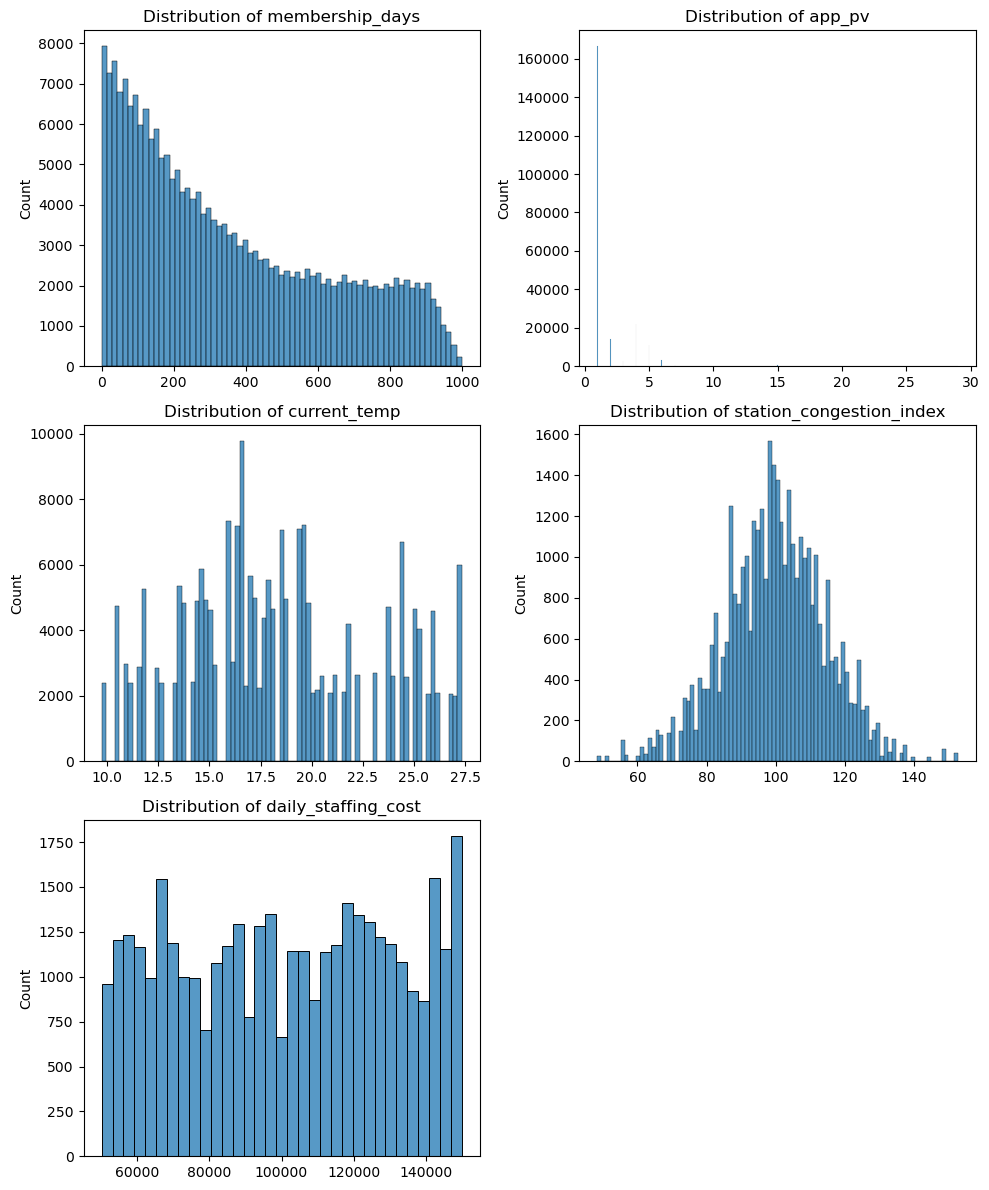

In [62]:
# 数値型カラムの分布をざっと見る

import math

# 分布を見たい数値型カラムをリスト指定
# num_features = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()  # 楽だが2値のも含まれちゃう
num_features = ['membership_days', 'app_pv', 'current_temp', 'station_congestion_index', 'daily_staffing_cost']

# レイアウトの計算（列数固定で、カラム数に応じて必要な行数を自動計算）
n_cols = 2
n_rows = math.ceil(len(num_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
# axesが1行（1次元）や1個（スカラー）のときでも、同じループで扱えるように1次元配列にフラット化
axes = axes.flatten()

# plot
for i, col in enumerate(num_features):
    sns.histplot(data=df1, x=col, kde=False, ax=axes[i])
    # sns.histplot(data=df1, x=col, kde=True, stat="density", ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')  # タイトルに任せて消す

# 余った空っぽのマス（グラフ）を非表示にする
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## len datetime
- 時点データの範囲内において、途中の日付が抜けてる可能性あるかをチェック
- describeでわかる期間とユニーク値との照合でもいいが長期間だと瞬発的には判断しにくい

In [63]:
def check_date_continuity(df, date_col):
    """
    日付の連続性をチェックし、期間内で途中の日付が抜けたりしてないかをチェックするにゃん。
    """
    # 念のため、時間を切り捨てて「純粋な日付のみ」にしたSeriesを内部で作る
    pure_date = pd.to_datetime(df[date_col]).dt.date
    
    # 期間日数とユニーク数の計算
    date_span_days = (pure_date.max() - pure_date.min()).days + 1
    unique_date_count = pure_date.nunique()
    
    print(f"--- 📅 日付連続性スキャン: 【{date_col}】 ---")
    print(f"   ∟ 開始日: {pure_date.min()} 〜 終了日: {pure_date.max()}")
    print(f"   ∟ 理論上の期間日数: {date_span_days} 日")
    print(f"   ∟ 実際のユニーク日数: {unique_date_count} 日")
    
    if date_span_days == unique_date_count:
        print("✅ 欠損日なし: 途中日付が抜けることなく連続してるにゃん！")
        
    elif date_span_days > unique_date_count:
        missing_days = date_span_days - unique_date_count
        print(f"⚠️ 欠損日の可能性あり: 途中で抜けてる日付が【{missing_days}日分】あるにゃん。")
        
    else:
        print("🚨 警告: 期間日数よりもユニーク日付数の方が多いにゃん！")
        print("   ∟ 原因の可能性: 元のカラムに時分秒データが残ったままnunique()を計算しているか、異常な日付が混入してるかもにゃん。")

# 実行
check_date_continuity(df1, 'date')

--- 📅 日付連続性スキャン: 【date】 ---
   ∟ 開始日: 2025-09-01 〜 終了日: 2025-11-30
   ∟ 理論上の期間日数: 91 日
   ∟ 実際のユニーク日数: 91 日
✅ 欠損日なし: 途中日付が抜けることなく連続してるにゃん！


## categorical variable
- カテゴリ変数っぽいカラムの中身を確認してカテゴリ変数にする

In [64]:
# 特徴量の候補なのにcategory型ではないカラム、あるいはユニーク値が少ないカラムなどを目視チェック
df1['store_id'].unique()

# 前の工程ですでに判明してた通り、Store_A〜Store_Jのはずが、store_a〜store_jも混じっている
# さすがにこれは表記揺れだろうとみなして、深く追求はせずに名寄せをおこなう

<StringArray>
['Store_I',       nan, 'Store_J', 'Store_D', 'Store_B', 'Store_A', 'Store_F',
 'Store_E', 'Store_H', 'Store_C', 'Store_G', 'store_b', 'store_h', 'store_f',
 'store_i', 'store_a', 'store_c', 'store_j', 'store_d', 'store_e', 'store_g']
Length: 21, dtype: str

## 表記揺れの名寄せ

In [65]:
# パターン1: マスタ情報（正規のリスト）を基準に名寄せする
# 正しいリストを基準にしてそこから外れている怪しい文字列を丸め込む、あるいは例外として検知する方法

# 1. 正規の店舗マスタ情報
valid_stores = ['Store_A', 'Store_B', 'Store_C', 'Store_D', 'Store_E', 
                'Store_F', 'Store_G', 'Store_H', 'Store_I', 'Store_J']

store_mapping = {}
for raw_id in df1['store_id'].unique():
    
    # もしraw_idがnan(欠損値) だった場合は、辞書に登録せずスルーする
    if pd.isna(raw_id):
        continue
        
    # 完全に同じ、または大文字小文字を無視して一致するものをマスタから探す
    matched = [v for v in valid_stores if str(raw_id).strip().lower() == v.lower()]
    if matched:
        store_mapping[raw_id] = matched[0]  # 正しい表記（Store_Aなど）を割り当て
    else:
        store_mapping[raw_id] = 'Unknown_Store' # マスタにないものが含まれていた場合は識別できるようにしておく

# 3. 辞書形式で置換
df1['store_id'] = df1['store_id'].replace(store_mapping)

In [66]:
# # パターン2: 辞書形式で直に置換する
# # 変換用の辞書定義
# dirty_to_clean_store = {
#     'store_a': 'Store_A', 'store_b': 'Store_B', 'store_c': 'Store_C', 
#     'store_d': 'Store_D', 'store_e': 'Store_E', 'store_f': 'Store_F', 
#     'store_g': 'Store_G', 'store_h': 'Store_H', 'store_i': 'Store_I', 'store_j': 'Store_J'
# }
# # 辞書に存在するものだけを置換し、それ以外（もともとちゃんとしていたStore_Aなど）はそのままキープする
# df1['store_id'] = df1['store_id'].replace(dirty_to_clean_store)

In [67]:
df1['store_id'].unique()

# 表記揺れはなくなったが、並び順を整えつつcategory型にしたい

<StringArray>
['Store_I',       nan, 'Store_J', 'Store_D', 'Store_B', 'Store_A', 'Store_F',
 'Store_E', 'Store_H', 'Store_C', 'Store_G']
Length: 11, dtype: str

In [68]:
# 特徴量に使う予定のカラム、あるいは文字列では不都合のあるカラムを、category型に変換するなら、

# 特徴量に使うので、store_idをソートしてcategory型にする
# 今ある値を重複なく取ってきて、アルファベット順にソートする
# store_order = sorted(df1['store_id'].unique())  # ただしnullがあるとこれはエラーになる
# store_order = [f'Store {c}' for c in 'ABCDEFGHIJ']  # 規則性あるならこうでもいい

# nanをなくしてから unique() を取る
store_order = sorted(df1['store_id'].dropna().unique())

# 順番（ordered=True）を指定してカテゴリ型に変換
from pandas.api.types import CategoricalDtype
store_type = CategoricalDtype(categories=store_order, ordered=True)
df1['store_id'] = df1['store_id'].astype(store_type)

In [69]:
df1['store_id'].unique()

['Store_I', NaN, 'Store_J', 'Store_D', 'Store_B', ..., 'Store_F', 'Store_E', 'Store_H', 'Store_C', 'Store_G']
Length: 11
Categories (10, str): ['Store_A' < 'Store_B' < 'Store_C' < 'Store_D' ... 'Store_G' < 'Store_H' < 'Store_I' < 'Store_J']

## nullどうするか
- nullのままでもいいし、後述の前処理をおこなうのもよい。
- ただしnullをなくせばいいわけではない。むしろnullはnullのままの方がいいかも。
  - 例えばnullを0とみなして差し支えない場合はいいが、気温カラムのnullを0埋めするとおかしなことになる
  - また、LGBMはnullを欠損扱いで学習できるから、確からしい理由がない限りは無理に0で埋めずそのままの方が精度出やすい可能性ある

- 仮に過去購入率というカラムのnullを0に置換した場合
  - LGBMは0という具体的な数値として扱う。例えば購入率が0.05以下か？という境界線を作ったとき、0に置換されたデータ（みなし新規顧客）と、購入率がすごく低い既存客が同じグループにまとめられる。みなし新規顧客と既存顧客の購入率0を区別しなくていいならこれでもOK。

- 仮に過去購入率のnullをnullのままの場合
  - LGBMは数値がある人と、ない人（null）を、まず最初に分けることができる。データがあるかないかで枝分かれさせてから、データがある人の中で購入率が0.05以下か？とさらに細かく分けるという動きができる。つまり、新規客（未知）と、既存客の購入率0（既知のゼロ）を明確に使い分けられる可能性がある。

In [70]:
# # nullがあるとわかってるが、少数であったり規則性もなさそうなので影響軽微と許容できる場合

# before_count = len(df1)  # current_tempカラムがnullの行を削除する前の行数
# df1 = df1.dropna(subset=['current_temp']).reset_index(drop=True)  # 当該カラムがnullの行を削除してインデックスを振り直す
# after_count = len(df1)  # current_tempカラムがnullの行を削除した後の行数
# print(f"current_temp不備で {before_count - after_count:,} 件のデータをドロップしたにゃん")

In [71]:
# # nullの処理方法に、明確な根拠、意思がある場合

# # 0除算でinfやNaNになってる箇所を置換する
# df1["value2"] = df1["value2"].replace(np.inf, 0).fillna(0)

# # nullは0に置換するカラムを直接書き換える（例えば新規顧客とみなして0に置換する例）
# df1['past_latte_ratio'] = df1['past_latte_ratio'].fillna(0)

# # 辞書で渡す（例えば数値は0にして、カテゴリは'unknown'にする）
# df1 = df1.fillna({'past_latte_ratio': 0, 'value1': 'unknown'})

# # その他一般的なnullの処理方法については、例えば以下
# # # 数値データのnullを、平均値や中央値などの代表値で埋める
# # from sklearn.impute import SimpleImputer
# # imputer = SimpleImputer(strategy='mean')  # 平均値で埋める場合
# # df1['current_temp'] = imputer.fit_transform(df1[['current_temp']])

- ここまでみてきた限り、null出現に規則性のあるカラムはデータ構造に理由がありそう。
- そしてnull出現に規則性がなさそうなカラムにおいては、nullの占める割合は少なく影響軽微と許容できる
- というかnullを削除や置換する積極的理由は乏しいことと、lightgbmの場合はnullをそのまま扱えること、そして素早い初動回答を優先して、いずれの対象カラムもnullはそのままとする

## sort values
- 日付列がdatetime型になっても、データセットが日付順にソートされてないとモデル作成時に困る
- category型も、場合によってはソートされてないと不都合
- ただしソート対象のカラムにnullがあると、ソートしてもnullは先頭や末尾に固まって困るため、ソートする前にnullは適切処理しておく

In [72]:
# チェックしたいカラムをリストアップ

# datetime型や文字列扱いのカラムを投入する
# 顧客idのように並び順に意味がないものや、sort不要なものは含めない
target_cols = ['store_id', 'date']

In [73]:
from pandas.api import types

def check_sort(df, target_cols):
    """
    指定カラムがソートされた状態かチェックするにゃん。
    数値型の場合はスキップし、それ以外は型に合わせて賢くチェックするにゃん。
    """
    for col in target_cols:
        # 1. カラムが存在するかチェック
        if col not in df.columns:
            print(f"❓ {col} はデータフレームに存在しないみたいにゃん。")
            continue

        # 2. 型の判定（Pandas標準の判定メソッドを使う）
        if types.is_numeric_dtype(df[col]):
            print(f"🔢 {col}: これは数値型だにゃん。ソートチェックはスキップするにゃん。")
            continue
        
        # 3. 出現順のチェック
        # unique() は datetime や category でもそのまま使える
        # ただし、NaNが含まれるとsorted()でコケることがあるのでdropna()しておく
        actual = df[col].dropna().unique().tolist()
        expected = sorted(actual)
        
        # 4. 判定と表示
        if actual == expected:
            print(f"✅ {col}: このカラムの並び順はソートされてそうだにゃん！")
        else:
            print(f"❌ {col}: あれ、並び順が理想と違うにゃん")

# 実行
check_sort(df1, target_cols)

# ただしここではdropnaして実行している。よってnullがある場合のnull扱いは別途検討する必要あり

❌ store_id: あれ、並び順が理想と違うにゃん
❌ date: あれ、並び順が理想と違うにゃん


In [74]:
# 時点順にソートする（時点カラムがdatetime型になってる前提）

# df1 = df1.sort_values(by=['date']).reset_index(drop=True)

# 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる（時点カラムがdatetime型になってる前提）
df1 = df1.sort_values(by=['date', 'store_id']).reset_index(drop=True)

# 実行
check_sort(df1, target_cols)

✅ store_id: このカラムの並び順はソートされてそうだにゃん！
✅ date: このカラムの並び順はソートされてそうだにゃん！


## time series
- 時点推移の確認
- 日が経つにつれて傾向が変化しているか。周期性がありそうか

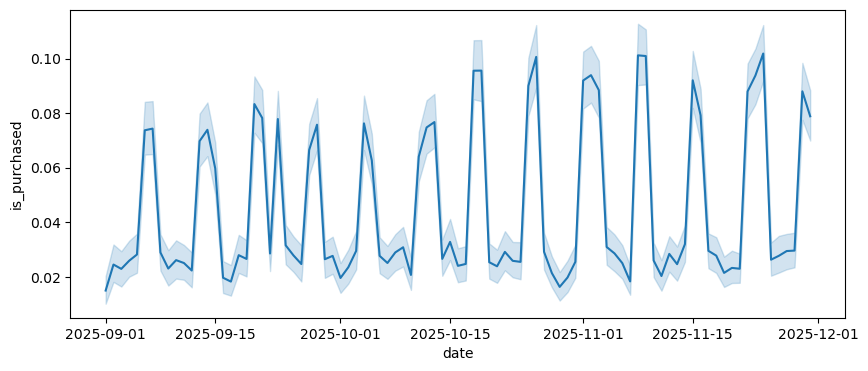

In [75]:
# 目的変数(is_purchased)の日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['is_purchased'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="is_purchased", errorbar="ci")
plt.show()

# トレンドは右肩上がりになってるかもだし、大差ないかも
# 曜日の周期性のようなものがあるかもしれない

In [76]:
# 曜日フラグを作成して周期性をみてみる

# 月曜=0, 火曜=1, ..., 日曜=6 の数値カラムを作成
df1['day_of_week_num'] = df1['date'].dt.dayofweek

# 曜日別の購入率を計算
df1.groupby('day_of_week_num')['is_purchased'].mean().round(4)

day_of_week_num
0    0.0467
1    0.0298
2    0.0256
3    0.0256
4    0.0254
5    0.0836
6    0.0836
Name: is_purchased, dtype: float64

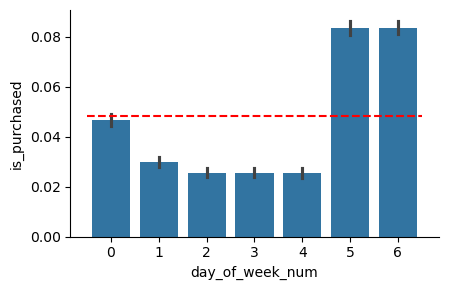

In [77]:
# グラフで確認してみる
sns.catplot(data=df1, x="day_of_week_num", y="is_purchased", kind="bar", aspect=1.5, height=3, order=sorted(df1['day_of_week_num'].unique()))
plt.hlines(df1['is_purchased'].mean(), xmin=-0.5, xmax=len(df1['day_of_week_num'].unique())-0.5, colors='red', linestyles='dashed', label='Overall Avg')
# plt.xticks(rotation=90)
plt.show()

# 土日は購入率高い（なので土日フラグという特徴量を作るのがよさそう）
# 平日のうち月曜だけなんか高い。他の曜日はほぼ同じ。月曜はひょっとしたら祝日発生しやすいぶんで高くなってる可能性あるかも

In [78]:
# データセットの期間内の祝日をみてみる

import jpholiday
start, end = df1['date'].min(), df1['date'].max()  # df['ds'] から期間の開始日と終了日を取得
years = df1['date'].dt.year.unique()  # 年をまたぐ可能性考えて、ユニークな年を取得

holidays_list = []
for y in years:
    for date, name in jpholiday.year_holidays(int(y)):
        # データの期間内に入っている祝日だけ追加
        if start.date() <= date <= end.date():
            holidays_list.append({'ds': pd.to_datetime(date), 'holiday': name, 'day_of_week': pd.to_datetime(date).dayofweek, 'day_of_week_en': pd.to_datetime(date).strftime('%a')})
holidays_df = pd.DataFrame(holidays_list)
holidays_df

# 期間内の祝日6日間のうち月曜は4日だった

,ds,holiday,day_of_week,day_of_week_en
0,2025-09-15,敬老の日,0,Mon
1,2025-09-23,秋分の日,1,Tue
2,2025-10-13,スポーツの日,0,Mon
3,2025-11-03,文化の日,0,Mon
4,2025-11-23,勤労感謝の日,6,Sun
5,2025-11-24,勤労感謝の日 振替休日,0,Mon


In [79]:
# 土日フラグ、祝日フラグの特徴量を作成する

# 土日フラグ（5:土曜日, 6:日曜日）
df1['is_weekend'] = df1['date'].dt.dayofweek.isin([5, 6]).astype(int)

# 祝日フラグ
df1['is_holiday'] = df1['date'].isin(holidays_df['ds']).astype(int)

In [80]:
# 曜日x祝日x週末別の購入率を計算
df1.groupby(['day_of_week_num', 'is_holiday', 'is_weekend'])['is_purchased'].mean().round(4)

day_of_week_num  is_holiday  is_weekend
0                0           0             0.0264
                 1           0             0.0824
1                0           0             0.0248
                 1           0             0.0779
2                0           0             0.0256
3                0           0             0.0256
4                0           0             0.0254
5                0           1             0.0836
6                0           1             0.0827
                 1           1             0.0938
Name: is_purchased, dtype: float64

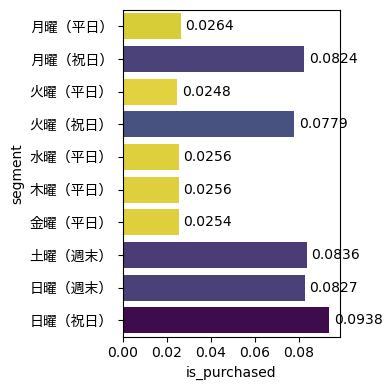

In [81]:
# グラフで確認してみる

#　上記集計値をdataframeにして
df_agg = (df1.groupby(['day_of_week_num', 'is_holiday', 'is_weekend'])['is_purchased'].mean().reset_index())

# 曜日数値を日本語に
weekday_map = {0: '月', 1: '火', 2: '水', 3: '木', 4: '金', 5: '土', 6: '日'}
df_agg['day_name'] = df_agg['day_of_week_num'].map(weekday_map)

# 3つのフラグを組み合わせて人間が読めるセグメント名にする
def make_segment_name(row):
    if row['is_holiday'] == 1:
        return f"{row['day_name']}曜（祝日）"
    elif row['is_weekend'] == 1:
        return f"{row['day_name']}曜（週末）"
    else:
        return f"{row['day_name']}曜（平日）"

df_agg['segment'] = df_agg.apply(make_segment_name, axis=1)
# df_agg = df_agg.sort_values('is_purchased', ascending=False)  # 購入率の高い順でソート

# plot
plt.rcParams["font.family"] = ["sans-serif", "Hiragino Sans"]  # mac用
plt.figure(figsize=(4, 4))
sns.barplot(data=df_agg, x='is_purchased', y='segment', hue='is_purchased', palette='viridis_r')
# 数値を棒の横にテキスト表示
for index, row in enumerate(df_agg.itertuples()):
    plt.text(row.is_purchased + 0.002, index, f"{row.is_purchased:.4f}", va='center', fontsize=10)
plt.legend().remove()  # 凡例消す
plt.tight_layout()
plt.show()

# 平日のうち月曜だけ高かったのと、火曜がちょい高かったのは祝日の影響だったらしいことが判明
# なので土日フラグだけでなく、祝日フラグも特徴量として有効と思われる

- 目的変数以外の数値型カラムについても、時点推移をみてみる

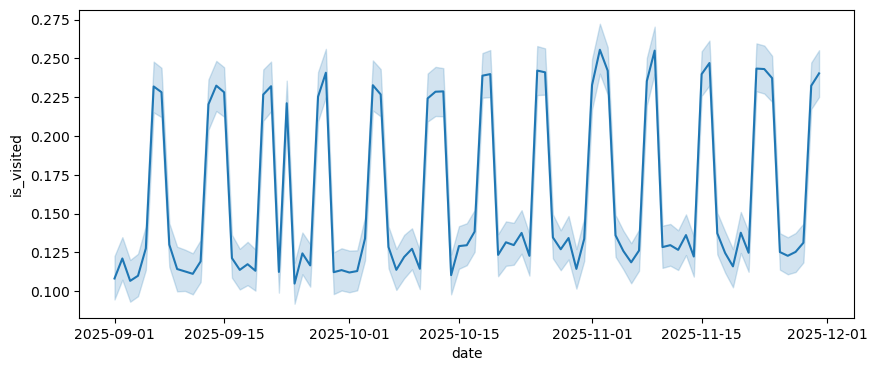

In [82]:
# 来店有無の日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['is_visited'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="is_visited", errorbar="ci")
plt.show()

# トレンドは右肩上がりになってるかもだし、大差ないかも
# 曜日の周期性のようなものがあるかもしれない

In [83]:
# 曜日x祝日x週末別の来店率を計算
df1.groupby(['day_of_week_num', 'is_holiday', 'is_weekend'])['is_visited'].mean().round(4)

# 購入率同様に、土日や祝日は来店率高そう

day_of_week_num  is_holiday  is_weekend
0                0           0             0.1242
                 1           0             0.2343
1                0           0             0.1226
                 1           0             0.2211
2                0           0             0.1201
3                0           0             0.1236
4                0           0             0.1250
5                0           1             0.2331
6                0           1             0.2393
                 1           1             0.2432
Name: is_visited, dtype: float64

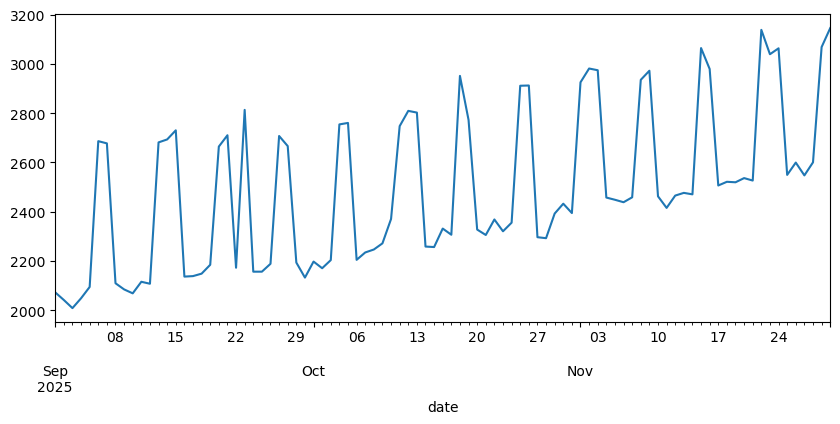

In [84]:
# 顧客数の日別推移
plt.figure(figsize=(10, 4))
df1.groupby('date')['customer_id'].count().plot(kind='line')  # countならこの方が楽
# df_count = df1.groupby("date")["customer_id"].count().reset_index(name="customer_count")
# sns.lineplot(data=df_count, x="date", y="customer_count")
plt.show()

# トレンドか周期性かはわからないがだんだんと増えている感じ

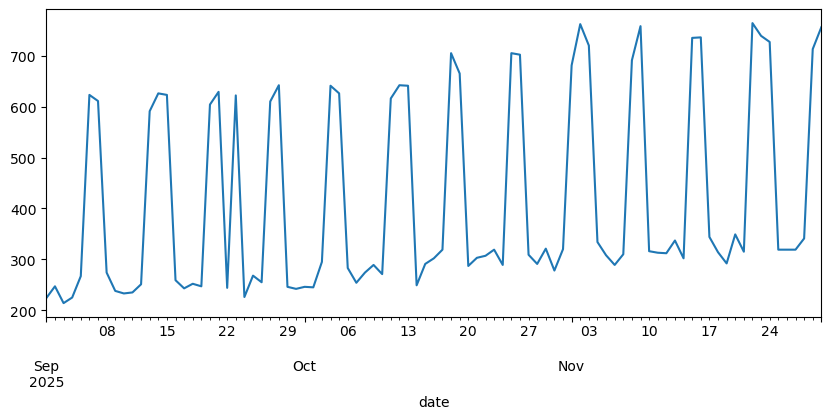

In [85]:
# 店舗数の日別推移
plt.figure(figsize=(10, 4))
df1.groupby('date')['store_id'].count().plot(kind='line')  # countならこの方が楽
# df_count = df1.groupby("date")["store_id"].count().reset_index(name="store_count")
# sns.lineplot(data=df_count, x="date", y="store_count")
plt.show()

# トレンドか周期性かはわからないがだんだんと増えている感じ
# 顧客数の推移の流れでやっているが、店舗数の推移に意味はあるかもだしないかも

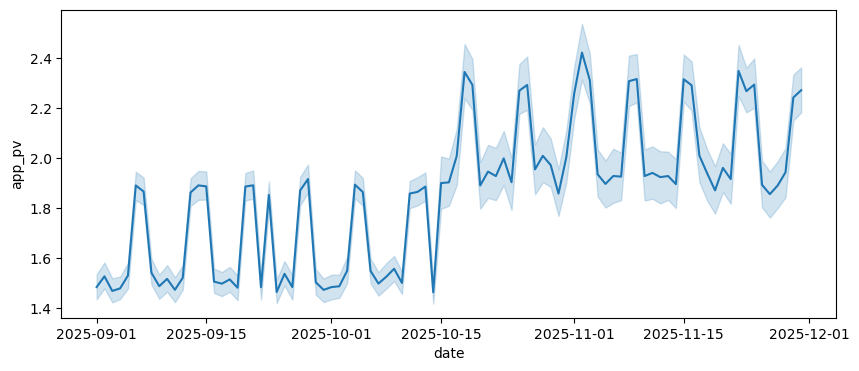

In [86]:
# app_pvの日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['app_pv'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="app_pv", errorbar="ci")
plt.show()

# 周期性のようなものがありつつ、途中でガラッと傾向が変わっている（これはデータ生成ロジックに起因している）

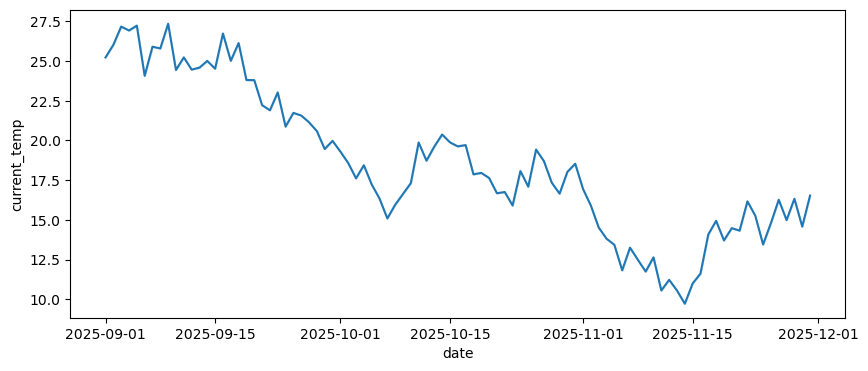

In [87]:
# 気温の日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['current_temp'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="current_temp", errorbar="ci")
plt.show()

# だんだんと低下している（寒くなっている）
# errorbar="ci"指定しててもプロットされていない。このデータセットには同じdateが複数行あることはわかっていることから、同じdateであれば同じcurrent_tempらしい

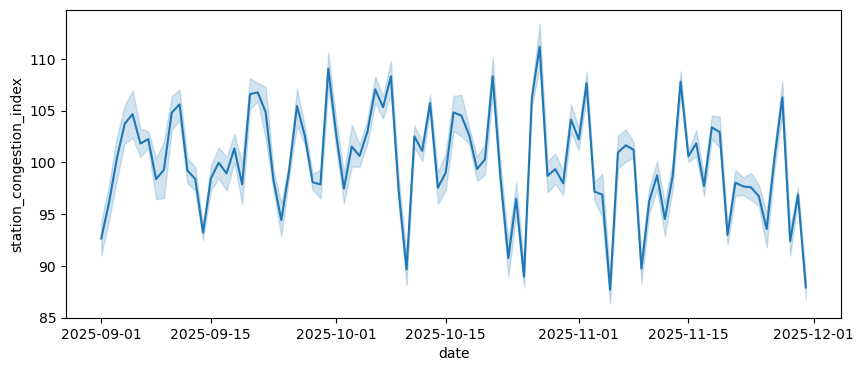

In [88]:
# station_congestion_indexの日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['station_congestion_index'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="station_congestion_index", errorbar="ci")
plt.show()

# トレンドや周期性がありそうかはこれだけではわかりにくい
# ciがプロットされているので、同じdateであってもstation_congestion_indexは異なるらしい（store_idと連動してるため）

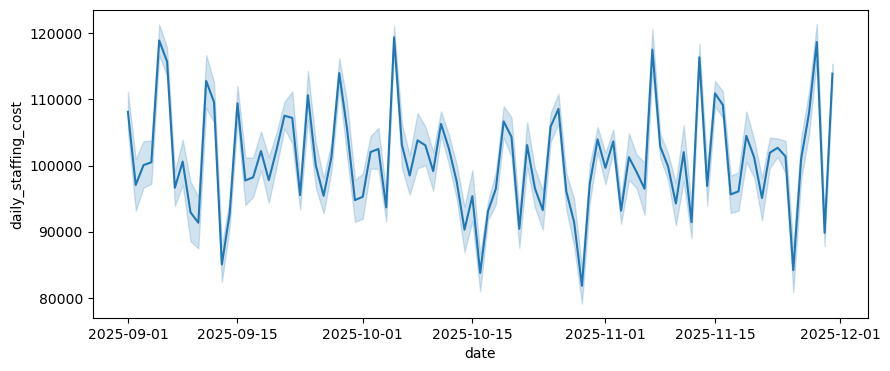

In [89]:
# daily_staffing_costの日別推移
plt.figure(figsize=(10, 4))
# df1.groupby('date')['daily_staffing_cost'].mean().plot(kind='line')  # meanを見るだけならこの方が速い
sns.lineplot(data=df1, x="date", y="daily_staffing_cost", errorbar="ci")
plt.show()

# トレンドや周期性がありそうかはこれだけではわかりにくい
# ciがプロットされているので、同じdateであってもdaily_staffing_costは異なるらしい（store_idと連動してるため）

# Deep EDA
目的変数を理解し、特徴量との関係性や、特徴量エンジニアリング目的で探索していく

- 目的変数の特徴: モデル良否の判断材料、予測の理由や根拠の理解、前処理の検討に活かす
  - 不均衡性: 大量データでもis_purchased=1（購入者）が少数になっていないか
  - 特徴量との相関: 特徴量の選択やモデル解釈に

- セグメントの違い: 数値型じゃない特徴量を基点に傾向把握、モデル解釈や仮説検証に活かす
  - 時点の推移: date別の推移（初日と最終日ではトレンド異なるのか）time series工程にて済み
  - 店舗の特性: store_id単位で比較（集団や層による影響ありそうか）
  - 顧客の定着: customer_id単位で出現回数の分布（常連さんと一見さんがいるのか）

- 初手への対処策: 素早い初動回答を最優先するために、精度担保しつつデータ削減検討もしたい
  - 例えば10万件を（層別）ランダムサンプリングして、データセット全体の縮図として進める
  - 例えば直近3日間データだけ、例えば店舗Aだけにするなど、均一条件に統制して進める
  - これらをおこなうにはセグメント傾向を把握しておく必要ある

## check y
目的変数の特徴をつかむ

- 不均衡チェック: 大量データでもis_purchased=1（購入者）が少数になっていないか
  1. ベースラインの把握: ラテ購入率（陽性率）の規模感次第でモデルでの改善目標も違ってくる
  1. 評価指標の判断: 購入率が極端に不均衡の場合はROC-AUCよりもPR-AUC
  1. 不均衡だった場合の対策検討: 前処理やモデルの学習方法
  1. 特徴量エンジニアリングの方向性把握: 購入率が極端に低い場合、平穏な特徴量だけではモデルが学習しきれないかも

- 特徴量との相関: 特徴量の選択やモデル解釈に
  - 目的変数と特徴量との相関をざっとみておく
  - 特徴量同士の相関もざっとみておく

In [90]:
# 目的変数（is_purchased）の内訳をみる

print("--- 件数の内訳 ---")
print(df1['is_purchased'].value_counts(dropna=False))
print("\n--- 比率の内訳(%) ---")
print(df1['is_purchased'].value_counts(normalize=True) * 100)

# 目的変数（ラテ購入率）は観測データ全体のうち4%
# なのでこのデータセットにおける目的変数は、極端な不均衡データといえそう
# つまりROC-AUCよりもPR-AUCでモデル評価するのがよさそうだし、予測精度向上には強力な特徴量が欲しくなる

--- 件数の内訳 ---
is_purchased
0    215694
1     10902
Name: count, dtype: int64

--- 比率の内訳(%) ---
is_purchased
0    95.188794
1     4.811206
Name: proportion, dtype: float64


In [91]:
# 目的変数（is_purchased）を起点にして他の全カラムの有効データ件数をみる

# df1.groupby('is_purchased').count().T
df1.groupby('is_purchased').count().T.sort_values(0, ascending=True)
# df1.groupby('is_purchased').count().T.sort_values(1, ascending=True)

is_purchased,0,1
store_id,26969,10902
is_raining,26969,10902
station_congestion_index,26969,10902
daily_staffing_cost,26969,10902
current_temp,209234,10564
app_pv,213522,10808
membership_days,213982,10805
date,215694,10902
customer_id,215694,10902
is_visited,215694,10902


- 上の4つ、'store_id', 'is_raining', 'station_congestion_index', 'daily_staffing_cost'
  - is_purchased, is_visitedが0だとnullらしいことが前の工程(null or not)でみえていた。
  - is_purchasedの大半は0とわかっているので、0のときにこれらの件数が極端に少ない（nullが多い）のは納得
- 続く2つ、'current_temp', 'app_pv'
  - null出現に規則性なさそうなことが前の工程(null or not)でみえていた
  - またnullの占める割合が少ないこともわかっていたので、0のときに件数が以降と同程度なのは納得
- 'membership_days'は数値型に混入物があり、混入物はnull置換した。そのぶんで後のカラムより件数少ないと思われる
- dateとis_purchasedの関係性はすでにみた
- 最後の3つ、day_of_week_num, is_weekend, is_holidayは追加した特徴量たち、かつis_purchasedの関係性はすでにみた

探索にあたって  
- 時点データ以外に目的変数との関連性ありそうに思えるカラムは
  - is_purchasedとの関係性をまだみていないことやカラム名称からして、store_id, customer_id, is_visitedが候補
  - お店あるいは顧客に紐付くこれら特徴量を目的変数の視点で眺めてみる

In [92]:
# 目的変数（is_purchased）とis_visitedの関係性
# 2値変数同士なのでクロス集計する

# pd.crosstab(df1['is_visited'], df1['is_purchased'])  # 単純なクロス集計

# 合計値の行と列を追加して、さらに合計の列でソートする
pd.crosstab(df1['is_visited'], df1['is_purchased'], values=df1['is_purchased'], aggfunc='count', margins=True, margins_name='Total').sort_values(by='Total', ascending=False)

# パーセント表記にして、横方向（行）で色の濃淡をつける
# pd.crosstab(df1['is_visited'], df1['is_purchased'], normalize='index').style.format("{:.1%}").background_gradient(cmap='Oranges', axis=1)

# is_visited=0のときは必ずis_purchased=0らしい
# 来店してないなら購入してない状態にあるというのは自然

is_purchased,0,1,Total
is_visited,,,
Total,215694.0,10902.0,226596
0,188725.0,NaN,188725
1,26969.0,10902.0,37871


In [93]:
# is_visited別に購入率をみる

print(df1.groupby('is_visited')['is_purchased'].mean().sort_index().round(4))

# 目的変数（ラテ購入率）は観測データ全体のうち4%と極端な不均衡データだった
# 来店有無で区分すると、来店者の購入率は3割弱、極端に不均衡というわけでもなさそう

# 来店する前段階ではラテの購入確率は4%だったのが、来店したら購入確率が30%近くまで上がるのは、（当たり前ではあるが）来店してしまえばラテの購入確率は急上昇するとも言える

is_visited
0    0.0000
1    0.2879
Name: is_purchased, dtype: float64


## yとis_visited
- 購入有無(y: is_purchased)と来店有無(is_visited)には強い関係性がある
- 目的変数は、以下2つに分解して捉えるといいかも
  - 来店するかどうか要因: どうやって店舗に足を運んでもらえるか（来店有無という行動履歴以外に、土日祝日、天気、気温なども）
  - 来店以外の要因: 顧客自身の特性（購入意欲のようなもの、よくラテを飲む、ラテが好きなども）
- P(購入)= P(来店) × P(購入∣来店) 
  - P(来店) ＝ ログが存在する日に来店する確率（is_visited=1の行数 / データセット全体の行数）
  - P(購入∣来店) ＝ 来店という条件のもとで、購入する確率（分母はis_visited=1の行数）
  - モデルで予測したい「未来のある日の購入確率」は、2つの確率の掛け算（条件付き確率）
- 前者の特徴量は、is_visitedを筆頭にすでにいくつかある
- 後者の特徴量があると予測精度向上に寄与しやすそう
- 後者の特徴量は、is_visited=1ベースの指標がよさそう
  - is_visited=0コミだと購入率4%と極端に不均衡なため、データの違いが微小になる（情報が薄まる）
  - 機械学習モデル（特に決定木系のLightGBMなど）は、データの微小な違いをノイズとみなして無視しやすい
  - 例えば過去の購入率のようなものを特徴量とする場合（リピート購入する人がいそうとの仮説）
    - 来店しない人コミだと購入率はゼロ付近に寄ってしまう（is_visited=0のデータがノイズを誘発する）
    - 過去の購入率は、分母をis_visited=1のみにすることで、違いが際立つ
    - するとモデルは学習時に境界線（分岐点）を見つけやすい、特徴量がシグナルとなりやすい
    - 目的変数が極端に不均衡だからこそ「特徴量としての情報を濃くする」必要がある

- モデル作成時を見据えて
  - データセット全体ではis_purchased=1（陽性率）は約4%と極端に不均衡、かつis_visited=0のときは必ずis_purchased=0
  - となると、is_visitedを特徴量に入れるとこれだけで学習してしまう（is_visited=0なら必ずis_purchased=0と予測すれば当たる）
  - これは期待しているモデルではない

- 対策案
  1. 来店者のみでモデル作成する
      - is_visited=1のデータだけでモデルを作成する
      - ノイズをなくしたシンプルさ、素早く実行しやすい、ビジネス目的にも一致しており理解も得やすい（制御しにくい来店させるためのアクションは留保のうえ、来店した場合の分類予測に特化しやすく当初目的にも合致している）

  1. 2段階モデルを組む
      - 1段階目: 全ユーザーを対象に来店予測モデルA作成、2段階目: 来店した場合の購入予測モデルB作成する
      - 最終的な予測値（最終スコア）は、モデルAの予測確率 × モデルBの予測確率］ という掛け算で算出
      - 来店するかどうか含めて全ユーザーの予測が必要な場合に
      - 各モデルが適切なタスクに集中できる一方、工数かかる、のちの運用も複雑になる

  1. 当日のis_visitedを「過去の行動履歴」に差し替える
      - 例えば過去にたくさん来店している人は購入しやすそう、などの発想からis_visitedに代わる特徴量を用意する
      - 例えば過去一定期間の来店日数、来店率、購入日数、購入率など
      - 時点データならではの特徴を活かしつつ、当日来店してない→当日購入はしない、という強い因果を打ち消せる
      - この場合、1同様に来店者のみモデルとすることもできるし、全ユーザー対象のモデルとすることもできる
      - 後者の場合は購入率4%という極端な不均衡データのため、モデル学習や特徴量エンジニアリングは苦労が多いかもしれない

In [94]:
# is_visitedを起点にして他の全カラムの有効データ件数をみる
df1.groupby('is_visited').count().T.sort_values(0, ascending=True)

# is_visited=0のときは店舗関連のカラムはnullになっている

is_visited,0,1
store_id,0,37871
is_raining,0,37871
station_congestion_index,0,37871
daily_staffing_cost,0,37871
current_temp,183038,36760
app_pv,186826,37504
membership_days,187236,37551
date,188725,37871
customer_id,188725,37871
is_purchased,188725,37871


In [95]:
# 目的変数（is_purchased）とstore_idの関係性

print(df1['is_purchased'].mean().round(4))  # 購入率の全体平均
print(df1.query('is_visited==1')['is_purchased'].mean().round(4))  # 来店者のみでの購入率

# 店舗ごとの購入率（店舗格差があるか？）
# print(df1.groupby('store_id')['is_purchased'].mean().sort_values(ascending=False).round(4))
print(df1.groupby('store_id')['is_purchased'].mean().sort_index().round(4))

# is_visited=0ならstore_idはnullのため、store_id別の購入率は来店ベースの集計値になっている

0.0481
0.2879
store_id
Store_A    0.3429
Store_B    0.3101
Store_C    0.2249
Store_D    0.2805
Store_E    0.3186
Store_F    0.2618
Store_G    0.2611
Store_H    0.3216
Store_I    0.2471
Store_J    0.3060
Name: is_purchased, dtype: float64


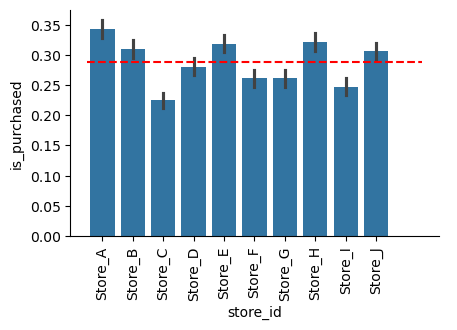

In [96]:
# グラフで確認してみる
sns.catplot(data=df1, x="store_id", y="is_purchased", kind="bar", aspect=1.5, height=3)
plt.hlines(df1.query('is_visited==1')['is_purchased'].mean(), xmin=-0.5, xmax=len(df1['store_id'].unique())-0.5, colors='red', linestyles='dashed', label='Overall Avg')
plt.xticks(rotation=90)
plt.show()

# 店舗によって、来店ベースの購入率には差がありそう（store_idは特徴量として役立ちそう）

## corr
- 目的変数と数値型特徴量との相関関係をみておく
  - check y工程のように個別にみるのもいいが、全体像をざっと把握するために相関係数でざっと眺める
- 例えばすごく相関の弱い特徴量があった場合、モデル作成後のSHAP解釈時にヒントにしやすい

In [97]:
# 数値型カラムと目的変数の相関係数

# 特徴量の重要度であればabsだけでもいいが、相関の正負も気にはなるので一度にまとめておこなう
raw_corr = df1.corr(numeric_only=True)['is_purchased']  # 生の相関係数を計算（absをつけない）
nan_rates = (df1.isnull().sum() / len(df1)) * 100  # 各カラムのnull率（%）を計算

# 目的変数（is_purchased）と同時に非nullだった有効な行数をカウント
numeric_cols = df1.select_dtypes(include=['number']).columns  # numeric_only=Trueに対応する列だけを対象にする
valid_counts = (df1[numeric_cols].notnull() & df1['is_purchased'].notnull().to_frame().values).sum()

corr_nan_report = pd.DataFrame({
    'raw_corr': raw_corr,
    'abs_corr': raw_corr.abs(),
    'null rate（%）': nan_rates,
    'valid count': valid_counts  # 有効行数
})
# corr絶対値の大きい順で並び替えて表示
print(corr_nan_report.sort_values(by='abs_corr', ascending=False).round(4).head(20))

# is_visitedがトップなのは当然ともいえるか。下位の特徴量はあまり重要ではないかも
# ただし相関行列はnullがないことにして計算してるため、下位でもnull率が高く、そしてnullに意味があるようならば、モデルにおいては重要となる可能性あり（なのでここであまり決めつけすぎない方がいい）

                          raw_corr  abs_corr  null rate（%）  valid count
is_purchased                1.0000    1.0000        0.0000     226596.0
is_visited                  0.5019    0.5019        0.0000     226596.0
app_pv                      0.4305    0.4305        1.0000     224330.0
is_raining                 -0.1642    0.1642       83.2870      37871.0
is_weekend                  0.1158    0.1158        0.0000     226596.0
day_of_week_num             0.0789    0.0789        0.0000     226596.0
is_holiday                  0.0479    0.0479        0.0000     226596.0
current_temp               -0.0162    0.0162        3.0001     219798.0
station_congestion_index    0.0105    0.0105       83.2870      37871.0
membership_days             0.0009    0.0009        0.7983     224787.0
daily_staffing_cost        -0.0004    0.0004       83.2870      37871.0
customer_id                    NaN       NaN        0.0000          NaN
date                           NaN       NaN        0.0000      

In [98]:
# 数値型カラムと目的変数の相関係数(来店ベースで)

# 特徴量の重要度であればabsだけでもいいが、相関の正負も気にはなるので一度にまとめておこなう
raw_corr = df1.query('is_visited==1').corr(numeric_only=True)['is_purchased']  # 生の相関係数を計算（absをつけない）
nan_rates = (df1.query('is_visited==1').isnull().sum() / len(df1.query('is_visited==1'))) * 100  # 各カラムのnull率（%）を計算

# 目的変数（is_purchased）と同時に非nullだった有効な行数をカウント
numeric_cols = df1.query('is_visited==1').select_dtypes(include=['number']).columns  # numeric_only=Trueに対応する列だけを対象にする
valid_counts = (df1.query('is_visited==1')[numeric_cols].notnull() & df1.query('is_visited==1')['is_purchased'].notnull().to_frame().values).sum()

corr_nan_report = pd.DataFrame({
    'raw_corr': raw_corr,
    'abs_corr': raw_corr.abs(),
    'null rate（%）': nan_rates,
    'valid count': valid_counts  # 有効行数
})
# corr絶対値の大きい順で並び替えて表示
print(corr_nan_report.sort_values(by='abs_corr', ascending=False).round(4).head(20))

# 全体ベースに比べて順位が上がる特徴量があれば有望（来店有無以外で目的変数との関連性強い）だが、そういうのはなさそう
# 逆に下がる（相関が弱くなる）特徴量は、is_visited（来店するかどうか）にだけ影響していたのかもしれない

# ただし、全体ベースとの対比の際は相関係数の差分にあまり引きづられないように注意
# なぜなら、来店ベースでは有効行数が激減しており、目的変数の意味合いが違ってるため
# 例えばapp_pvは全体ベースに比べて相関係数は小さくなった。app_pvの重要度低下とも見えるが早急に結論づけないほうがいいかも。
# 仮にこのデータセットがapp_pv=0のデータもたくさん含んでたとする。そしてアプリ起動しない（app_pv=0）→来店しない→購入しないという構図だったとする。この場合、全体ベースではapp_pv=0ならis_purchased=0という人たちが相関係数を引っ張り上げてたのかも。そして来店ベースではこの人たちがいなくなって相関係数が小さくなっただけかもしれない。つまりデータの分布（分散）がガラッと変わっただけかも。
# とはいえこのデータセットではapp_pv=0のデータは存在しない。この場合、全体ベースで相関強かったのは、ひょっとしたらapp_pvはこの日に来店するかどうかの先行指標なのかも（app_pv多いと来店しやすいのかも）。来店ベースで相関弱かったのは、ひょっとしたら来店してしまえば購入するかどうかにapp_pvの多少はあまり影響しないのかも。

# 全体ベースに引き続き、is_raining, is_weekendは上位にいることから特徴量としては有望なのかもしれない（同様理由で引き続き下位に止まる特徴量は略）

                          raw_corr  abs_corr  null rate（%）  valid count
is_purchased                1.0000    1.0000        0.0000      37871.0
is_raining                 -0.1642    0.1642        0.0000      37871.0
is_weekend                  0.1350    0.1350        0.0000      37871.0
app_pv                      0.1280    0.1280        0.9691      37504.0
day_of_week_num             0.0911    0.0911        0.0000      37871.0
is_holiday                  0.0536    0.0536        0.0000      37871.0
current_temp               -0.0255    0.0255        2.9336      36760.0
membership_days            -0.0186    0.0186        0.8450      37551.0
station_congestion_index    0.0105    0.0105        0.0000      37871.0
daily_staffing_cost        -0.0004    0.0004        0.0000      37871.0
customer_id                    NaN       NaN        0.0000          NaN
date                           NaN       NaN        0.0000          NaN
is_visited                     NaN       NaN        0.0000      

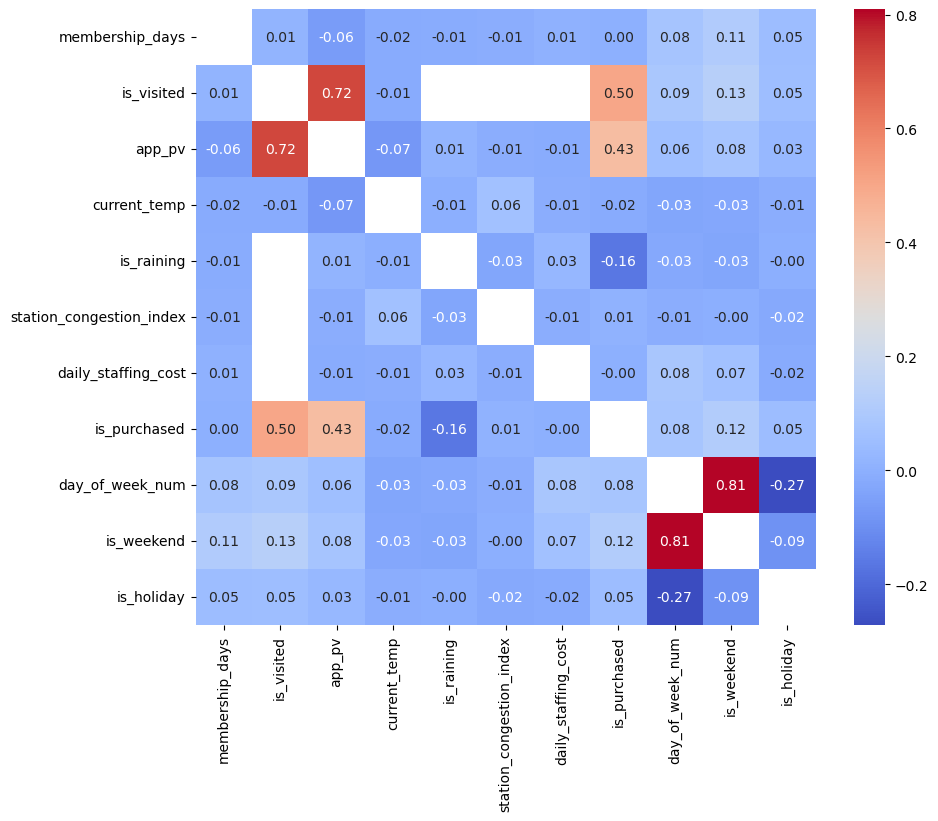

✅ 特徴量同士の異常な重複（マルチコ）は検出されなかったにゃん!


In [99]:
# 数値型カラムと目的変数の相関行列をヒートマップとしてプロット
cm_corr = df1.corr(numeric_only=True).round(3)
# 対角成分をNaNにする
for i in range(len(cm_corr)):
    cm_corr.iat[i, i] = np.nan

plt.figure(figsize=(10, 8))
sns.heatmap(cm_corr, annot=True, cmap='coolwarm', fmt='.2f', xticklabels=cm_corr.columns, yticklabels=cm_corr.columns)
plt.show()


# 相関の絶対値が 0.90 以上の、マルチコ危険カラムペアを抽出
threshold = 0.90
upper_tri = cm_corr.abs().where(np.triu(np.ones(cm_corr.shape), k=1).astype(bool))

dangerous_pairs = [(column, row) for column in upper_tri.columns for row in upper_tri.index if upper_tri.loc[row, column] > threshold]

if dangerous_pairs:
    print(f"🚨 【マルチコ警告】相関が {threshold} 以上の危険な重複ペアがあるにゃん。片方の削除を検討してにゃん!")
    for pair in dangerous_pairs:
        print(f"   ∟ {pair[0]} × {pair[1]} (相関: {cm_corr.loc[pair[1], pair[0]]})")
else:
    print("✅ 特徴量同士の異常な重複（マルチコ）は検出されなかったにゃん!")


# 特徴量同士の相関をみておくことで、特徴量を減らす際の参考にする
# LGBM自体は多重共線性（マルチコ）にかなり強いが、Feature Importance（特徴量の重要度）やSHAP値（モデルの解釈性）を計算するときに問題が発生する。
# 1つの強力なシグナルをモデルが使いたいときに、相関係数が例えば0.95とかほぼクローンな2つの特徴量にその予測パワーが半分ずつ分散（希釈）されてしまう。すると本当は超重要なのに重要度で2つとも中途半端な下位に沈んで、あまり効いてないんだなと解釈を見誤る原因になる
# ので例えばここで指定したthreholdを上回るようなペアがあったら、モデリングに進む前にどちらか片方を削除するという、前処理の意思決定に役立てる

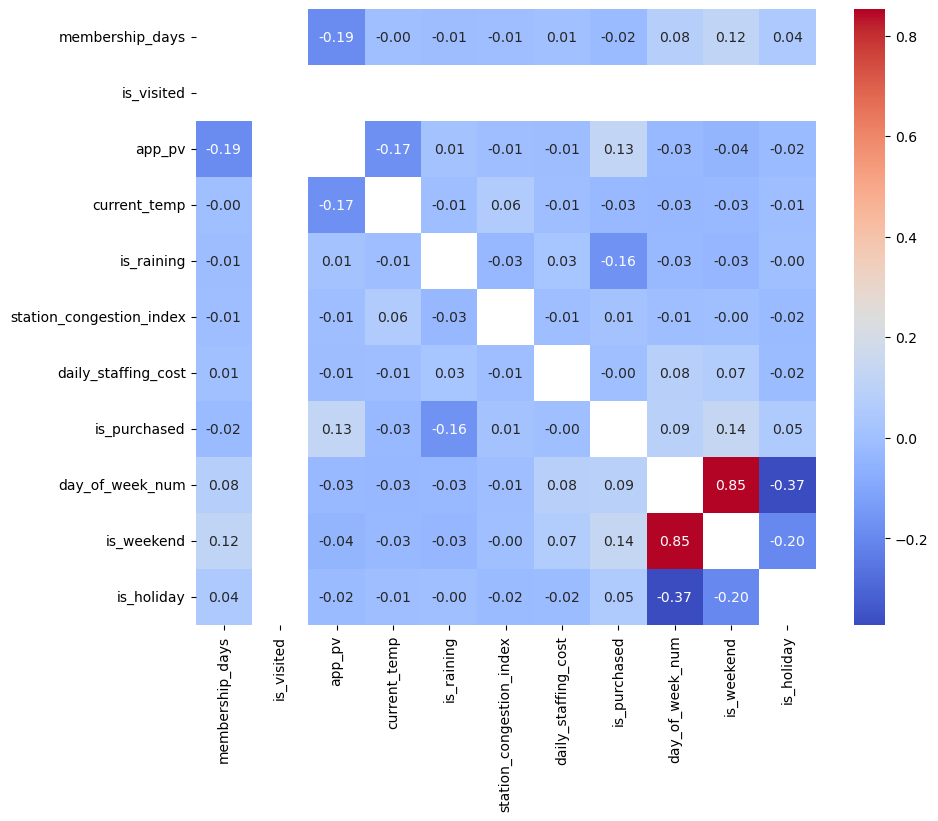

✅ 特徴量同士の異常な重複（マルチコ）は検出されなかったにゃん!


In [100]:
# 数値型カラムと目的変数の相関行列をヒートマップとしてプロット（来店ベース）
cm_corr = df1.query('is_visited==1').corr(numeric_only=True).round(3)
# 対角成分をNaNにする
for i in range(len(cm_corr)):
    cm_corr.iat[i, i] = np.nan

plt.figure(figsize=(10, 8))
sns.heatmap(cm_corr, annot=True, cmap='coolwarm', fmt='.2f', xticklabels=cm_corr.columns, yticklabels=cm_corr.columns)
plt.show()


# 相関の絶対値が 0.90 以上の、マルチコ危険カラムペアを抽出
threshold = 0.90
upper_tri = cm_corr.abs().where(np.triu(np.ones(cm_corr.shape), k=1).astype(bool))

dangerous_pairs = [(column, row) for column in upper_tri.columns for row in upper_tri.index if upper_tri.loc[row, column] > threshold]

if dangerous_pairs:
    print(f"🚨 【マルチコ警告】相関が {threshold} 以上の危険な重複ペアがあるにゃん。片方の削除を検討してにゃん!")
    for pair in dangerous_pairs:
        print(f"   ∟ {pair[0]} × {pair[1]} (相関: {cm_corr.loc[pair[1], pair[0]]})")
else:
    print("✅ 特徴量同士の異常な重複（マルチコ）は検出されなかったにゃん!")

## Segment store
- 店舗の特性: store_id単位で比較（集団や層による影響ありそうか）
- 店舗別の購入率についてはcheck y工程ですでに見ているので他の特徴量について
- EDAは特徴量エンジニアリング目的なのと、store_id自体が特徴量として役立ちそうなことはわかっているので、興味本位で深入りしすぎない

In [101]:
# null check工程でis_purchased, is_visited（0/1の2値）が0だとstore_idはnullになるとわかっている
# なので以下はcountにしても出力値は同じだし、meanだと全部1になる（store_idがnullでなければ必ずis_visited=1のデータになってる） 
df1.groupby('store_id')['is_visited'].sum().round(3)
# df1.groupby('store_id')['is_visited'].mean().round(3)

# 店によって来店数が極端に違うということはなさそう

store_id
Store_A    3975
Store_B    3754
Store_C    3887
Store_D    3815
Store_E    3926
Store_F    3759
Store_G    3662
Store_H    3557
Store_I    3562
Store_J    3974
Name: is_visited, dtype: int64

In [102]:
# 数値型カラムについて、店舗(store_id)ごとの平均値をみる

df1.groupby('store_id').mean(numeric_only=True)

,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,is_purchased,day_of_week_num,is_weekend,is_holiday
store_id,,,,,,,,,,,
Store_A,351.076474,1.0,5.297366,18.301565,0.146415,100.898308,103985.652830,0.342893,3.579874,0.473459,0.100881
Store_B,373.766066,1.0,5.352101,18.185813,0.178210,100.497828,103223.550346,0.310069,3.501598,0.456846,0.110815
Store_C,344.626622,1.0,5.398232,18.139033,0.239002,99.126196,101355.823772,0.224852,3.548495,0.467713,0.101364
Store_D,354.271240,1.0,5.416578,18.136643,0.158585,103.665916,100337.660813,0.280472,3.532896,0.457929,0.107208
Store_E,342.787988,1.0,5.299820,18.090730,0.230769,99.008902,103926.824503,0.318645,3.512736,0.458482,0.112328
Store_F,361.677584,1.0,5.369834,18.036304,0.234637,97.075678,100307.707369,0.261772,3.544826,0.470604,0.111732
Store_G,362.034113,1.0,5.356040,18.370766,0.225287,96.385182,100055.870563,0.261060,3.501365,0.448116,0.101038
Store_H,381.323704,1.0,5.219096,18.229118,0.159685,102.249816,97660.570425,0.321619,3.588136,0.475119,0.105988
Store_I,379.658440,1.0,5.330309,18.125797,0.161707,99.073109,100031.100505,0.247052,3.549691,0.465750,0.110893


In [103]:
# 気になるもの（平均値が大きく違いそうなもの）があれば、さらに詳しくみる

df1.groupby('store_id')['current_temp'].describe().round(3)

# ほぼ同じ。time series工程で同じdateは同じcurrent_tempらしいことが見えていたが、store_idによってcurrent_tempが違うということはないのかもしれない

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,3856.0,18.302,4.428,9.73,14.948,17.870,21.144,27.346
Store_B,3636.0,18.186,4.591,9.73,14.583,17.349,21.738,27.346
Store_C,3783.0,18.139,4.450,9.73,14.804,17.620,21.144,27.346
Store_D,3697.0,18.137,4.470,9.73,14.804,17.349,21.144,27.346
Store_E,3806.0,18.091,4.389,9.73,14.804,17.620,20.874,27.346
Store_F,3642.0,18.036,4.436,9.73,14.583,17.315,20.874,27.346
Store_G,3547.0,18.371,4.427,9.73,14.993,17.870,21.571,27.346
Store_H,3457.0,18.229,4.416,9.73,14.993,17.641,21.144,27.346
Store_I,3465.0,18.126,4.470,9.73,14.804,17.349,21.144,27.346


In [104]:
df1.pivot_table(index='date', columns='store_id', values='current_temp', aggfunc='mean')

# 同じdateであれば、store_idに関係なく同じcurrent_tempらしい

store_id,Store_A,Store_B,Store_C,Store_D,Store_E,Store_F,Store_G,Store_H,Store_I,Store_J
date,,,,,,,,,,
2025-09-01,25.224503,25.224503,25.224503,25.224503,25.224503,25.224503,25.224503,25.224503,25.224503,25.224503
2025-09-02,26.017543,26.017543,26.017543,26.017543,26.017543,26.017543,26.017543,26.017543,26.017543,26.017543
2025-09-03,27.166951,27.166951,27.166951,27.166951,27.166951,27.166951,27.166951,27.166951,27.166951,27.166951
2025-09-04,26.919087,26.919087,26.919087,26.919087,26.919087,26.919087,26.919087,26.919087,26.919087,26.919087
2025-09-05,27.226577,27.226577,27.226577,27.226577,27.226577,27.226577,27.226577,27.226577,27.226577,27.226577
...,...,...,...,...,...,...,...,...,...,...
2025-11-26,16.271882,16.271882,16.271882,16.271882,16.271882,16.271882,16.271882,16.271882,16.271882,16.271882
2025-11-27,14.992891,14.992891,14.992891,14.992891,14.992891,14.992891,14.992891,14.992891,14.992891,14.992891
2025-11-28,16.333757,16.333757,16.333757,16.333757,16.333757,16.333757,16.333757,16.333757,16.333757,16.333757


## Segment customer
- 顧客の定着: customer_id単位で出現回数の分布（常連さんと一見さんがいるのか）
- 本分析のテーマ（顧客単位での分類予測）に照らし合わせても、あれこれEDAしてみる意義がある
- またデータセット自体のドメイン知識は乏しくとも、時点データの特性やマーケティング観点を糸口に探索するとよさそう
- 例えばRFM（Recency, Frequency, Monetary value）のうち、Monetaryは情報なしだが、出現回数（Frequency）以外に、直近の行動履歴（Recency）という考え方もある

顧客の行動履歴データ
- is_visited（来店有無） is_purchased（購入有無） app_pv（アプリ閲覧数）
- ここまでの探索から、app_pvが発生した場合にその日のdateでログが生まれるっぽい

In [105]:
# 常連さんと一見さんがいるのか

# 期間計での出現回数（app_pv発生日数）を顧客単位でカウント
print(df1["customer_id"].value_counts(ascending=False).head())
print(df1["customer_id"].value_counts(ascending=True).head())

# いるらしい

customer_id
byfytndh    74
v05h7rda    71
eqh7iw8g    71
2gx0bbpl    70
rslxex03    70
Name: count, dtype: int64
customer_id
r0y3n754    1
h6d3t30y    1
h5nmuxrz    1
plpk1wqs    1
0utdkmid    1
Name: count, dtype: int64


In [106]:
# 顧客単位で集約したDataFrameを作る

# app_pv以外のis_visitedやis_purchasedについても顧客特性の違い（常連さんか一見さんか）を把握する意図
df_user = df1.groupby('customer_id').agg(
    total_count=('customer_id', 'count'),  # その人の出現回数（全ログ行数、app_pv発生日数）
    visit=('is_visited', 'sum'),  # 来店日数
    purchase=('is_purchased', 'sum')  # 購入日数
).reset_index()

# 期間計での来店率と購入率（来店ベース）を計算
df_user['visit_rate'] = (df_user['visit'] / df_user['total_count'])
df_user['purchase_rate'] = (df_user['purchase'] / df_user['visit']).fillna(0)  # 来店日数が0の人は購入率を0にする
"""
- 購入率の分母は来店率の分母にそろえたくなるが、total_countという同じ情報が両方に入ってしまう（特徴量同士の相関が強くなってマルチコっぽい感じになってしまう）
- 購入率の分母を来店日数にすることで、来店率=足を運ぶ動機（例えばapp_pvが誘発する来店意欲とか）と、来店ベース購入率=来店時の財布の紐の緩さ（購入意欲のようなものとか）と、それぞれの特徴量が「異なる要素の顧客特性」を表現しやすくなる
"""

df_user.head()

,customer_id,total_count,visit,purchase,visit_rate,purchase_rate
0,002ec2m6,29,2,0,0.068966,0.000000
1,002ic2u8,13,1,0,0.076923,0.000000
2,004lflnv,54,8,0,0.148148,0.000000
3,007u3616,25,1,0,0.040000,0.000000
4,0089km8u,22,3,2,0.136364,0.666667


In [107]:
df_user[['total_count', 'visit', 'purchase', 'visit_rate', 'purchase_rate']].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(4)

# 1人あたりのapp_pv発生日数は平均22日、来店日数4日、購入日数1日、来店率0.17、（来店ベース）購入率0.27

,total_count,visit,purchase,visit_rate,purchase_rate
count,9995.0000,9995.0000,9995.0000,9995.0000,9995.0000
mean,22.6709,3.7890,1.0907,0.1656,0.2659
std,12.6690,2.9457,1.4793,0.0983,0.3157
min,1.0000,0.0000,0.0000,0.0000,0.0000
1%,5.0000,0.0000,0.0000,0.0000,0.0000
5%,9.0000,0.0000,0.0000,0.0000,0.0000
10%,10.0000,1.0000,0.0000,0.0556,0.0000
25%,14.0000,2.0000,0.0000,0.1000,0.0000
50%,19.0000,3.0000,1.0000,0.1549,0.1667
75%,29.0000,5.0000,2.0000,0.2222,0.5000


In [108]:
# 出現回数を適度に区分して、来店率や購入率との関係性をみる

# 機械的に4等分（quantile）してみる
df_user['total_count_freq'] = pd.qcut(df_user['total_count'], q=4, labels=['1_Light', '2_Medium-low', '3_Medium-high', '4_Heavy'])

res = df_user.drop(columns=["customer_id"]).groupby("total_count_freq", observed=False).mean().round(2)
# 対象カラム自体の件数(行数)をsize()でcountしてデータフレームの先頭に差し込む
res.insert(0, "count", df_user.groupby(df_user['total_count_freq']).size())
res

# 出現回数が多いほど、来店日数や購入日数は多い。来店率や購入率は大差ないようにも増加するようにも思える

,count,total_count,visit,purchase,visit_rate,purchase_rate
total_count_freq,,,,,,
1_Light,3013,11.02,1.71,0.50,0.15,0.24
2_Medium-low,2243,16.81,2.83,0.80,0.17,0.26
3_Medium-high,2308,23.68,4.15,1.17,0.18,0.28
4_Heavy,2431,41.56,6.91,2.02,0.17,0.29


In [109]:
# 出現回数をキリの良い数字で区切るなら
def get_freq_tier(count):
    if 1 <= count <= 10:
        return '1_Light(1-10)'
    elif 11 <= count <= 20:
        return '2_Medium-low(11-20)'
    elif 21 <= count <= 30:
        return '3_Medium-high(21-30)'
    else:
        return '4_Heavy(31+)'

# total_countに適用
df_user['total_count_freq'] = df_user['total_count'].apply(get_freq_tier)

# 上と同じ
res = df_user.drop(columns=["customer_id"]).groupby("total_count_freq", observed=False).mean().round(2)
res.insert(0, "count", df_user.groupby(df_user['total_count_freq']).size())
res

# quantileと刻みがあまり変わってないもあり、大きな違いはなさそう（というか判断しにくい）

,count,total_count,visit,purchase,visit_rate,purchase_rate
total_count_freq,,,,,,
1_Light(1-10),1058,8.08,1.22,0.36,0.15,0.21
2_Medium-low(11-20),4572,15.28,2.52,0.72,0.16,0.26
3_Medium-high(21-30),2082,24.79,4.33,1.24,0.18,0.28
4_Heavy(31+),2283,42.31,7.02,2.04,0.17,0.29


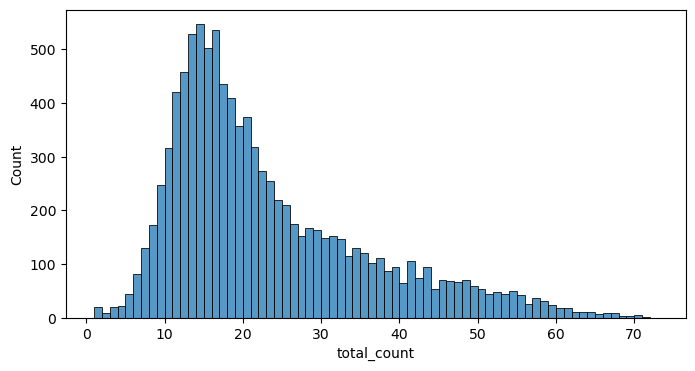

In [110]:
# 顧客別出現回数のhistogramをプロット
# 出現回数の（ある意味）恣意的な区分では、来店率や購入率の傾向を見誤る可能性が残ることから、ちょっと立ち戻って分布の形状をみておく

plt.figure(figsize=(8, 4))
# 出現回数は離散値のため、binsの数値指定次第ではギザギザなhistogramになる場合があることからrange指定する
# sns.histplot(data=df_user, x='total_count', bins=range(1, customer_counts.max()), kde=True, stat="density")
sns.histplot(data=df_user, x='total_count', bins=range(1, df_user['total_count'].max()), kde=False)
plt.show()

# 最頻値は左側に寄っていて裾が長い分布らしい（app_pv発生日数はロングテール）

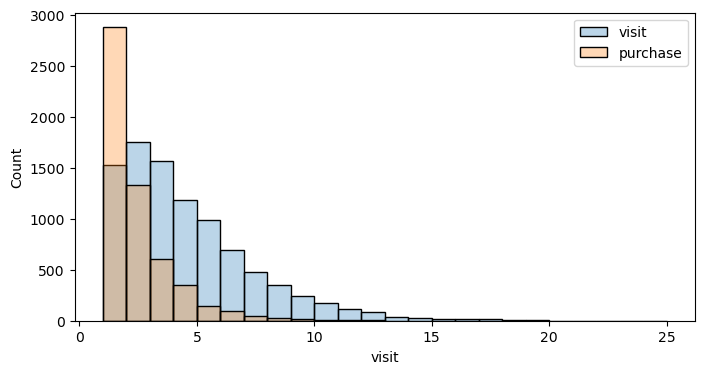

In [111]:
# 顧客別来店日数、購入日数のhistogramをプロット

plt.figure(figsize=(8, 4))
sns.histplot(data=df_user, x='visit', bins=range(1, df_user['visit'].max()), kde=False, alpha=0.3, label='visit')
sns.histplot(data=df_user, x='purchase', bins=range(1, df_user['purchase'].max()), kde=False, alpha=0.3, label='purchase')
plt.legend()
plt.show()

# 出現回数同様に、最頻値は左側に寄っていて裾が長い分布らしい

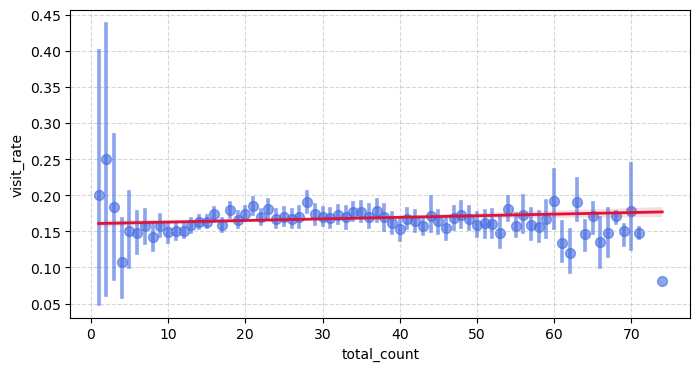

In [112]:
# 出現回数別の期間内来店率をプロット

plt.figure(figsize=(8, 4))
# 横軸: 出現回数、縦軸: 出現回数別の平均来店率
sns.regplot(data=df_user, x='total_count', y='visit_rate',
    x_estimator=np.mean,   # x軸の値ごとにyの平均値をプロットするように指定
    # order=2,  # 多項式回帰を指定して非線形なトレンドを見ることもできる（未指定時は線形近似直線が描画される）
    scatter_kws={"color": "royalblue", "alpha": 0.6},
    line_kws={"color": "crimson", "linewidth": 2}
)
# x_estimator=np.meanを指定しないと、x軸の値ごとにyの平均値ではなく、ユーザー単位のvisit_rateがプロットされる。来店率は左端（出現回数1回）では0/1の値をとる。平均的な来店率が0に近い場合、右にいくほど来店率が低い方のプロットが多くなり、なにか意味ありげなプロットに見えてしまう
plt.grid(True, linestyle='dashed', alpha=0.5)
plt.show()

# 左端ではバラツキが大きい（人数が少なく95%ciが広い）ながらも平均来店率はやや高め、右端でもバラツキが大きい（人数少ないため）ながらも平均来店率が少々高い場合もあるか（出現回数が多い人ほど、期間内来店率が低い傾向があるように見える）
# 近似直線(赤線)はほぼ横向き、気持ち右肩上がりか。つまり1人あたりの期間内来店率は出現回数によらず大局的にはほぼ同程度。出現回数がすごく少ない場合とすごく多い場合には少々高めなのかもしれない

# ただしあくまで期間内計での来店率。ひょっとしたらその時々や状況に応じて違いはあるのかもしれない

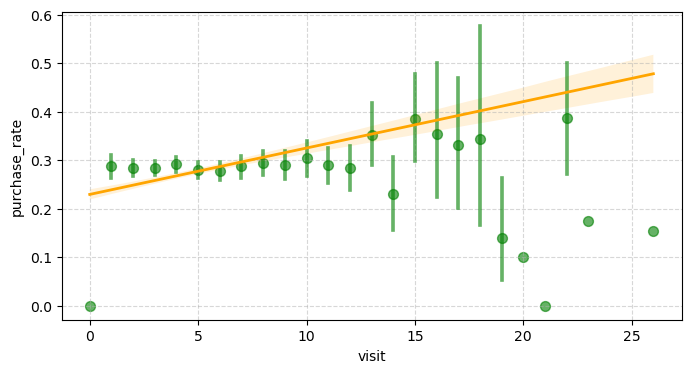

In [113]:
# 来店日数別の期間内購入率(来店ベース)をプロット

plt.figure(figsize=(8, 4))

# 横軸: 来店日数、縦軸: 来店日数別の平均購入率
sns.regplot(data=df_user, x='visit', y='purchase_rate',
    x_estimator=np.mean,   # x軸の値ごとにyの平均値をプロットするように指定
    # order=2,  # 多項式回帰を指定して非線形なトレンドを見ることもできる（未指定時は線形近似直線が描画される）
    scatter_kws={"color": "green", "alpha": 0.6},
    line_kws={"color": "orange", "linewidth": 2}
)
# x_estimator=np.meanを指定しないと、x軸の値ごとにyの平均値ではなく、ユーザー単位のpurchase_rateがプロットされる。購入率は左端（出現回数1回）では0/1の値をとる。平均的な購入率が0に近い場合、右にいくほど購入率が低い方のプロットが多くなり、なにか意味ありげなプロットに見えてしまう
plt.grid(True, linestyle='dashed', alpha=0.5)
plt.show()

# （右にいくほどバラツキ大きいが）来店日数が多いと、購入しやすいのかも
# ただし来店率同様にあくまで期間内計での集計値である。ひょっとしたらその時々や状況に応じて違いはあるのかもしれない

## Segment customer rolling
- 時点データの特性を活かして、過去一定期間の行動履歴を探索してみる
- このデータセットの場合は集計時に注意が必要
- めぼしい特徴量の探索が目的なので、新規作成した特徴量自体をEDAするのは後からゆっくりやろうね

**rolling（や累積の特徴量を作る際に）どう集約するか**
- 基本はmeanが無難かも
- nullが多かったり、2値のうちどちらかに偏ってる場合は、sumの方が情報が濃くなるかも
- マイルドな割合（mean）よりは、蓄積（値の積み重ね）の方が目的変数との関係をうまく表現できそうならsumがいいかも
- とはいえ足し算(sum)に意味がない尺度の場合は、meanだろう（気温のような比率尺度とか）
- mean,sum以外だと、max,min,std
- 迷うときや急ぐときはひとまずmeanにして、後から考える
- rolling（移動）以外だと、expanding（累積）もある

In [114]:
# というわけで改めて数値型カラムの要約統計量をみておく
df1.describe(include='number').round(2)

# is_visited（不均衡）, is_purchased（不均衡）, is_raining（null多い）: sumがいいかもね
# 残りはmeanがよさそう

,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,is_purchased,day_of_week_num,is_weekend,is_holiday
count,224787.00,226596.00,224330.00,219798.00,37871.00,37871.00,37871.00,226596.00,226596.00,226596.00,226596.00
mean,352.54,0.17,1.88,18.31,0.19,99.81,101465.76,0.05,3.13,0.33,0.08
std,274.77,0.37,2.14,4.56,0.39,14.60,29440.15,0.21,2.04,0.47,0.27
min,0.00,0.00,1.00,9.73,0.00,48.44,50162.00,0.00,0.00,0.00,0.00
25%,116.00,0.00,1.00,14.95,0.00,90.38,74905.00,0.00,1.00,0.00,0.00
50%,281.00,0.00,1.00,17.64,0.00,99.74,102260.00,0.00,3.00,0.00,0.00
75%,562.00,0.00,2.00,21.57,0.00,109.34,126524.00,0.00,5.00,1.00,0.00
max,999.00,1.00,29.00,27.35,1.00,152.67,149982.00,1.00,6.00,1.00,1.00


In [115]:
# このデータセットでは時点が連続していない

# df1.groupby('customer_id')['date'].nunique()
df1.sort_values(['customer_id', 'date']).head()

# 顧客それぞれのdate（app_pv発生日）は日付が飛び飛びになっている、以下ではその点を考慮して処理する

,date,customer_id,store_id,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,is_purchased,day_of_week_num,is_weekend,is_holiday
5172,2025-09-03,002ec2m6,NaN,281.0,0,1.0,27.166951,NaN,NaN,NaN,0,2,0,0
13640,2025-09-07,002ec2m6,NaN,285.0,0,1.0,25.900945,NaN,NaN,NaN,0,6,1,0
17559,2025-09-08,002ec2m6,NaN,286.0,0,1.0,25.791471,NaN,NaN,NaN,0,0,0,0
27933,2025-09-13,002ec2m6,NaN,291.0,0,1.0,24.583391,NaN,NaN,NaN,0,5,1,0
30237,2025-09-14,002ec2m6,NaN,292.0,0,1.0,25.007084,NaN,NaN,NaN,0,6,1,0


In [116]:
# 顧客別の過去hoge日間の来店日数、購入日数、購入率を算出する

# dateとstore_idではソート済みだが、customed_id順ではソートしてないので、まずはソートしてdataframeを作る
# customer_idのソートは実行内容には無関係。実行結果が目視確認しやすいという点で安心安全
df_ts = df1.sort_values(by=['customer_id', 'date']).reset_index(drop=True)

"""
dateが飛び飛びのデータセットで移動平均計算して元のdataframeに代入するというわかりにくいコードの説明にゃん
- set_index('date'): dateをインデックスにして後続のウィンドウ'7D'を正しく機能させる（元のインデックスは変わらない）
- groupby: 以降集計値を切り分けたいセグメントの指定
- transform: SQLのOVER()に相当、元のdf_tsの行数そのままでウィンドウ関数の結果を代入する
  - lambda x: （groupbyで指定したグループごとに）データxに対して、以下を実行する関数の定義
  - shift(1): 1行ずらすことで「当日を含まない、未来をカンニングできない」前日までを対象に、
  - rolling('7D': 7日間（7行ではなく、当日の日付から7日前までに収まる日付の行のみを対象にした）移動平均を、
  - min_periods=1: 7日分のデータがまるまるなくても、あるぶんのデータで計算する
- values: 計算結果の数字だけの配列を取り出して代入する（set_indexやgroupbyでのインデックスが残ってると元々のインデックスと一致しなくてpandasが迷子になる。transformは行数が合うようには機能するがインデックスの違いまでは対処しきれない）

- なぜ7日？データセットの期間が91日間で、モデル作成時にsplitすることを踏まえるとあまり長くはしにくい。かといって平日/週末で動向に差がある（週の周期性がある）ことはわかっており3や5では周期性が残りそうなため
- モデル作成時には3や5のを投入するのはアリ（ここでは代表して7のをみてるだけ）
"""

# app_pv発生日数の移動平均: 来店率の分母にも使いたいのでcountにしている
df_ts['rolling_count_7d'] = (
    df_ts.set_index('date')
    .groupby('customer_id')['customer_id']
    .transform(lambda x: x.shift(1).rolling('7D', min_periods=1).count())  
    .values
)

df_ts['rolling_visit_7d'] = (
    df_ts.set_index('date')
    .groupby('customer_id')['is_visited']
    .transform(lambda x: x.shift(1).rolling('7D', min_periods=1).sum())
    .values
)

df_ts['rolling_purchase_7d'] = (
    df_ts.set_index('date')
    .groupby('customer_id')['is_purchased']
    .transform(lambda x: x.shift(1).rolling('7D', min_periods=1).sum())
    .values
)

# あまり細かいことは気にせずに、以下のような数値型カラムについてもrollingの特徴量を作ってみるのはあり
# モデルに役立つかはモデルに考えてもらえばよい（とはいえここでは省略する）
# membership_days, app_pv, current_temp, is_raining, station_congestion_index, daily_staffing_cost

# 割り算値の計算（分母が0の日はNaNになるので0で穴埋め）
df_ts['rolling_visit_rate_7d'] = (df_ts['rolling_visit_7d'] / df_ts['rolling_count_7d']).fillna(0).round(4)
df_ts['rolling_purchase_rate_7d'] = (df_ts['rolling_purchase_7d'] / df_ts['rolling_visit_7d']).fillna(0).round(4)
# 来店(1ならば)→購入(0/1)、来店0=購入0という構図がわかってるので、移動平均購入率の分母は引き続き来店ベースにする
# 来店率と購入率で分母を変えることで、それぞれの特徴量が「異なる要素の顧客特性」を表現しやすくなる
# ただし、代入するdf_tsはis_visited=0の行も存在するため、移動平均購入率の分母を来店ベースにしてても、なんらか集計時は来店ベースに絞り込む必要ある

df_ts.head()

,date,customer_id,store_id,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,is_purchased,day_of_week_num,is_weekend,is_holiday,rolling_count_7d,rolling_visit_7d,rolling_purchase_7d,rolling_visit_rate_7d,rolling_purchase_rate_7d
0,2025-09-03,002ec2m6,NaN,281.0,0,1.0,27.166951,NaN,NaN,NaN,0,2,0,0,0.0,NaN,NaN,0.0,0.0
1,2025-09-07,002ec2m6,NaN,285.0,0,1.0,25.900945,NaN,NaN,NaN,0,6,1,0,1.0,0.0,0.0,0.0,0.0
2,2025-09-08,002ec2m6,NaN,286.0,0,1.0,25.791471,NaN,NaN,NaN,0,0,0,0,2.0,0.0,0.0,0.0,0.0
3,2025-09-13,002ec2m6,NaN,291.0,0,1.0,24.583391,NaN,NaN,NaN,0,5,1,0,3.0,0.0,0.0,0.0,0.0
4,2025-09-14,002ec2m6,NaN,292.0,0,1.0,25.007084,NaN,NaN,NaN,0,6,1,0,3.0,0.0,0.0,0.0,0.0


In [117]:
# # 期待していた集計がちゃんとできてそうか（目視確認）

# # 先にcustomer_id単位で集約したdataframeからpurchase>0を1人指定
# target_id = df_user.query("purchase > 0")['customer_id'].iloc[0]

# # カラムが多いので見たいところだけを指定
# target_col = ['date', 'customer_id', 'rolling_count_7d', 'is_visited', 'rolling_visit_7d', 'rolling_visit_rate_7d', 'is_purchased', 'rolling_purchase_7d', 'rolling_purchase_rate_7d']

# # 指定分だけを表示
# # 日付が飛び飛びなので目視はちょっと大変。当日以降の未来をリークする集計値になっていないかをきっちり確認したいならやろうね
# df_ts[target_col].query("customer_id == @target_id").head(15)

In [118]:
# 期待していた集計がちゃんとできてそうか
# nullがどのくらいあるかと要約統計量チェック

target_col = ['rolling_count_7d', 'rolling_visit_7d', 'rolling_purchase_7d', 'rolling_visit_rate_7d',  'rolling_purchase_rate_7d']

# 前に作成した自作関数でnull率などを出力
# check_null_and_uniques(df_ts, columns=target_col)  # これだとshift(1)による先頭行NaNも含まれる
check_null_and_uniques(df_ts.groupby('customer_id').tail(-1), columns=target_col)  # 各顧客の2行目以降だけに絞る

# df_ts[target_col].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(4)  # 下で見ることにして省略 

# 極端にnullが多かったり、不自然な（ありえない）代表値になってなければOK

,type,total_count,non_null,null,null_rate(%),unique,non_null/unique
rolling_count_7d,float64,216601,216601,0,0.0,7,30943.00
rolling_visit_7d,float64,216601,216601,0,0.0,7,30943.00
rolling_purchase_7d,float64,216601,216601,0,0.0,6,36100.17
rolling_visit_rate_7d,float64,216601,216601,0,0.0,18,12033.39
rolling_purchase_rate_7d,float64,216601,216601,0,0.0,11,19691.00


In [119]:
# 新規作成した特徴量はモデルに役立ちそうか

# 目的変数で区分して、要約統計量をみる
# boxplot,histplot,kdeなどのほうが見た目にわかりやすいが、離散値と0過剰データで見づらいのでここでは未実施
print(df_ts.groupby('is_purchased')['rolling_count_7d'].describe().round(2))
print(df_ts.groupby('is_purchased')['rolling_visit_7d'].describe().round(2))
print(df_ts.groupby('is_purchased')['rolling_purchase_7d'].describe().round(2))

print(df_ts.groupby('is_purchased')['rolling_visit_rate_7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.query('is_visited==1').groupby('is_purchased')['rolling_purchase_rate_7d'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

# 2群間で分布や平均にある程度の違いがあれば、モデルに役立ちやすい（目的変数を分岐しやすい）特徴量かも
# あまり違いがなかった場合は、モデル投入を断念する必要はなくて、次なる特徴量を探す方向に動く

                 count  mean   std  min  25%  50%  75%  max
is_purchased                                               
0             215694.0  2.84  1.61  0.0  2.0  3.0  4.0  7.0
1              10902.0  2.91  1.59  0.0  2.0  3.0  4.0  7.0
                 count  mean   std  min  25%  50%  75%  max
is_purchased                                               
0             206022.0  0.49  0.69  0.0  0.0  0.0  1.0  6.0
1              10579.0  0.52  0.71  0.0  0.0  0.0  1.0  5.0
                 count  mean   std  min  25%  50%  75%  max
is_purchased                                               
0             206022.0  0.14  0.38  0.0  0.0  0.0  0.0  5.0
1              10579.0  0.21  0.47  0.0  0.0  0.0  0.0  4.0
                 count  mean   std  min  25%  50%   75%  90%   95%  99%  max
is_purchased                                                                
0             215694.0  0.16  0.25  0.0  0.0  0.0  0.25  0.5  0.67  1.0  1.0
1              10902.0  0.17  0.26  0.0  0.0  0.0

- 新規作成した特徴量自体をEDAするなら
  - なんらかの顧客区分でセグメントしたり、時点推移を眺めたり、元の値と移動平均値を対比など

In [120]:
# # EDA: 例えば直近7日間のapp_pv発生日数で顧客を4区分して比較

# # app_pv発生日数で4区分してみる
# def get_freq_tier(count):
#     if count <= 1:
#         return '1_Light(1)'
#     elif 2 <= count <= 3:
#         return '2_Medium-low(2-3)'
#     elif 4 <= count <= 5:
#         return '3_Medium(4-5)'
#     else:
#         return '4_Heavy(6+)'
# # 直近7日間のapp_pv発生日数に適用
# df_ts['rolling_count_7d_freq'] = df_ts['rolling_count_7d'].apply(get_freq_tier)

# # 集計対象のカラムを指定してセグメント別にmeanを計算
# # 'rolling_purchase_rate_7d'があるので来店ベースで集計するのがいいかもね
# res = df_ts.groupby("rolling_count_7d_freq", observed=False)[['rolling_count_7d', 'rolling_visit_7d', 'rolling_purchase_7d', 'rolling_visit_rate_7d', 'rolling_purchase_rate_7d']].mean().round(2)
# res.insert(0, "count", df_ts.groupby(df_ts['rolling_count_7d_freq']).size())
# res

In [121]:
# # EDA: 例えば直近7日間の来店日数で顧客を4区分して比較

# # 来店日数で4区分してみる
# def get_freq_tier(count):
#     if count <= 0:
#         return '1_Non(0)'
#     elif 1 <= count <= 1:
#         return '2_Light(1)'
#     elif 2 <= count <= 2:
#         return '3_Medium(2)'
#     else:
#         return '4_Heavy(3+)'

# # 直近7日間の来店日数に適用
# df_ts['rolling_visit_7d_freq'] = df_ts['rolling_visit_7d'].apply(get_freq_tier)

# # 集計対象のカラムを指定してセグメント別にmeanを計算
# # 'rolling_purchase_rate_7d'があるので来店ベースで集計するのがいいかもね
# res = df_ts.groupby("rolling_visit_7d_freq", observed=False)[['rolling_visit_7d', 'rolling_purchase_7d', 'rolling_purchase_rate_7d']].mean().round(2)
# res.insert(0, "count", df_ts.groupby(df_ts['rolling_visit_7d_freq']).size())
# res

In [122]:
# # EDA: 例えば直近7日間来店日数、購入日数の日別推移
# plt.figure(figsize=(10, 4))
# sns.lineplot(data=df_ts, x="date", y="rolling_visit_7d", errorbar="ci", label='rolling_visit_7d')
# sns.lineplot(data=df_ts, x="date", y="rolling_purchase_7d", errorbar="ci", label='rolling_purchase_7d')
# plt.ylabel('Days per Weekly')
# plt.grid(True, axis='y', linestyle='dashed', alpha=0.5)
# plt.legend()
# plt.show()

In [123]:
# # EDA: 例えば直近7日間来店率の日別推移
# plt.figure(figsize=(10, 4))
# sns.lineplot(data=df_ts, x="date", y="is_visited", errorbar="ci", label='is_visited')
# sns.lineplot(data=df_ts, x="date", y="rolling_visit_rate_7d", errorbar="ci", label='rolling_visit_rate_7d')
# plt.grid(True, axis='y', linestyle='dashed', alpha=0.5)
# plt.legend()
# plt.show()

In [124]:
# # EDA: 直近7日間購入率（来店ベース）の日別推移
# plt.figure(figsize=(10, 4))
# sns.lineplot(data=df_ts.query("is_visited == 1"), x="date", y="is_purchased", errorbar="ci", label='is_purchased(is_visited=1)')
# sns.lineplot(data=df_ts.query("is_visited == 1"), x="date", y="rolling_purchase_rate_7d", errorbar="ci", label='rolling_purchase_rate_7d(is_visited=1)')
# plt.grid(True, axis='y', linestyle='dashed', alpha=0.5)
# plt.legend()
# plt.show()

## Segment customer lag
- rolling同様にlagの特徴量も作成する

In [125]:
# 1日前、3日前、5日前、7日前のlag
# hoge日前に来店（購入）した人は、本日も来店（購入）しやすいのでは仮説に基づく

# # rollingのときに一度ソートしてるので不要
# df_ts = df1.sort_values(by=['customer_id', 'date']).reset_index(drop=True)

# ループで指定日数のラグを一気に作る
for d in [1, 3, 5, 7]:

    # 日付が飛び飛びなのでrollingのときと同じ手順で実行する
    df_ts[f'visit_lag_{d}'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['is_visited']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

    df_ts[f'purchase_lag_{d}'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['is_purchased']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

# あまり細かいことは気にせずに、以下のような数値型カラムについてもlagの特徴量を作ってみるのはあり
# モデルに役立つかはモデルに考えてもらえばよい（とはいえここでは省略する）
# membership_days, app_pv, current_temp, is_raining, station_congestion_index, daily_staffing_cost

In [126]:
# # 期待していた集計がちゃんとできてそうか（目視確認）

# # 先にcustomer_id単位で集約したdataframeからpurchase>0を1人指定
# target_id = df_user.query("purchase > 0")['customer_id'].iloc[0]

# # カラムが多いので見たいところだけを指定
# target_col = ['date', 'customer_id', 'is_visited', 'visit_lag_1', 'visit_lag_3', 'visit_lag_5', 'visit_lag_7', 'is_purchased', 'purchase_lag_1', 'purchase_lag_3', 'purchase_lag_5', 'purchase_lag_7']

# # 指定分だけを表示
# # 日付が飛び飛びなので目視はちょっと大変。きっちり確認したいならやろうね
# df_ts[target_col].query("customer_id == @target_id").head(15)

In [127]:
# 期待していた集計がちゃんとできてそうか
# nullがどのくらいあるかと要約統計量チェック

target_col = ['visit_lag_1', 'visit_lag_3', 'visit_lag_5', 'visit_lag_7', 'purchase_lag_1', 'purchase_lag_3', 'purchase_lag_5', 'purchase_lag_7']

# 前に作成した自作関数でnull率などを出力
# check_null_and_uniques(df_ts, columns=target_col)  # これだとshift(1)による先頭行NaNも含まれる
check_null_and_uniques(df_ts.groupby('customer_id').tail(-1), columns=target_col)  # 各顧客の2行目以降だけに絞る

# df_ts[target_col].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(4)  # 下で見ることにして省略 

# 日付が飛び飛びなのもあってlag特徴量はnullが多い

,type,total_count,non_null,null,null_rate(%),unique,non_null/unique
visit_lag_7,float64,216601,71291,145310,67.09,2,35645.5
purchase_lag_7,float64,216601,71291,145310,67.09,2,35645.5
visit_lag_5,float64,216601,72497,144104,66.53,2,36248.5
purchase_lag_5,float64,216601,72497,144104,66.53,2,36248.5
visit_lag_3,float64,216601,74268,142333,65.71,2,37134.0
purchase_lag_3,float64,216601,74268,142333,65.71,2,37134.0
visit_lag_1,float64,216601,77133,139468,64.39,2,38566.5
purchase_lag_1,float64,216601,77133,139468,64.39,2,38566.5


In [128]:
# 新規作成した特徴量はモデルに役立ちそうか

# 目的変数で区分して、要約統計量をみる
# boxplot,histplot,kdeなどのほうが見た目にわかりやすいが、離散値と0過剰データで見づらいのでここでは未実施
print(df_ts.groupby('is_purchased')['visit_lag_1'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['visit_lag_3'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['visit_lag_5'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.groupby('is_purchased')['visit_lag_7'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

# 2群間で分布や平均にある程度の違いがあれば、モデルに役立ちやすい（目的変数を分岐しやすい）特徴量かも
# あまり違いがなかった場合は、モデル投入を断念する必要はなくて、次なる特徴量を探す方向に動く

# 来店率のlagは、目的変数にはあまり関係ないのかも
# lagの日数でもあまり違いはなさそう（lag7はやや多めだが週の周期性の上乗せぶんかも）

                count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                             
0             73377.0  0.17  0.37  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
1              3756.0  0.18  0.39  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
                count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                             
0             70629.0  0.16  0.37  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
1              3639.0  0.16  0.36  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
                count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                             
0             68862.0  0.17  0.37  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
1              3635.0  0.16  0.37  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
                count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                          

In [129]:
print(df_ts.query('is_visited==1').groupby('is_purchased')['purchase_lag_1'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.query('is_visited==1').groupby('is_purchased')['purchase_lag_3'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.query('is_visited==1').groupby('is_purchased')['purchase_lag_5'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))
print(df_ts.query('is_visited==1').groupby('is_purchased')['purchase_lag_7'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

# 購入率のlagは、目的変数には来店率lagよりかは役に立つのかも
# lagの日数でもあまり違いはなさそう（lag7はやや多めだが週の周期性の上乗せぶんかも）

               count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                            
0             9352.0  0.05  0.21  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0
1             3756.0  0.08  0.27  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0
               count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                            
0             8720.0  0.04  0.20  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0
1             3639.0  0.06  0.25  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0
               count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                                            
0             8568.0  0.04  0.20  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0
1             3635.0  0.06  0.24  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0
               count  mean   std  min  25%  50%  75%  90%  95%  99%  max
is_purchased                                       

In [130]:
# 昨日来店者は本日も来店しやすい？

print(df_ts['is_visited'].mean().round(2))  # 全体ベース
# hoge日前来店者の本日来店率平均
print(df_ts.query("visit_lag_1 == 1")['is_visited'].mean().round(2))  # 昨日来店者のみ
print(df_ts.query("visit_lag_3 == 1")['is_visited'].mean().round(2))
print(df_ts.query("visit_lag_5 == 1")['is_visited'].mean().round(2))
print(df_ts.query("visit_lag_7 == 1")['is_visited'].mean().round(2))

# 昨日来店者は本日も来店しやすいということはなさそう（本日来店0.17→昨日来店者ベース0.18）

0.17
0.18
0.17
0.17
0.19


In [131]:
# 昨日購入者は本日も購入しやすい？

print(df_ts.query("is_visited==1")['is_purchased'].mean().round(2))  # 本日来店ベース
# hoge日前購入者の本日来店ベースでの購入率平均
print(df_ts.query("is_visited==1 & purchase_lag_1 == 1")['is_purchased'].mean().round(2))
print(df_ts.query("is_visited==1 & purchase_lag_3 == 1")['is_purchased'].mean().round(2))
print(df_ts.query("is_visited==1 & purchase_lag_5 == 1")['is_purchased'].mean().round(2))
print(df_ts.query("is_visited==1 & purchase_lag_7 == 1")['is_purchased'].mean().round(2))

# 昨日購入者は本日も購入しやすいらしい（本日来店ベース0.29→本日来店かつ昨日購入者ベース0.4）
# 3日前、5日前、7日前（週の周期性の上乗せぶんかも）も同様。直近の購入者は本日も購入しやすい。例えば常連客やラテ大好きな人なのかも
# 本件の場合はサンプルデータの生成ロジックにおける各顧客固有のbase_latte_preferenceの設定値に起因する
# この直接的には観測困難な変数を、購入意欲や好みを表す特徴量として扱うのはごく自然

0.29
0.4
0.4
0.37
0.47


In [132]:
df_ts.head()

,date,customer_id,store_id,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,...,rolling_visit_rate_7d,rolling_purchase_rate_7d,visit_lag_1,purchase_lag_1,visit_lag_3,purchase_lag_3,visit_lag_5,purchase_lag_5,visit_lag_7,purchase_lag_7
0,2025-09-03,002ec2m6,NaN,281.0,0,1.0,27.166951,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-07,002ec2m6,NaN,285.0,0,1.0,25.900945,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-09-08,002ec2m6,NaN,286.0,0,1.0,25.791471,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
3,2025-09-13,002ec2m6,NaN,291.0,0,1.0,24.583391,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
4,2025-09-14,002ec2m6,NaN,292.0,0,1.0,25.007084,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0


In [133]:
df_ts.columns

Index(['date', 'customer_id', 'store_id', 'membership_days', 'is_visited',
       'app_pv', 'current_temp', 'is_raining', 'station_congestion_index',
       'daily_staffing_cost', 'is_purchased', 'day_of_week_num', 'is_weekend',
       'is_holiday', 'rolling_count_7d', 'rolling_visit_7d',
       'rolling_purchase_7d', 'rolling_visit_rate_7d',
       'rolling_purchase_rate_7d', 'visit_lag_1', 'purchase_lag_1',
       'visit_lag_3', 'purchase_lag_3', 'visit_lag_5', 'purchase_lag_5',
       'visit_lag_7', 'purchase_lag_7'],
      dtype='str')

In [134]:
df1.columns

Index(['date', 'customer_id', 'store_id', 'membership_days', 'is_visited',
       'app_pv', 'current_temp', 'is_raining', 'station_congestion_index',
       'daily_staffing_cost', 'is_purchased', 'day_of_week_num', 'is_weekend',
       'is_holiday'],
      dtype='str')

## Rare customer
顧客の行動履歴データ
- is_visited（来店有無） is_purchased（購入有無） app_pv（アプリ閲覧数）
- ここまでの探索から、app_pvが発生した場合にその日のdateでログが生まれるっぽい

と書いていた。まさか行動履歴データが全部0のような人はいないよね？

In [135]:
# 顧客単位で期間計で集約して
customer_summary = df1.groupby('customer_id')[['app_pv', 'is_visited', 'is_purchased']].sum().reset_index()
customer_summary.head() 

,customer_id,app_pv,is_visited,is_purchased
0,002ec2m6,41.0,2,0
1,002ic2u8,17.0,1,0
2,004lflnv,108.0,8,0
3,007u3616,35.0,1,0
4,0089km8u,38.0,3,2


In [136]:
# 行動履歴データ3種すべて0の人のcustomer_idを取り出して
target_id = customer_summary.query('is_visited==0 & app_pv==0 & is_purchased==0')['customer_id']
print(len(target_id))  # 何人いるかな
df1.query("customer_id in @target_id")

# 1人出現した。dateは期間内の最終日2日前。
# app_pvがnullなのは、そういうデータも微量にあるとはわかっていた（なにかが理由でnullになったのだろうと捉えていた）。
# membership_daysが0ということはこの日にアプリ会員登録はした（この手続き自体はpvカウントの対象外）。
# app_pvは置いといて（0なのかnullかは不明）、残り2日のうちには来店も購入しなかったらしい。
# だが顧客masterには会員として登場するので、ここではデータとして登場したのだろう。
# （このデータセットではapp_pvのmin=1だったことからすると、この人のapp_pvは発生してたがなにかが理由でnullになったのでは）

# 休眠状態ともいえるこの顧客がモデルの学習に役立つかというとあまり意味はなさそう。
# だが1人だし影響軽微なので、レコード削除せずにこのままでもいいかも。

1


,date,customer_id,store_id,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,is_purchased,day_of_week_num,is_weekend,is_holiday
222131,2025-11-29,ss752u8e,NaN,0.0,0,NaN,14.582942,NaN,NaN,NaN,0,5,1,0


In [137]:
# check by segmentや　EDAが済んで、とりあえずこんなもんでええやろ、ってなったら、splitに入っていくといいんじゃない
# まあ以下でも前処理的なことはやってるので、そこは切り分けてもいいかもね

# Add Feature
- rollingやlagの特徴量を元のdfに追加する
- copyしておいて、そこにdf_ts的なのを継ぎ足したり

In [138]:
# rollingで省略していた特徴量を作成

df_ts['rolling_membership_days_7d'] = (
    df_ts.set_index('date')
    .groupby('customer_id')['membership_days']
    .transform(lambda x: x.shift(1).rolling('7D', min_periods=1).mean())
    .values
)

df_ts['rolling_app_pv_7d'] = (
    df_ts.set_index('date')
    .groupby('customer_id')['app_pv']
    .transform(lambda x: x.shift(1).rolling('7D', min_periods=1).mean())
    .values
)

df_ts['rolling_current_temp_7d'] = (
    df_ts.set_index('date')
    .groupby('customer_id')['current_temp']
    .transform(lambda x: x.shift(1).rolling('7D', min_periods=1).mean())
    .values
)

df_ts['rolling_is_raining_7d'] = (
    df_ts.set_index('date')
    .groupby('customer_id')['is_raining']
    .transform(lambda x: x.shift(1).rolling('7D', min_periods=1).sum())
    .values
)

df_ts['rolling_station_congestion_index_7d'] = (
    df_ts.set_index('date')
    .groupby('customer_id')['station_congestion_index']
    .transform(lambda x: x.shift(1).rolling('7D', min_periods=1).mean())
    .values
)

df_ts['rolling_daily_staffing_cost_7d'] = (
    df_ts.set_index('date')
    .groupby('customer_id')['daily_staffing_cost']
    .transform(lambda x: x.shift(1).rolling('7D', min_periods=1).mean())
    .values
)

In [139]:
# lagで省略していた特徴量を作成

# ループで指定日数のラグを一気に作る
for d in [1, 3, 5, 7]:

    # 日付が飛び飛びなのでrollingのときと同じ手順で実行する
    df_ts[f'membership_days_lag_{d}'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['membership_days']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

    df_ts[f'app_pv_lag_{d}'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['app_pv']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

    df_ts[f'current_temp_lag_{d}'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['current_temp']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

    df_ts[f'is_raining_lag_{d}'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['is_raining']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

    df_ts[f'station_congestion_index_lag_{d}'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['station_congestion_index']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

    df_ts[f'daily_staffing_cost_lag_{d}'] = (
        df_ts.set_index('date')
        .groupby('customer_id')['daily_staffing_cost']
        .transform(lambda x: x.shift(freq=f'{d}D'))
        .values
    )

In [140]:
df_ts.head()

,date,customer_id,store_id,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,...,current_temp_lag_5,is_raining_lag_5,station_congestion_index_lag_5,daily_staffing_cost_lag_5,membership_days_lag_7,app_pv_lag_7,current_temp_lag_7,is_raining_lag_7,station_congestion_index_lag_7,daily_staffing_cost_lag_7
0,2025-09-03,002ec2m6,NaN,281.0,0,1.0,27.166951,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-07,002ec2m6,NaN,285.0,0,1.0,25.900945,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-09-08,002ec2m6,NaN,286.0,0,1.0,25.791471,NaN,NaN,NaN,...,27.166951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-09-13,002ec2m6,NaN,291.0,0,1.0,24.583391,NaN,NaN,NaN,...,25.791471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-09-14,002ec2m6,NaN,292.0,0,1.0,25.007084,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,285.0,1.0,25.900945,NaN,NaN,NaN


In [141]:
# 念のため行数同じだっけ
len(df1), len(df_ts)

(226596, 226596)

In [142]:
for col in df_ts.columns:
    if 'rolling' in col or 'lag' in col or 'expanding' in col:
        print(col)

rolling_count_7d
rolling_visit_7d
rolling_purchase_7d
rolling_visit_rate_7d
rolling_purchase_rate_7d
visit_lag_1
purchase_lag_1
visit_lag_3
purchase_lag_3
visit_lag_5
purchase_lag_5
visit_lag_7
purchase_lag_7
rolling_membership_days_7d
rolling_app_pv_7d
rolling_current_temp_7d
rolling_is_raining_7d
rolling_station_congestion_index_7d
rolling_daily_staffing_cost_7d
membership_days_lag_1
app_pv_lag_1
current_temp_lag_1
is_raining_lag_1
station_congestion_index_lag_1
daily_staffing_cost_lag_1
membership_days_lag_3
app_pv_lag_3
current_temp_lag_3
is_raining_lag_3
station_congestion_index_lag_3
daily_staffing_cost_lag_3
membership_days_lag_5
app_pv_lag_5
current_temp_lag_5
is_raining_lag_5
station_congestion_index_lag_5
daily_staffing_cost_lag_5
membership_days_lag_7
app_pv_lag_7
current_temp_lag_7
is_raining_lag_7
station_congestion_index_lag_7
daily_staffing_cost_lag_7


In [143]:

# 追加したいカラム（新規作成した特徴量）を手動指定
# target_cols = ['customer_id', 'date', 'rolling_visit_7d', 'rolling_purchase_7d']

# 結合時のキーカラムと追加したいカラム（新規作成した特徴量）をカラム名の規則に沿って自動抽出
target_cols = ['customer_id', 'date'] + [
    col for col in df_ts.columns if 'rolling' in col or 'lag' in col or 'expanding' in col
]

# df1に、必要なカラムだけをmergeしたdf作成
df = pd.merge(df1, df_ts[target_cols], on=['customer_id', 'date'], how='left')

df.tail()

,date,customer_id,store_id,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,...,current_temp_lag_5,is_raining_lag_5,station_congestion_index_lag_5,daily_staffing_cost_lag_5,membership_days_lag_7,app_pv_lag_7,current_temp_lag_7,is_raining_lag_7,station_congestion_index_lag_7,daily_staffing_cost_lag_7
226591,2025-11-30,5e8dnrks,NaN,611.0,0,1.0,16.536178,NaN,NaN,NaN,...,14.803646,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226592,2025-11-30,hqkz7cyx,NaN,279.0,0,5.0,16.536178,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226593,2025-11-30,yzkwbs2d,NaN,740.0,0,1.0,16.536178,NaN,NaN,NaN,...,14.803646,NaN,NaN,NaN,733.0,5.0,15.271281,0.0,74.454969,111460.0
226594,2025-11-30,v6elng1p,NaN,136.0,0,1.0,16.536178,NaN,NaN,NaN,...,14.803646,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226595,2025-11-30,tqvghifs,NaN,423.0,0,1.0,16.536178,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,416.0,1.0,15.271281,NaN,NaN,NaN


In [144]:
# カラム名に'rolling'も'lag'も'expanding'も「含まない」ものだけを抽出
base_cols = [
    col for col in df.columns 
    if 'rolling' not in col and 'lag' not in col and 'expanding' not in col
]

df[base_cols].describe(include='number').round(2)

,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,is_purchased,day_of_week_num,is_weekend,is_holiday
count,224787.00,226596.00,224330.00,219798.00,37871.00,37871.00,37871.00,226596.00,226596.00,226596.00,226596.00
mean,352.54,0.17,1.88,18.31,0.19,99.81,101465.76,0.05,3.13,0.33,0.08
std,274.77,0.37,2.14,4.56,0.39,14.60,29440.15,0.21,2.04,0.47,0.27
min,0.00,0.00,1.00,9.73,0.00,48.44,50162.00,0.00,0.00,0.00,0.00
25%,116.00,0.00,1.00,14.95,0.00,90.38,74905.00,0.00,1.00,0.00,0.00
50%,281.00,0.00,1.00,17.64,0.00,99.74,102260.00,0.00,3.00,0.00,0.00
75%,562.00,0.00,2.00,21.57,0.00,109.34,126524.00,0.00,5.00,1.00,0.00
max,999.00,1.00,29.00,27.35,1.00,152.67,149982.00,1.00,6.00,1.00,1.00


In [145]:
# カラム名に'rolling'か'lag'か'expanding'を「含む」ものだけを抽出
rolling_cols = [col for col in df.columns if 'rolling' in col or 'lag' in col or 'expanding' in col]

df[rolling_cols].describe(include='number').round(2)

,rolling_count_7d,rolling_visit_7d,rolling_purchase_7d,rolling_visit_rate_7d,rolling_purchase_rate_7d,visit_lag_1,purchase_lag_1,visit_lag_3,purchase_lag_3,visit_lag_5,...,current_temp_lag_5,is_raining_lag_5,station_congestion_index_lag_5,daily_staffing_cost_lag_5,membership_days_lag_7,app_pv_lag_7,current_temp_lag_7,is_raining_lag_7,station_congestion_index_lag_7,daily_staffing_cost_lag_7
count,226596.00,216601.00,216601.00,226596.00,226596.00,77133.00,77133.00,74268.00,74268.00,72497.00,...,70345.00,11955.0,11955.00,11955.00,70729.00,70560.00,69182.00,12040.0,12040.00,12040.00
mean,2.84,0.49,0.14,0.16,0.11,0.17,0.05,0.16,0.05,0.16,...,18.28,0.2,100.25,100980.22,239.23,1.95,18.37,0.2,100.30,101099.71
std,1.61,0.70,0.39,0.25,0.30,0.37,0.22,0.37,0.21,0.37,...,4.65,0.4,14.58,29536.82,238.69,2.31,4.64,0.4,14.59,29102.42
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,9.73,0.0,48.44,50162.00,0.00,1.00,9.73,0.0,48.44,50162.00
25%,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,14.52,0.0,91.01,74251.00,62.00,1.00,14.95,0.0,91.21,75489.00
50%,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,17.87,0.0,100.12,101644.00,152.00,1.00,17.96,0.0,100.27,101850.00
75%,4.00,1.00,0.00,0.25,0.00,0.00,0.00,0.00,0.00,0.00,...,21.57,0.0,109.75,126628.00,332.00,2.00,21.57,0.0,109.75,125200.00
max,7.00,6.00,5.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,27.35,1.0,152.67,149955.00,992.00,29.00,27.35,1.0,152.67,149955.00


In [146]:
# 日付型のカラムは、特徴量として使えるように数値型に分解する

# df['year']        = df['date'].dt.year          # 年（2025など）
df['month']       = df['date'].dt.month         # 月（1～12）
df['day']         = df['date'].dt.day           # 日（1～31）
# df['day_of_week_num'] = df['date'].dt.dayofweek     # 曜日（0:月, 1:火 ... 6:日）
# df['hour']        = df['date'].dt.hour          # 時間（0～23）朝と昼の違い
# df['is_weekend']  = df['date'].dt.dayofweek >= 5 # 週末フラグ（True/False）

In [147]:
# 経過日数を用意する

# データセット内の最古時点を1始まりとした（絶対的な）数値カラム
df['absolute_ds'] = (df['date'] - df['date'].min()).dt.days + 1  # 途中欠損日があっても最古日からの経過日数になる

In [148]:
# # 意図した通りにナンバリングできてるかcheck
# # pd.pivot_table(df, index=['date', 'absolute_ds'], values='customer_id', aggfunc='count')
# pd.pivot_table(df, index=['date', 'absolute_ds'], columns='store_id', values='customer_id', aggfunc='count')

In [149]:
# 数値型の列（int系とfloat系）を抽出して、すべて float64 に統一
# intがあるとPDPのときにfuture warning出ることある

float_cols = df.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns
df[float_cols] = df[float_cols].astype(float)

In [150]:
# # 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる
# df = df.sort_values(by=['date', 'store_id']).reset_index(drop=True)

# Split
3区分する

- Train（学習用）: モデルの学習に直接使う。
- Validation（検証用）: 学習中にどのくらい正解できているかを確認し、Early Stoppingやパラメータ調整に使う。
- Test（評価用）: 全ての調整が終わった後、初見のデータで本当に当たるかを最後に1回だけ確認するために使う。  
※70,15,15で割り振ったり、80,test20に分割したのちに、80をさらにTrain80,Val20に分割するなど

Validation（検証用）を設ける意義
- Early Stopping
  - LGBMなどで学習の切り上げに使う。これ以上学習しても精度が上がらないならそこで止める。過学習を防いで本番に強いモデルになる
  - LGBMは学習を繰り返すほど精度が上がるけど、やりすぎると過学習になる
  - Valのスコアが改善しなくなったところで学習をストップさせることで、過学習しすぎないバランスのいい状態をキープできる
- カンニングを防ぐ
  - もしTestデータを使って学習をストップさせるタイミングを決めてしまうと、Testデータに都合の良いモデルを作ってしまう
  - これを防ぐために、調整用のValidationと、封印しておくTestを分ける
- 汎化性能の担保
  - 直近の傾向を学習データに使えなくなるが、空白期間をはさむよさはある
  - もしTrainとTestがベタ付けだと、その期間に特化しすぎて数週間後の未来には全く通用しない賞味期限の短いモデルになるリスク
  - 空白期間があってもTestで精度が出ていれば、頑健なモデルともいえる

In [151]:
# 日付でソートされている前提
all_dates = df['date'].unique()
n_all_days = len(all_dates)

# 分割のしきい値を決める（後半20%をテストに）
test_days = int(n_all_days * 0.2)
train_val_days = n_all_days - test_days

# さらに学習データを「学習」と「検証」に分ける場合（例えば 8:2）
val_days = int(train_val_days * 0.2)
train_days = train_val_days - val_days

print(n_all_days,train_days, val_days, test_days)

91 59 14 18


In [152]:
# 日付による切り出し
train_end_date = all_dates[train_days - 1]
val_end_date = all_dates[train_days + val_days - 1]

# df_train = df[df['date'] <= train_end_date]
# df_val = df[(df['date'] > train_end_date) & (df['date'] <= val_end_date)]
# df_test = df[df['date'] > val_end_date]

df_train = df.query('date <= @train_end_date')
df_val = df.query('@train_end_date < date <= @val_end_date')
df_test = df.query('date > @val_end_date')

print(f"Train: {df_train['date'].min()} ~ {df_train['date'].max()} ({(df_train['date'].max() - df_train['date'].min()).days + 1} days, {len(df_train)} records)")
print(f"Val:   {df_val['date'].min()} ~ {df_val['date'].max()} ({(df_val['date'].max() - df_val['date'].min()).days + 1} days, {len(df_val)} records)")
print(f"Test:  {df_test['date'].min()} ~ {df_test['date'].max()} ({(df_test['date'].max() - df_test['date'].min()).days + 1} days, {len(df_test)} records)")

Train: 2025-09-01 00:00:00 ~ 2025-10-29 00:00:00 (59 days, 140495 records)
Val:   2025-10-30 00:00:00 ~ 2025-11-12 00:00:00 (14 days, 36756 records)
Test:  2025-11-13 00:00:00 ~ 2025-11-30 00:00:00 (18 days, 49345 records)


In [153]:
df_train.head()

,date,customer_id,store_id,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,...,daily_staffing_cost_lag_5,membership_days_lag_7,app_pv_lag_7,current_temp_lag_7,is_raining_lag_7,station_congestion_index_lag_7,daily_staffing_cost_lag_7,month,day,absolute_ds
0,2025-09-01,icbrwsg8,Store_A,146.0,1.0,5.0,25.224503,0.0,86.606884,98282.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.0,1.0
1,2025-09-01,mb3jw623,Store_A,532.0,1.0,4.0,25.224503,0.0,86.606884,98282.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.0,1.0
2,2025-09-01,qauve9ui,Store_A,198.0,1.0,4.0,25.224503,0.0,86.606884,98282.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.0,1.0
3,2025-09-01,ybe4euzg,Store_A,21.0,1.0,5.0,25.224503,0.0,86.606884,98282.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.0,1.0
4,2025-09-01,q72cx7b4,Store_A,188.0,1.0,4.0,25.224503,0.0,86.606884,98282.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.0,1.0


In [195]:
# 結果変数のカラム名を変数に入れておく
target_y_column = 'is_purchased' 

# 特徴量から除外するリスト: 不要な特徴量および結果変数
# drop_cols = ['date', 'customer_id', target_y_column]
drop_cols = ['date', 'customer_id', 'is_visited', target_y_column]

# split
X_train = df_train.drop(columns=drop_cols)
y_train = df_train[target_y_column]

X_val = df_val.drop(columns=drop_cols)
y_val = df_val[target_y_column]

X_test = df_test.drop(columns=drop_cols)
y_test = df_test[target_y_column]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (140495, 56), Val: (36756, 56), Test: (49345, 56)


# Modeling

In [196]:
from lightgbm import LGBMClassifier

# 1. 基本パラメータ
params = {
    'objective': 'binary',      # 分類（買う買わない）タスクであることを明示
    'metric': 'auc',            # 何を基準にモデルの良し悪しを判定するか aucは正解をどれだけ高いスコア順に並べられたか
    'boosting_type': 'gbdt',    # モデルがどうやって賢くなっていくか 勾配ブースティング決定木
    'importance_type': 'gain',  # その特徴量でどれだけ予測誤差を減らせたか（XGBのデフォルトgainに近い）
    'random_state': 42,
    'n_estimators': 1000,       # 木の数 最大1000本まで。途中で止まるから多めでOK
    'learning_rate': 0.05,
    'enable_categorical': True,
    'verbose': -1,               # Fatal（致命的エラー）のみ表示
    # 'tree_method': 'hist',    # データの量が多いならこれを入れると速いらしい

#     # 'min_child_samples': 5,      # 1つの葉に必要な最小データ数（デフォルト20は多すぎることがある）
#     # 'min_child_weight': 0.001,   # 分岐に必要な最小ヘッセ行列の和（小さくするとより細かく分岐する）
#     # 'num_leaves': 31,            # 1つの木にある葉の最大数（ここを増やすとより複雑な関係を捉えられる）
}

# importance_typeのLGBM初期値はsplit: その特徴量で何回「分岐」したか。たくさん分岐する＝細かい制御に使われているけど、1回あたりの改善幅が小さくても数値が大きくなりやすい。
# split: 連続変数（気温や利用率）などは、何度も細かく刻めるから数値が稼げちゃう。でもそれが本当に決定打だったかは別問題。
# gain: 1回の分割でどれだけ劇的に予測を改善したかを見るから、ビジネス的にインパクトの大きい変数が上位に来やすい。


model = LGBMClassifier(**params)

# 2. 学習実行（検証データを使って、いつ止めるかを決める）
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',           # ここでもAUCを指定
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # 50回連続でAUCが上がらなければ終了
        lgb.log_evaluation(10)                  # 10回ごとに途中経過を表示
    ]
)

Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.962
[20]	valid_0's auc: 0.961907
[30]	valid_0's auc: 0.96188
[40]	valid_0's auc: 0.961988
[50]	valid_0's auc: 0.96191
[60]	valid_0's auc: 0.961852
Early stopping, best iteration is:
[14]	valid_0's auc: 0.962137


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [197]:
# 学習時のmetricやeval_metricは、モデルが「今の自分、どれくらい上手くできてるかな？」と自分自身を採点するための「模試の採点基準」のようなもの。

# 結論から言うと、「最終的に重視したい指標」が決まっているなら、ここもそれに合わせたほうがモデルがその方向に尖ってくれるから、変えたほうがいい

# 1. 指定できる主なmetricの種類

# LGBMなどの勾配ブースティングでよく使われるものは、こんなにある。

# metric名	指標の内容	どんな時に使う？
# 'auc'	ROC-AUC	買う人と買わない人の「並び替え順序」を重視したい時。
# 'binary_logloss'	対数損失	確率の「正確さ」を重視したい時。一番標準的。
# 'binary_error'	正解率の逆	とにかく「0.5で切った時の的中率」を上げたい時。
# 'average_precision'	PR-AUC	「買う人が極端に少ない」不均衡データで、精度を上げたい時。

In [198]:
# 2. 変えたほうがいい場合・変えなくていい場合

# 「今回はF1スコアを最大化したい！」と思っていたとしても、実は metric を無理に f1 にしなくてもいい場合がある。

# 変えなくていい場合：
# aucやbinary_loglossは、モデルが学習する際の数学的な相性がすごくいい。これらを目指して学習すれば、結果的にF1やPrecisionもバランス良く高くなることが多い。

# 変えたほうがいい場合：
# 例えば「不均衡すぎて、普通の学習だと全員『買わない』と予測されちゃう」ような時。この時はaverage_precision（PR-AUC）を指定して、「少ない正解を当てることの重要性」をモデルに叩き込むのが有効。

# 3. 注意点：metricとobjective（目的関数）の違い

# モデルには「目標」が2つある。

# objective（目的関数）:
# 学習の1歩1歩で「どっちに動けば誤差が減るか」を決める、いわば「ハンドルの切り方」。
# （二値分類なら基本は binary 固定）

# metric（評価指標）:
# 学習の区切りで「今の精度は○点だね」と記録する、いわば「スコアボード」。

# eval_metricを変えるというのは、この「スコアボード」の表示項目を変えるということ。

# 今の「初動LGBM」なら、まずはbinary_loglossかaucのままで進めるのが一番安定する。

# もし次にやる「ロジスティック回帰」や「RandomForest」と比較した結果、LGBMが「空振り（FP）が多いな」と感じたら、その時に初めてmetricをいじったり、不均衡データ対策（is_unbalance=Trueなど）を検討したりするのが、迷子にならないコツ

# Evaluation
- 予測精度の評価指標を選定する（例: AUC-ROC、F1スコアなど）
- モデルの性能を評価するためのテストセットを用意する
- モデルの予測結果を評価指標に基づいて評価する
- モデルの性能を改善するためのハイパーパラメータチューニングや特徴量エンジニアリングを検討する

In [199]:
# 分析目的をいったん脇に置いて、「モデルの健康診断」としてまず出力しておくべき標準セット

# 📋 モデル評価の「標準出力」テンプレ案

# この順番でログに残しておけば、後でどんなモデルと比較しても「あ、あの時はこうだったな」って一目で振り返れる。

# 1. 全体的な「識別力」を見る（スカラー値）
# まずは「点数」でざっくり把握する。
# ROC-AUC: モデルがどれだけ「正解を上位に集められたか」の総合点。
# PR-AUC (Average Precision): 不均衡データならこっちが本命！「正解を当てる精密度」。
# Log Loss: 確率の「ズレ」を厳密に評価。0に近ければ近いほど、予測確率に自信がある証拠。

# 2. 「実戦での的中率」を見る（マトリックス・レポート）
# しきい値（0.5など）で切った時の「手応え」を確認する。
# Confusion Matrix（混合行列）: TP, TN, FP, FN の生データ。
# Classification Report: Precision, Recall, F1-score のセット。
# ※特に「正例（1）」側のスコアに注目。

# 3. 「予測の質」を線で見る（カーブ）
# しきい値を変えたらどうなるか、モデルの「地力」を可視化する。
# ROC Curve
# Precision-Recall Curve

# 4. 「モデルの確信度」を見る（ヒストグラム）
# Prediction Probability Histogram: モデルが出した「確率（0.0〜1.0）」の分布を見るんだ。
# 「0と1の近くに山がある」→ ハッキリ白黒つけてる（自信満々）
# 「0.5付近に山がある」→ 迷ってる（自信がない）
# これがわかると、施策のターゲットをどこで切るか決めやすくなる。

# もしこのテンプレで「確率の分布（Histogram）」を見て、0 と 1 の重なりが大きいようなら、それは「今の特徴量だけでは区別しきれないお客さんがまだたくさんいる」っていうサイン。
# 逆に、綺麗にパカッと分かれていたら、「この past_latte_ratio は神変数だ」って改めて確信できるはず。

--- 📋 Classification Report ---
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.98     34803
         1.0       0.96      0.12      0.22      1953

    accuracy                           0.95     36756
   macro avg       0.96      0.56      0.60     36756
weighted avg       0.95      0.95      0.94     36756



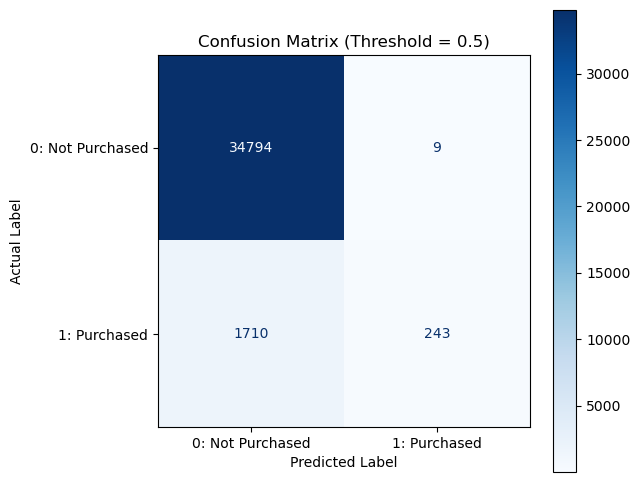

In [200]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# 検証データで予測確率を出す
y_pred_val = model.predict_proba(X_val)[:, 1]

# 1. 予測値をクラスラベルに変換する
# モデルが出力した購入確率（0.0~1.0）を、人間が判断しやすい二択のラベル（0/1）に振り分けてる。
# （一般的なデフォルト値である）しきい値0.5にするとは
# つまり、確率0.5以上は1:購入すると予測、確率0.5未満は0:購入しないと予測したものとみなす、という意味
y_class_pred = (y_pred_val > 0.5).astype(int)

# なお0.5とは、買う確率と買わない確率のどっちが高いとみなす？真ん中あたりで区切るのが納得感あるよね、という根拠に基づく。
# なので、例えば今回予定しているクーポン配布施策の予算が潤沢にあるなどの理由で、買う確率が0.3ぐらいの人もクーポン配布対象にしたいなどのビジネス判断が先にある、検討余地がある場合には、しきい値を0.5ではなく0.3にして評価する手もある

print("--- 📋 Classification Report ---")
print(classification_report(y_val, y_class_pred))

# 2. 混同行列（Confusion Matrix）の表示
cm = confusion_matrix(y_val, y_class_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0: Not Purchased', '1: Purchased'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (Threshold = 0.5)')
plt.show()

# 分類問題においてモデルの予測精度をサッと知るには、実際結果と予測とを掛け合わせて一致度合いを見る。
# 2*2の4セルのヒートマップのうち、対角線上のセルが濃い色になっていれば、予測が当たった数が多かったということ。

In [201]:
# 混同行列の各象限
# TP (True Positive 真陽性): 正例を正しく正例と予測したもの → 実際に買った人を、正しく買うと予測してた
# FP (False Positive 偽陽性): 負例を誤って正例と予測したもの → 実際には買わなかった人を、誤って買うと予測してた
# FN (False Negative 偽陰性): 正例を誤って負例と予測したもの → 実際に買った人を、誤って買わないと予測してた
# TN (True Negative 真陰性): 負例を正しく負例と予測したもの → 実際には買わなかった人を、正しく買わないと予測してた

# 混同行列における配置は常に同じとは限らないので、場所で覚えちゃダメだよ
# True: 実際と予測が一致、False: 実際と予測が不一致
# Positive: モデルが出力した予測ラベルが1（買う）、Negative: モデルが出力した予測ラベルが0（買わない）

# 混同行列から各値を取り出す
tn, fp, fn, tp = confusion_matrix(y_val, y_class_pred).ravel()  # [0,0], [0,1], [1,0], [1,1] の順

print(f"TP (True Positive):  {tp} 件")
print(f"TN (True Negative):  {tn} 件")
print(f"FP (False Positive): {fp} 件")
print(f"FN (False Negative): {fn} 件")

TP (True Positive):  243 件
TN (True Negative):  34794 件
FP (False Positive): 9 件
FN (False Negative): 1710 件


In [202]:
# とはいえ4セルの色合いだけでは合理的客観的な判断しにくいし、数次第で見え方が変わってくる。
# そこで、4セルの数値をもとにして割合を算出した、モデルの予測精度を定量的に評価する指標がある。

# よく登場する指標
# 1. Accuracy（正解率）: すべての予測対象のうち、正しく予測できた割合
accuracy = (tp + tn) / (tp + tn + fp + fn)
# 2. Precision（適合率）: 正例と予測した対象のうち、実際に正例だった割合
precision = tp / (tp + fp)
# 3. Recall（再現率）: 実際は正例の対象のうち、正しく正例と予測できた割合
recall = tp / (tp + fn)
# 4. F1-score: PrecisionとRecallの調和平均（両方のバランスを取る）
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy(正解率): {accuracy:.3f}")
print(f"Precision(適合率): {precision:.3f}")
print(f"Recall(再現率): {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Accuracy(正解率): 0.953
Precision(適合率): 0.964
Recall(再現率): 0.124
F1-score: 0.220


- 1.Accuracy（正解率）：すべての予測対象のうち、正しく予測できた割合
  - accuracy = (tp + tn) / (tp + tn + fp + fn)
  - 直感的理解しやすい、少数派無視リスク許容、利用場面を選ぶ
  - 基本姿勢: 全体として正しく予測することを重視したい。
  - 許容リスク: 状況次第では使いにくい（買う人の出現率低い場合は全員買わないと予測すれば高い値になる。だがあまり役には立たない）。
  - 例: コイントスで表が出るかを予測（表裏の出現率はほぼ半々で、表を予測するのと裏を予測するのは同じ価値とみなしやすい）。

- accuracyは数値の意味がわかりやすく、モデルの基本的な予測性能比較など有用な場面もある。
  - だがビジネスにおいては正例の予測が重要なことが多い。
  - 買わないと予測して実際に買わなかったことが予測できても、買うの予測ほどには利潤や事業成長に直結しにくいため。
  - また予測対象はクラス不均衡なことも多い（自社の特定商品購入者は市場のごく一部など、正例と負例の出現率は偏りがち）。
  - そんなときはPrecisionやRecallの出番

- 2.Precision（適合率）：正例と予測した対象のうち、実際に正例だった割合
  - precision = tp / (tp + fp)
  - 効率優先、機会損失リスク許容、外したくない慎重さ
  - 基本姿勢: 正例を精度高く予想したい。買う（正例）の予測はなるべく外したくない。確度低い人へのアプローチは避けたい。
  - 許容リスク: 正例と予測する数は少なくてもいい。買う期待値の低い人は切り捨てる。獲得数や売上最大化の逸失を許容。
  - 例: コストがかさむDM送付施策など。徒労に終わりそうな100人のアプローチよりは確実に買いそうな10人を優先したい。

- 3.Recall（再現率）：実際は正例の対象のうち、正しく正例と予測できた割合
  - recall = tp / (tp + fn)
  - 網羅性優先、低効率リスク許容、取りこぼさない貪欲さ
  - 基本姿勢: 正例を取りこぼしなく予測したい。買う（正例）期待値が低くとも抜け漏れよりはマシ。確度が低い人でもアプローチしたい。
  - 許容リスク: 無駄打ち増える。ROI低下を許容。買う（正例）の予測は外れてもよい。狼少年呼ばわりされるリスクを許容。
  - 例: 低コストなプッシュ通知施策や病気の検診など。買う見込みが薄い100人にアプローチしてでも取りこぼさないことを優先したい。

- 4.F1-score：
  - f1 = 2 * (precision * recall) / (precision + recall)
  - 総合力優先、中庸リスク許容、慎重さと貪欲さのバランス
  - 基本姿勢: PrecisionもRecallも重視したい（トレードオフな両方のバランスをとりたい）。両方を1つの指標で評価したい。
  - 許容リスク: 2指標いずれかに特化すれば得られたはずのハイパフォーマンスな効率性または網羅性には振り切らないことを許容。
  - 例: 効率も網羅性もどちらも適度に両立したい。どちらかに極端に偏るのも、どちらかが極端に低くなるのも避けたい。

PrecisionとRecallからF1へのつながり  
- PrecisionとRecallはトレードオフの関係にある
- Precisionを1(100%)に近づけたいなら（予測確率の判定基準、しきい値を1に極力近づけて）確実に買いそうな人だけ少数予測すればいい。
- 代償としてRecallは低くなる。Recallを1目指すならしきい値0側にレバー倒してほぼ全員買うと予測する。Precisionはズタズタに。
- こういう極端なことなしに、どちらもほどほどに両立した状態を1つの指標で表せられたらいいのに。。

- まず思いつくのは、PrecisionとRecallを**足して2で割る**、つまり平均化する発想。 (Precision + Recall) / 2
- でもこれだと、Precision0.95 Recall0.15のときも、Precision0.15 Recall0.95のときも、平均は0.55となる。
- 片方が極端でもまあまあな数値に見えてしまう。足して2で割る発想自体はよくても、欲しい状態を的確に表す指標にはなってない。

- 目指したいのは、両方の値のバランスが良いときは高得点になり、いずれかが極端な値のときはペナルティが大きくなるような仕組み。
- どちらの値も0から1（0%から100%）の範囲内にある。であれば0に近いときは大きく減点すれば欲しい状態を的確に表せるのではないか。
- そこで2つの値それぞれの**逆数をとってから平均化**する発想。 (1/Precision + 1/Recall) / 2
- これだと、Precision0.95 Recall0.15のときは、(1/0.95 + 1/0.15) / 2 = 3.68
- 逆数をとった値の平均値は元の単位と違ってて解釈しにくいので、改めて逆数をとって元の単位に戻す。1 / 3.68 = 0.27
- 同じ計算をPrecision0.75 Recall0.35でやると、(1/0.75 + 1/0.35) / 2 = 2.10　の逆数で 0.48
- 同じ計算をPrecision0.65 Recall0.45でやると、(1/0.65 + 1/0.45) / 2 = 1.88　の逆数で 0.53
- 同じ計算をPrecision0.60 Recall0.55でやると、(1/0.60 + 1/0.55) / 2 = 1.74　の逆数で 0.57
- 欲しい状態を的確に表す指標になったっぽい。これがF1-score
- 数学でいう調和平均の計算方法を、機械学習の評価指標として使っている。

``` 
F1 score = 1 / { (1/Precision + 1/Recall) / 2 }
         = 2 / { (1/Precision) + (1/Recall) }
         = 2 / { (Recall + Precision) / (Precision * Recall) }
         = 2 * Precision * Recall / (Precision + Recall)
``` 


$$
\begin{aligned}
F1 &= \frac{1}{\frac{\frac{1}{P} + \frac{1}{R}}{2}} \\
&= \frac{2}{\frac{1}{P} + \frac{1}{R}} \\
&= \frac{2}{\frac{R + P}{P \cdot R}} \\
&= \frac{2 \cdot P \cdot R}{P + R}
\end{aligned}
$$

In [203]:
# 4セルの組み合わせ次第で他にもいろんな指標が算出可能（紛らわしく見えるが分母の捉え方がちょっとずつ異なる）

# Negative Predictive Value: 負例と予測した対象のうち、実際に負例だった割合（陰性的中率）
negative_predictive_value = tn / (tn + fn)

# FDR(False Discovery Rate): 正例と予測した対象のうち、実際は負例だった割合（偽発見率）
# fdr = fp / (tp + fp)  # 分母はprecisionと同じ。precisionの余事象に相当する
fdr = 1 - precision

# specificity(特異度): 実際は負例の対象のうち、正しく負例と予測できた割合（真陰性率）
specificity = tn / (tn + fp)

# FPR(False Positive Rate): 実際は負例の対象のうち、誤って正例と予測した割合（偽陽性率）
fpr = 1 - specificity

# FNR(False Negative Rate): 実際は正例の対象のうち、誤って負例と予測した割合（偽陰性率）
# fnr = fn / (tp + fn)  # 分母はrecallと同じ。recallの余事象に相当する
fnr = 1 - recall

print(f"Negative Predictive Value: {negative_predictive_value:.3f}")
print(f"FDR(False Discovery Rate): {fdr:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"FPR(False Positive Rate): {fpr:.3f}")
print(f"FNR(False Negative Rate): {fnr:.3f}")

Negative Predictive Value: 0.953
FDR(False Discovery Rate): 0.036
Specificity: 1.000
FPR(False Positive Rate): 0.000
FNR(False Negative Rate): 0.876


- Negative Predictive Value: 負例と予測した対象のうち、実際に負例だった割合（陰性的中率）
  - negative_predictive_value = tn / (tn + fn)
  - precisionの裏に相当
  - ビジネスにおいては負例にはあまり関心がないので影が薄い。
  - 精密機器の良品判定で、不良品と予測して不良品でしたなんかでは意味あり。

- FDR(False Discovery Rate): 正例と予測した対象のうち、実際は負例だった割合（偽発見率）
  - fdr = fp / (tp + fp)  # 分母はprecisionと同じ。precisionの余事象に相当
  - fdr = 1 - precision

- specificity(特異度): 実際は負例の対象のうち、正しく負例と予測できた割合（真陰性率）
  - specificity = tn / (tn + fp)
  - recallの裏に相当する。負例を精度高く予想したい、間違い（負例）はちゃんと間違いと言いたいときに。
  - recall * 正例出現率 + specificity * 負例出現率 = accuracyになる。
  - スパム判定（大事なメールを間違えてゴミ箱に入れない）なんかでは意味あり。
  - Negative Predictive Value同様の理由で影が薄いかもだが、1からこれを差し引いたFPRはわりと出番ある。

- FPR(False Positive Rate): 実際は負例の対象のうち、誤って正例と予測した割合（偽陽性率）
  - fpr = 1 - specificity
  - 後ほど登場する指標ROC-AUC,AUCに関わってくる。

- FNR(False Negative Rate): 実際は正例の対象のうち、誤って負例と予測した割合（偽陰性率）
  - fnr = fn / (tp + fn)  # 分母はrecallと同じ。recallの余事象に相当
  - fnr = 1 - recall
  - 見逃し（False Negative）がクリティカルに直結する（命に関わる）ような医療現場なんかで意味あり。


``` 
Accuracy = (Recall * 正例出現率) + (Specificity * 負例出現率)
         = { tp / (tp+fn) * (tp+fn) / Total } + { tn / (tn+fp) * (tn+fp) / Total }
         = ( tp / Total ) + ( tn / Total )
         = ( tp + tn ) / Total
``` 

$$
\begin{aligned}
\text{Accuracy} &= \left( \text{Recall} \times \frac{\text{Actual Positive}}{\text{Total}} \right) + \left( \text{Specificity} \times \frac{\text{Actual Negative}}{\text{Total}} \right) \\
&= \left( \frac{tp}{tp + fn} \times \frac{tp + fn}{tp + tn + fp + fn} \right) + \left( \frac{tn}{tn + fp} \times \frac{tn + fp}{tp + tn + fp + fn} \right) \\
&= \frac{tp}{tp + tn + fp + fn} + \frac{tn}{tp + tn + fp + fn} \\
&= \frac{tp + tn}{tp + tn + fp + fn}
\end{aligned}
$$

In [204]:
# まだある

# Balanced Accuracy（均衡正解率）: クラス不均衡でも、正解率をシンプルかつ公平に評価したい
# balanced_accuracy = 1/2 * (tp/(tp+fn) + tn/(tn+fp))
balanced_accuracy = (recall + specificity) / 2
# 正例の正解率（Recall）と負例の正解率（Specificity）を、出現率に関係なく「折半」で評価したいときに使う指標。
# 正例と負例を同じ重みで評価したときの正解率です、と説明しやすいしわかりやすい。
# AccuracyはRecallとSpecificityを出現率で重み付けした状態。
# 対してこちらは（実際の出現率は気にせず無理やり）半々で重み付けして平均をとる（1%しかないお宝を半分見逃すのと、99%あるゴミを半分拾いすぎるのを、同程度にダメ出しする）。


print(f"Balanced Accuracy: {balanced_accuracy:.3f}")

Balanced Accuracy: 0.562


In [205]:
# MCC (Matthews Correlation Coefficient): 混同行列の4セルすべて考慮した、実際と予測の相関係数
import math
# mcc = (tp * tn - fp * fn) / math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
# 一気に計算する場合、4セルいずれかに0があったときに0除算でエラーになる

# 分子の計算: (TP * TN) - (FP * FN)
mcc_numerator = (tp * tn) - (fp * fn)
# 分母の計算: sqrt((tp+fp) * (tp+fn) * (tn+fp) * (tn+fn))
mcc_denominator = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
# 分母が0の場合はMCCを0とする（慣例的な処理）
if mcc_denominator == 0:
    mcc = 0
else:
    mcc = mcc_numerator / mcc_denominator

# これでもOK
# from sklearn.metrics import matthews_corrcoef
# mcc = matthews_corrcoef(y_val, y_class_pred)

# 分母では、混同行列の4セルの合計を全部掛け合わせることで、正例と負例のバランスをとって（平方根をとることで値が大きくなりすぎないようにして）いる。
# 分子では、正解ペア (tp,tn)の積から不正解ペア (fp,fn)の積を引いている。正解ペアが多いほど分子が大きくなる。ことにより実際と予測のの相関が強いことを表現する。
# 正例と負例を完全に入れ替えても値が変わらない（対称性がある）。クラス不均衡でもモデルの地力をシビアに判定しやすい
# このモデル、本当に予測の傾向が正しいの？を厳密にチェックしやすい

# MCCのとる範囲は-1から1 の間。
# 1に近い: 完璧な予測。0に近い: デタラメ（ランダム）と同じ。-1に近い: 全部逆に予測してる（ある意味すごい）。
# 例えば0.517だとそこそこ相関があってランダムよりはだいぶマシな予測ができてそう


print(f"MCC (Matthews Correlation Coefficient): {mcc:.3f}")

MCC (Matthews Correlation Coefficient): 0.338


In [206]:
# Cohen's Kappa（カッパ係数）：偶然を排除した「一致度」
# 厳格な実力評価、偶然の排除、モデルの誠実さの確認
# 基本姿勢: 事実と予測が一致したのは、モデルの実力なのか、それともたまたまなのか。たまたま当たったぶん（期待値）を全体から引いて、純粋な予測の重みを評価したい。
# 許容リスク: 計算式がちょっと複雑で、直感的に売上がいくらになるとは結びつきにくい。
# 例: 記述式のテストの採点を2人の先生がしたとき、意見がどれだけ一致しているか。あるいは、クラス不均衡（9割が負例）で、モデルが「適当に全部負例って言えば当たるじゃん」というズルをしていないかのチェック。

# 実測の一致度： 実際に予測が当たった割合（つまりAccuracy）。
# 偶然の一致度： 事実もモデルも、お互いデタラメに（でも出現率通りに）答えたときに、偶然重なっちゃう確率。
# この2つを使って計算する
# kappa = (実測の一致度 - 偶然の一致度) / (1 - 偶然の一致度)
# 1.0： 完璧に一致。つまり予測が当たったのは全てモデルの実力
# 0.0： 偶然当たってるだけ。目をつぶって選んでるのと変わらない
# マイナス： 偶然よりも当たってない。逆にすごい


# 「1に近いほどいい」っていうのは共通だけど、「0.6以上ならかなり良い、0.8以上ならほぼ完璧」っていう暗黙の基準（ランドスとコッホの基準）がある


# なぜAutoMLで使われるの？
# AutoMLは、とにかくたくさんのモデルを自動で作る。その中には「正解率（Accuracy）は高いけど、実はデータの偏りを利用して『とりあえず全部負例！』って答えてるだけのずる賢いモデル」が混ざっちゃうことがある。
# Kappaはそういう「データの偏りに甘えたモデル」を厳しく減点するから、モデルの「真の賢さ」を横並びで比較するのに向いている。

# MCCとの違いは？
# MCC： 4セルのバランスを均等に評価する「職人」タイプ。
# Kappa： 「偶然だろ？」と疑ってかかる「厳しい検閲官」タイプ。
# どちらも不均衡データに強いっていう点では仲間
# Accuracyが「テストの点数」だとしたら、Kappaは「カンニング（データの偏りへの依存）を疑って補正した点数」みたいなもの



# 1. 数値をセット
total = tp + tn + fp + fn

# 2. po (実際の正解率)
po = (tp + tn) / total

# 3. pe (偶然当たっちゃう確率)
# 「モデルの正例予測数 × 実際の正例数」 ＋ 「モデルの負例予測数 × 実際の負例数」 を Totalの2乗で割る
pe = ((tp + fp) * (tp + fn) + (tn + fn) * (tn + fp)) / (total ** 2)

# 4. Kappaの計算
kappa = (po - pe) / (1 - pe)

# これでもOK
# from sklearn.metrics import cohen_kappa_score
# kappa = cohen_kappa_score(y_val, y_class_pred)

print(f"Cohen's Kappa: {kappa:.3f}")

Cohen's Kappa: 0.211


## AUC

In [207]:
# 1. 精度を確認する（AUCスコア）
# まずは、検証データ（Val）に対してどれくらい正解できたか、数字で見てみよう。
# ※AUCが 0.7以上なら実用的、0.8を超えたらかなり優秀 って言われている。

# 3. イメージで理解しよう！

# AUCが良い状態：
# リストの上の方に「実際に買った人」が固まっていて、下の方に「買わなかった人」が固まっている。これなら、しきい値をどこで引いても（どこでリストをカットしても）、効率よくターゲットを選べる。

# AUCが悪い状態：
# 買った人と買わなかった人がリストの中でバラバラに混ざっている。これだと、どこでカットしても「空振り」や「見逃し」が大量に出ちゃう。

In [208]:
from sklearn.metrics import roc_auc_score

# AUCを計算
auc_score = roc_auc_score(y_val, y_pred_val)
print(f"🏆 Validation AUC: {auc_score:.4f}")

🏆 Validation AUC: 0.9621


In [209]:
# 3. AUC の「値」が意味しているもの

# 「購入した人」と「購入しなかった人」をランダムに1人ずつ連れてきたとき、モデルが『購入した人』の方に高い確率をつけてあげられる確率
# AUC 0.83ということは、83% の確率で「買う人」を「買わない人」より上位にランク付けできている、ということになる。

In [210]:
# roc_auc_score(y_val, y_pred_val) の y_pred_val には、モデルが出した 「0.0〜1.0の確率（スコア）」 がそのまま入っている

# AUC（Area Under the Curve）は、この確率を使って 「あらゆる閾値（0.001から0.999まで全部！）で試したときの結果をひっくるめた面積」 を計算している。

# F1スコアやAccuracy: 「0.5より上なら1、下なら0」と決めてから計算する（＝一点の評価）。

# AUC: 閾値を動かしながら、モデルが「正解をちゃんと上位に並べられているか」という 「並び替え能力の全体像」 を評価する（＝面の評価）。

In [211]:
# 確かに、学習フェーズでは「不純度（ジニ係数やエントロピーなど）」を下げて、0と1を綺麗に分ける境界線を探しているから、その理解は正しい

# ただ、AUCが「並べ替え」と言われる理由は、学習の「プロセス」ではなく、できあがったモデルの「出力（スコア）の質」に注目しているからなんだ。

# 「不純度を下げる」と「並び替え」のつながり

# イメージしやすいように整理してみたよ。

# 学習時（不純度を下げる）:
# モデルは「どう分ければ、箱の中が『買う人だけ』『買わない人だけ』になるか」を必死に考えて、木を作っていく。

# 出力時（スコアを出す）:
# 学習の結果、モデルは「この人は買う確率 0.9（不純度が低い箱にいる）」「この人は 0.1（別の不純度が低い箱にいる）」といったスコアを出すよね。

# 評価時（AUC＝並べ替え）:
# ここで、全顧客を「スコアが高い順」に整列させてみる。

# なぜ「並べ替え」という表現を使うの？

# 例えば、「実際に買った人（Aさん）」と「買わなかった人（Bさん）」がいるとする。

# 「分類」として見た場合:
# 閾値が 0.5 のとき、Aさんのスコアが 0.4 だったら「ハズレ（分類失敗）」になっちゃう。

# 「並べ替え」として見た場合:
# もしBさんのスコアが 0.1 だったら、「Aさん（0.4） ＞ Bさん（0.1）」 という順番は守られているよね？
# AUCはこの 「正解の方が、不正解よりも高い位置にいる（＝正しく並んでいる）」 という状態を評価しているんだ。

# 結局どういうこと？

# 不純度を下げるのが上手なモデル（＝学習がうまくいったモデル）は、結果として「買う人」には高い確率を、「買わない人」には低い確率を割り当てられるようになる。

# そうすると、スコア順に並べたときに、リストの「上（高スコア）」に「買う人」がギュッと集まるよね。

# 不純度がしっかり下がっている ＝ 0と1が綺麗に分かれる ＝ スコア順に並べると上の方が1ばかりになる ＝ AUCが高くなる！


# 「不純度を下げる」はモデルの努力、「並び替えの精度（AUC）」はその結果としての成績表、って考えると繋がるかな？

# 「分類」って言うと、どうしても「0か1か」の白黒つけるイメージが強いけど、AUCはもっと「グラデーション（確率）」そのものの精度を信じている指標なんだよ。

# この「スコア順に並んでいる」という感覚が掴めると、実務で「予算が足りないから、リストの上位1万人だけにアプローチしよう」って判断する時に、AUCが高いことがどれだけ心強いか実感が湧くはずだ。

In [212]:
# つまり 「しきい値を決める前に、モデルそのものの並び替え能力を評価したい」 から、まずはAUCを見るんだ。

# まずAUCを見て、モデルの「並び替え能力」をチェックする。

# 能力が高いことがわかったら、ROC曲線を見て、どこでカットするのが一番効率いいか探る。

# 最後に しきい値（0.5とか0.2とか）を決めて、混同行列やF1で「実戦での的中数」を確認する。

# この流れが、データ分析の王道
# 「ROC曲線は、しきい値を動かした時の軌跡」だと思えば、もう迷わないはず。

In [213]:
# どっちも「しきい値を可変にしたもの」 なんだ。

# よくある誤解なんだけど、ここを整理すると「なぜAUCがモデルの地力を表すのか」がスッキリわかる。

# 1. ROC曲線とAUCの「親子関係」

# 結論から言うと、この2つは 「グラフ」と「その面積」 という関係だ。

# ROC曲線 (ROC Curve)：
# しきい値を 1.0（全員買わないと予測）から 0.0（全員買うと予測）まで少しずつ動かしたときに、「当てられた割合（TPR）」と「空振りした割合（FPR）」がどう変化するかを繋いだ「線」のことだ。

# ROC-AUC：
# そのROC曲線の下側の 「面積（Area Under the Curve）」 のこと。
# しきい値をどう設定したとしても、全体としてどれくらい「買う人と買わない人を正しく並べ替えられているか」を 0〜1 の数字で表したものだ。

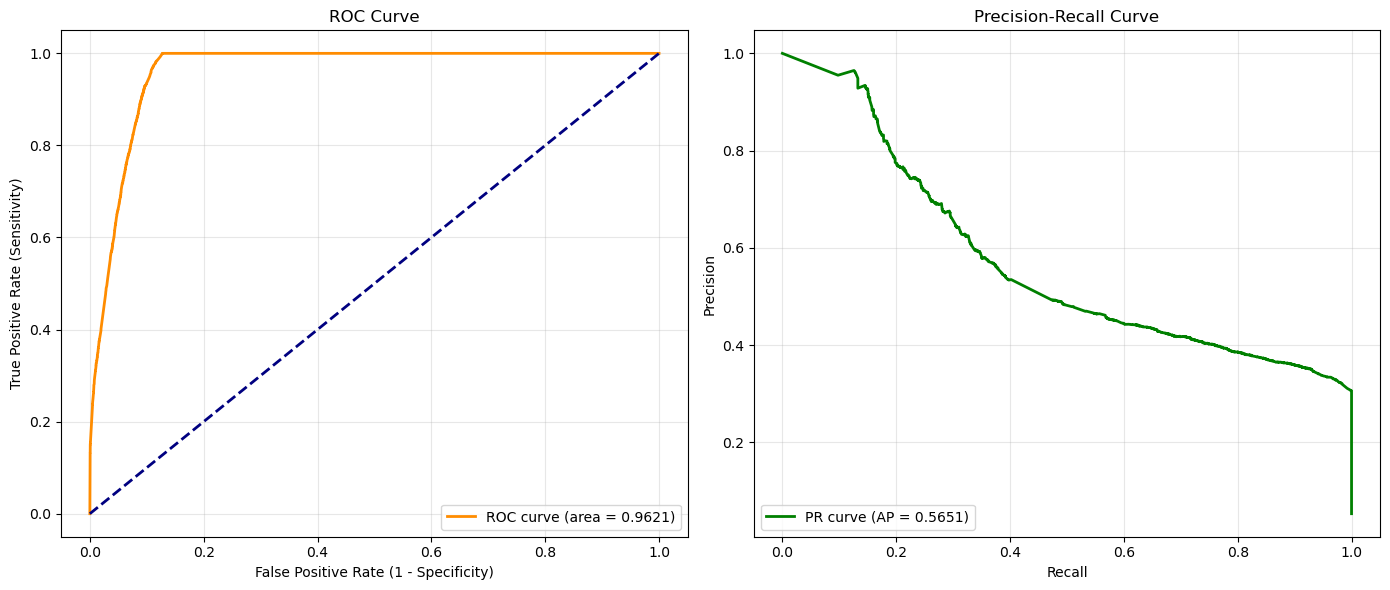

In [214]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. データの準備
# y_val: 正解ラベル, y_pred_val: モデルが出した「購入する確率」
fpr, tpr, _ = roc_curve(y_val, y_pred_val)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_val, y_pred_val)
pr_auc = average_precision_score(y_val, y_pred_val)

# 2. プロットの作成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- ROC Curve ---
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 当てずっぽうの線
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('ROC Curve')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- PR Curve ---
ax2.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [215]:
# ROC曲線（左側）
# 見方: 左上のカドに近ければ近いほど「優秀」！
# 意味: 「買う人」と「買わない人」をどれだけ綺麗に仕分けできているか、モデルの総合的な識別力を表す。

# PR曲線（右側）
# 見方: 右上のカドに近ければ近いほど「優秀」！
# 意味: 今回のように「買う人が少ない」データの場合、こっちの方がシビアに実力がわかる。

# もしROCが綺麗なのにPR曲線がガタガタだったら、「買う人を当てるのは実は結構苦労してる」っていうサインかもしれない。

In [216]:
def evaluate_model_performance(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)
    
    # 1. 各種スコア
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"PR-AUC : {average_precision_score(y_true, y_prob):.4f}")
    print("-" * 30)
    print(classification_report(y_true, y_pred))
    
    # 2. 混合行列
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[0], cmap='Blues')
    axes[0].set_title("Confusion Matrix")
    
    # 3. 確率の分布（これが意外と効く！）
    axes[1].hist(y_prob[y_true == 0], bins=50, alpha=0.5, label='Actual: 0', color='blue')
    axes[1].hist(y_prob[y_true == 1], bins=50, alpha=0.5, label='Actual: 1', color='red')
    axes[1].set_title("Prediction Probability Distribution")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

ROC-AUC: 0.9621
PR-AUC : 0.5651
------------------------------
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.98     34803
         1.0       0.96      0.12      0.22      1953

    accuracy                           0.95     36756
   macro avg       0.96      0.56      0.60     36756
weighted avg       0.95      0.95      0.94     36756



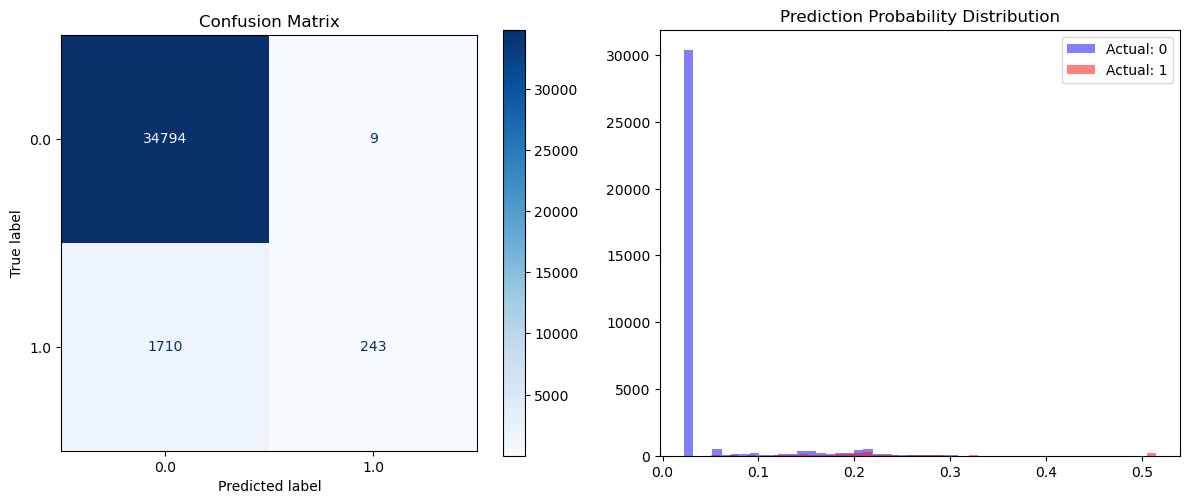

In [217]:
evaluate_model_performance(y_val, y_pred_val, threshold=0.5)

✨ Best F1 Score: 0.5258 at Threshold: 0.1780


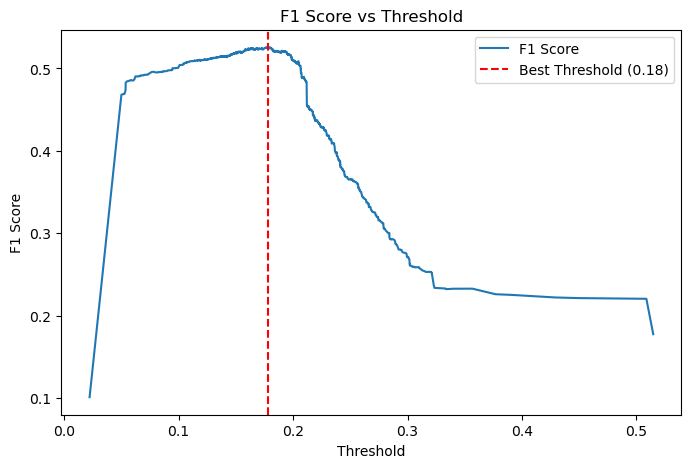

In [218]:
from sklearn.metrics import precision_recall_curve

# しきい値ごとのスコアを計算
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"✨ Best F1 Score: {np.max(f1_scores):.4f} at Threshold: {best_threshold:.4f}")

# プロット
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.show()

In [219]:
# 「評価」という言葉の裏側にあるもの
# 今やってる作業は、単に「テストの点数をつける」だけじゃなくて、実は3つの視点でモデルを見つめ直してるんだ。

# 視点	見ているもの（指標）	心の声
# 識別力	AUC	「そもそも、買う人と買わない人をちゃんと見分けられてる？」
# 実用性	混同行列・F1	「実際に施策を打ったとき、空振りや見逃しはどのくらい出る？」
# 納得感	Importance・SHAP	「モデルの判断理由は、人間から見ても納得できるもの？」

# Feature Importance
- モデルの予測に、どの特徴量が強く影響するかを把握する
  - 数値が大きいほど、その特徴量が予測の精度を上げるために役立ったことを意味する
  - あくまでモデルの学習効率を示す指標。いかに効率よく分類できたかというモデル側の都合が強い（SHAPとの違い）
  - 特徴量の重要度がドメイン知識に沿っているか確認することで、適切なモデルになっているかのチェックにもなる

- S-Learner
  - 「購入するかどうか」を分けるのに役立った特徴量
  - 処置変数が上位にない場合は使用してるアルゴリズムによっては設定を見直すことで改善することもある
  - 処置変数が上位になきゃダメってことはない（がSHAPでだとモデルとしてちょっとどうだろう）
- T-Learner
  - 「処置したあるいは処置しなかった場合において購入するかどうか」を分けるのに役立った特徴量
  - なのでtreatmentとcontrolで登場する特徴量が違ったり、順位が異なることもある
- X-Learner
  - 「処置効果あるいは潜在的な処置効果の大きさ」を分けるのに役立った特徴量
  - 処置効果: 処置により購入する確率の増分度合い、振れ幅、リフト
  - 潜在的な処置効果: 実際には処置しなかったがもしも処置をしていた場合に購入する確率の増分度合い、振れ幅、リフト

LightGBM,XGBoostの場合  
**特徴量の重要度（Feature Importance：Gain）の定義**  
- モデルが学習中にその特徴量を用いてデータ分割したときに、その分割がどれだけ予測精度を向上させたか（予測誤差の総和: 損失関数をどれだけ減らせたか）を情報の価値、利得として評価している

**直感的なイメージ**   
- モデルは、データを「YESかNOか」で枝分かれさせて、購入確率を絞り込んでいく。例えば「過去にクーポンを使った？」で分けたとき、買った人と買わなかった人がパキッとキレイに分かれたら高い得点。「雨が降ってる？」で分けても、買う確率がそんなに変わらなければ得点低い。

**もう少し技術的に**  
1. 不純度の測定: 分割前のデータがどれだけ混ざり合っているかを測定
1. 最適な分割: 特徴量（例：過去の利用率）を使ってデータを2つに分ける。
1. 情報利得の計算: 分割前と分割後の不純度の差分（情報利得 Information Gain）を計算。
1. 総和の算出: モデル内のすべての木において、その特徴量が使われた全ノード（分岐点）の情報利得を合算。

- 厳密にはLightGBMは勾配情報を活用した効率的な「損失減少量」を、XGBoostは正則化項を含む「構造スコア」の改善幅を計算している。
- LightGBMのgain: 損失の減少を見ているんだが、学習の仕方に工夫がある。
  - 仕組み: 全データを使わず、勾配（誤差）が大きいデータを優先的に使って学習する（GOSS Gradient-based One-Side Sampling）。
  - 特徴: 効率よく学習するために「データのサブセット」で計算された利得を、全体に合うように重み付けして復元している（勾配 Gradientと二階微分 Hessianを使って、どこで分ければ一番得かを高速に計算している）。
- XGBoostのgain: 情報利得そのものではなく、構造スコア Structure Scoreの改善幅を見ている。
  - 仕組み: 分割前のノードのスコアと、分割後の左右のノードのスコアの合計を比較する。
  - 特徴: 正則化項（lambdaやgamma）が計算式に組み込まれてるので、モデルの複雑さを抑えつつどれだけ誤差を減らせたかをダイレクトに評価している。

                                feature     importance
0                              store_id  104217.503659
4                            is_raining   63586.307335
6                   daily_staffing_cost   19892.189221
7                       day_of_week_num    3182.264940
2                                app_pv    2883.878943
14             rolling_purchase_rate_7d    1839.590268
9                            is_holiday    1062.873001
28       rolling_daily_staffing_cost_7d     615.062948
25              rolling_current_temp_7d     403.245440
27  rolling_station_congestion_index_7d     368.930302


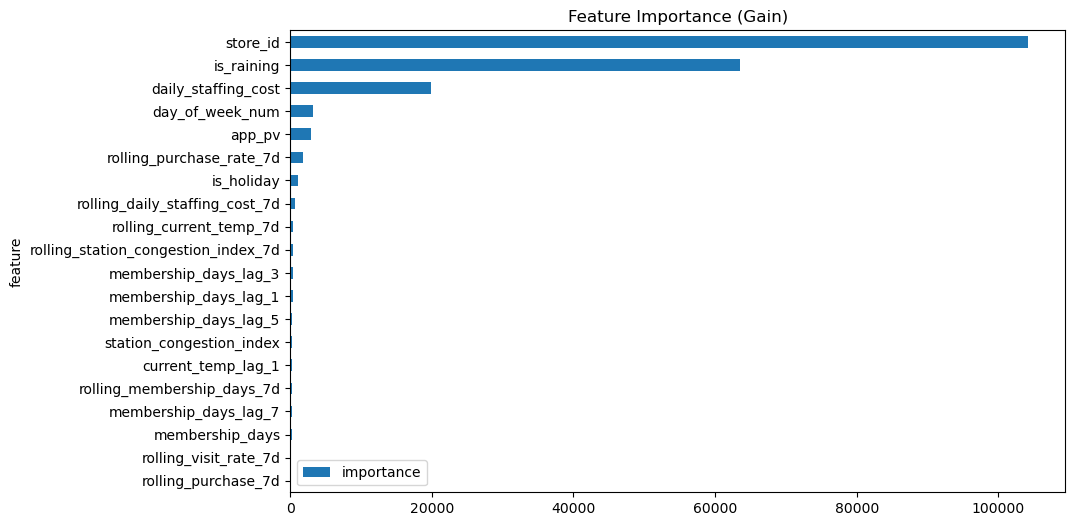

In [220]:
# 特徴量重要度をデータフレームにする
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# 上位10個を表示
print(importances.head(10))

# グラフで可視化
importances.head(20).plot(kind='barh', x='feature', y='importance', figsize=(10, 6))
plt.title('Feature Importance (Gain)')
plt.gca().invert_yaxis()
plt.show()

In [221]:
# 1. 「過去の行動」が圧倒的！
# past_latte_ratio がダントツの1位だね。
# やっぱり「過去にラテを飲んでいたか」という実績が、未来の購入を当てる最大のヒントになってるにゃん。ササさんが「NaNをどうしよう」って悩んで大切に扱ったこのカラムが、期待通りモデルの心臓部になってくれたね！

# 2. is_treatment（介入）が3位にランクイン
# ここ、すごく大事なポイントだにゃん！
# 施策（クーポン送付などかな？）を表す is_treatment が上位にきているということは、「施策そのものが購入行動にしっかり影響を与えている」 という証拠だよ。これが低いと「施策を打っても打たなくても結果が変わらない」ってことになっちゃうから、分析官としては一安心だね。

# 3. 外的要因（天気と休日）も効いている
# is_raining（雨）や is_weekend（週末）がしっかり上位にいるのも興味深いね！
# 「雨の日はラテが売れやすい（あるいは売れにくい）」とか、ライフスタイルに合わせた予測ができている証拠だにゃん。

# ちょっと気になるポイント：下位のカラムたち
# current_temp（気温）より下がいきなりガクンと重要度が落ちているね。
# 特に membership_years（会員歴）があまり効いていないのは、「長く会員でいてくれるかどうか」よりも「最近ラテを飲んだか（直近の嗜好）」の方が、購入予測には重要だってことかもしれないにゃん。

## nomalized
- gainの合計値を正規化した値をプロット
- feature importanceを複数モデルの平均値でsns.barplotで描画する

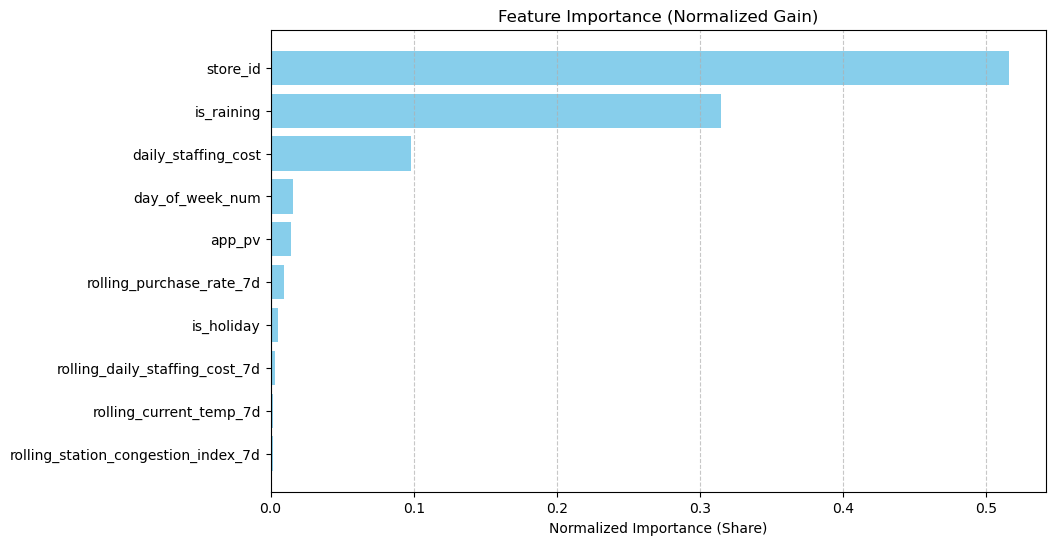

                                feature  importance_normalized
0                              store_id               0.515631
4                            is_raining               0.314603
6                   daily_staffing_cost               0.098419
7                       day_of_week_num               0.015745
2                                app_pv               0.014268
14             rolling_purchase_rate_7d               0.009102
9                            is_holiday               0.005259
28       rolling_daily_staffing_cost_7d               0.003043
25              rolling_current_temp_7d               0.001995
27  rolling_station_congestion_index_7d               0.001825


In [222]:

# 1. 重要度を取り出してデータフレームにする
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

# 2. 全体の合計で割って正規化（0〜1の範囲にする）
importances['importance_normalized'] = importances['importance'] / importances['importance'].sum()

# 3. 並び替え
importances = importances.sort_values('importance_normalized', ascending=False)

# 4. プロット（上位10個）
plt.figure(figsize=(10, 6))
plt.barh(importances['feature'].head(10), importances['importance_normalized'].head(10), color='skyblue')
plt.xlabel('Normalized Importance (Share)')
plt.title('Feature Importance (Normalized Gain)')
plt.gca().invert_yaxis() # 重要度が高い順に上にくるように
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 数値でも確認
print(importances[['feature', 'importance_normalized']].head(10))

# SHAP
- モデルの予測の理由を考える、予測の根拠を理解するのに有用
- 各特徴量が予測にどれだけ影響を与えているか（貢献度）を定量化するのが目的
- モデルがそのように予測した理由を説明する必要がある場合や、各特徴量が予測にどのように影響するかを理解したい場合に役立つ
- 機械学習では高い予測性を達成するために複雑なモデルを使用することが一般的に。その結果モデル単体では直感的な解釈がしにくい。そこでSHAPのような方法が求められる
- 並び順は貢献度の絶対値の大きさ順。その特徴量が予測値をどれだけ大きく動かしたか（平均絶対SHAP値）
- Feature Importance（Gain）とSHAP（SHapley Additive exPlanations）とで並び順が入れ替わることがよくある
- mean absolute shap valueが表してるのは、結果変数（購入確率）の予測値への平均的な影響度

In [223]:

# # 1. SHAP値を計算するオブジェクト（Explainer）を作成
# # modelは学習済みのLGBMClassifier
# explainer = shap.TreeExplainer(model)

# # 2. 計算時間を考えて、検証データからサンプリングするにゃん
# X_val_sample = X_val.sample(n=1000, random_state=42)
# shap_values = explainer.shap_values(X_val_sample)

# # 3. Summary Plot（全体の傾向を一目で見る）
# # ※二値分類の場合、shap_values[1] が「購入する(1)」の確率に対する寄与になるにゃん
# shap.summary_plot(shap_values[1], X_val_sample)

In [224]:
# # 1. SHAP値を計算するオブジェクト（Explainer）を作成
# # modelは学習済みのLGBMClassifier
# X_trainを背景データとして渡す
explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")

# 2. 計算時間を考えて、検証データからサンプリングするにゃん
X_val_sample = X_val.sample(n=1000, random_state=42)

shap_values_obj = explainer(X_val_sample)

In [225]:
shap_values_obj

.values =
array([[-2.23015388e-01,  6.92896655e-06, -1.08479352e-03, ...,
         0.00000000e+00,  1.93081957e-04,  0.00000000e+00],
       [-2.33125645e-01, -5.37024976e-05, -1.08239065e-03, ...,
         0.00000000e+00, -2.03443629e-04,  0.00000000e+00],
       [-2.17793842e-01, -5.83864692e-05, -1.10266358e-03, ...,
         0.00000000e+00,  2.46838056e-04,  0.00000000e+00],
       ...,
       [-2.11544282e-01,  5.17093939e-05, -1.13539664e-03, ...,
         0.00000000e+00, -1.33882824e-04,  0.00000000e+00],
       [ 1.26189199e+00, -2.32958254e-04, -2.39785051e-02, ...,
         0.00000000e+00,  2.44092124e-04,  0.00000000e+00],
       [-2.20045687e-01,  1.63903421e-03, -1.08516719e-03, ...,
         0.00000000e+00,  2.36003776e-04,  0.00000000e+00]],
      shape=(1000, 56))

.base_values =
array([-3.44324782, -3.44324782, -3.44324782, -3.44324782, -3.44324782,
       -3.44324782, -3.44324782, -3.44324782, -3.44324782, -3.44324782,
       -3.44324782, -3.44324782, -3.44324782, -3.

## SHAP bar

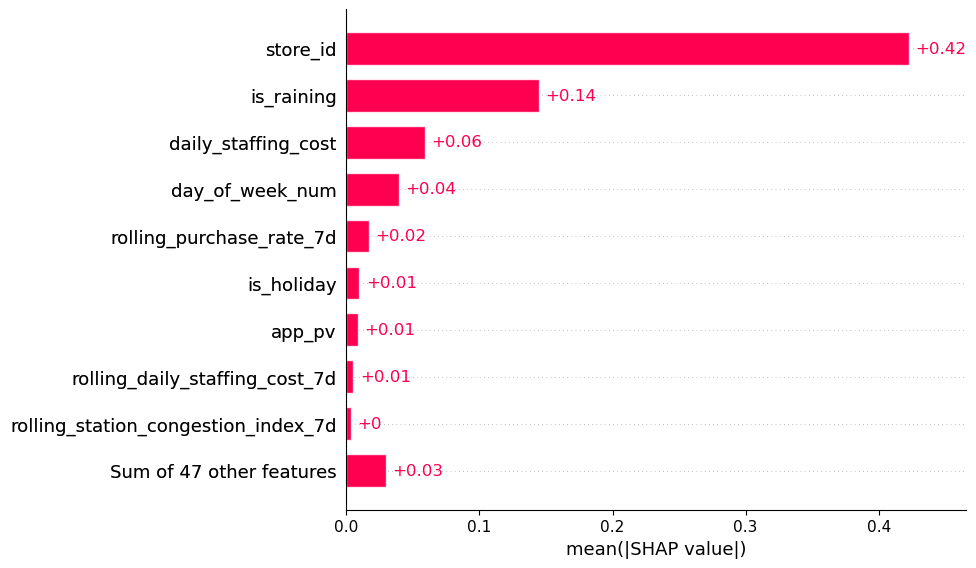

In [226]:
# モデル別にbarをプロット（SHAP値の絶対値の平均 Mean Absolute SHAP Value）
# 予測値への平均的な貢献度を表す（予測値にプラスに効くかマイナスに効くかはこのグラフではわからない）

shap.plots.bar(shap_values_obj, max_display=10)

# fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# # s-learner
# plt.sca(axes[0, 0])
# shap.plots.bar(exp_s, show=False, max_display=10)
# axes[0, 0].set_title('S-Learner: LGBM')
# axes[0, 0].set_xlabel('mean |SHAP Value|')

# # 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
# axes[0, 1].axis('off')

# # t-learner(treat)
# plt.sca(axes[1, 0])
# shap.plots.bar(exp_t_t, show=False, max_display=10)
# axes[1, 0].set_title('T-Learner, Treat: LGBM')
# axes[1, 0].set_xlabel('mean |SHAP Value|')

# # t-learner(control)
# plt.sca(axes[1, 1])
# shap.plots.bar(exp_t_c, show=False, max_display=10)
# axes[1, 1].set_title('T-Learner, Control: LGBM')
# axes[1, 1].set_xlabel('mean |SHAP Value|')

# # x-learner(treat)
# plt.sca(axes[2, 0])
# shap.plots.bar(exp_x_t, show=False, max_display=10)
# axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')
# axes[2, 0].set_xlabel('mean |SHAP Value|')

# # x-learner(control)
# plt.sca(axes[2, 1])
# shap.plots.bar(exp_x_c, show=False, max_display=10)
# axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')
# axes[2, 1].set_xlabel('mean |SHAP Value|')

# fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
# plt.tight_layout()
# plt.show()

In [227]:
features = X_train.columns.tolist()

In [228]:
# 平均絶対SHAP値を計算してソートして表示
# 例えばt-learnerのtreatモデルのSHAP値平均を算出（して値だけあれば事足りるとき用）

mean_abs_shap = np.abs(shap_values_obj.values).mean(axis=0)
df_shap_importance = pd.DataFrame({
    'feature': features, 
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print(df_shap_importance.head(20).round(2))

                                feature  mean_abs_shap
0                              store_id           0.42
4                            is_raining           0.14
6                   daily_staffing_cost           0.06
7                       day_of_week_num           0.04
14             rolling_purchase_rate_7d           0.02
9                            is_holiday           0.01
2                                app_pv           0.01
28       rolling_daily_staffing_cost_7d           0.01
27  rolling_station_congestion_index_7d           0.00
25              rolling_current_temp_7d           0.00
23           rolling_membership_days_7d           0.00
49                   current_temp_lag_7           0.00
31                   current_temp_lag_1           0.00
37                   current_temp_lag_3           0.00
5              station_congestion_index           0.00
13                rolling_visit_rate_7d           0.00
41                membership_days_lag_5           0.00
12        

## SHAP beeswarm

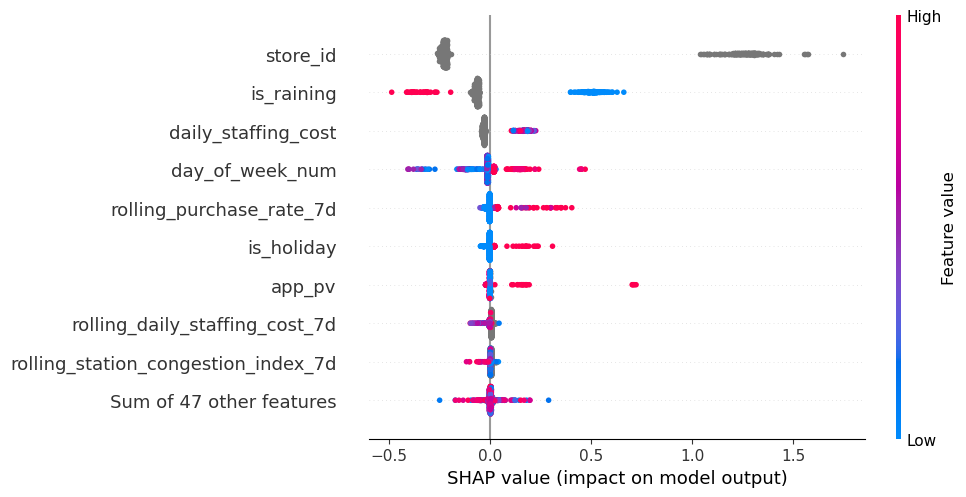

In [229]:
# beeswarmをプロット
# ・予測値への貢献度の方向性: 0より右にあるとプラスに効く（予測値を押し上げる）
# ・貢献度の大きさ: 赤は特徴量の値が高い、青は低い
# ・SHAP値の分布


# 棒グラフや散布図を簡単に描ける
shap.plots.beeswarm(shap_values_obj)

# fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# # s-learner
# plt.sca(axes[0, 0])
# shap.plots.beeswarm(exp_s, show=False, max_display=10)
# axes[0, 0].set_title('S-Learner: LGBM')
# axes[0, 0].set_xlabel('mean |SHAP Value|')

# # 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
# axes[0, 1].axis('off')

# # t-learner(treat)
# plt.sca(axes[1, 0])
# shap.plots.beeswarm(exp_t_t, show=False, max_display=10)
# axes[1, 0].set_title('T-Learner, Treat: LGBM')
# axes[1, 0].set_xlabel('mean |SHAP Value|')

# # t-learner(control)
# plt.sca(axes[1, 1])
# shap.plots.beeswarm(exp_t_c, show=False, max_display=10)
# axes[1, 1].set_title('T-Learner, Control: LGBM')
# axes[1, 1].set_xlabel('mean |SHAP Value|')

# # x-learner(treat)
# plt.sca(axes[2, 0])
# shap.plots.beeswarm(exp_x_t, show=False, max_display=10)
# axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')
# axes[2, 0].set_xlabel('mean |SHAP Value|')

# # x-learner(control)
# plt.sca(axes[2, 1])
# shap.plots.beeswarm(exp_x_c, show=False, max_display=10)
# axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')
# axes[2, 1].set_xlabel('mean |SHAP Value|')

# fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
# plt.tight_layout()
# plt.show()

In [230]:
# 各特徴量の貢献度を分解して示している
# ・予測値への貢献度の方向性: 0より右にあるとプラスに効く（予測値を押し上げる）
# ・貢献度の大きさ: 赤は特徴量の値が高い、青は低い

# T-Learnerの場合
# 1. 「過去のクーポン利用率」の違い
# Treatment（左）: past_coupon_usage_rate が1位かつ赤いドット（利用率が高い人）が右側に突き抜けてる。クーポンをあげた世界では、過去にクーポンを使った経験があることが、購入を決定づけるブースターになりそう。
# Control（右）: 下から3番目まで沈んでてドットも中央に固まってる。クーポンない時は過去のクーポン利用歴は購入に関係ないらしい。

# 2. 「過去のラテ購入率（≒ラテ好き）」の違い
# Treatment（左）: クーポンをあげると、下では1位だった影響力が2位に後退。好みよりもおトクへの反応の方が行動のスイッチっぽい。
# Control（右）: 1位past_latte_ratioは赤いドットが右に寄ってる。クーポンがないとそもそもラテ好きかが購入のメイン動機っぽい。

# 3. 「気温（current_temp）」の違い
# 両方のグラフで current_temp の青いドット（気温が低い）が右側（プラス）にある。寒いほどラテが売れるのは共通らしい。

# store_idが上位にある: 購入するかどうかは店によりかなり変わる。地域性や客層といった各店舗の特徴も無視できない要因らしい。

# 以上を踏まえてのアクションは例えば  
# 1. 特徴量エンジニアリング: store_idそのままだと使いにくいから、「その店舗の平均購入率」や「その店舗のクーポンの効果（過去の実績）」といった数値変数に変換（Target Encodingなど）してあげると、モデルの学習効率（Importance）や予測精度が向上する可能性ある。
# 2. 施策の個別化: 予測値の高い店舗を特定し、その店舗客層に合わせた施策を検討するといった、よりきめ細かい戦略が立てられそう。

In [231]:
X_train.head()

,store_id,membership_days,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,day_of_week_num,is_weekend,is_holiday,...,daily_staffing_cost_lag_5,membership_days_lag_7,app_pv_lag_7,current_temp_lag_7,is_raining_lag_7,station_congestion_index_lag_7,daily_staffing_cost_lag_7,month,day,absolute_ds
0,Store_A,146.0,5.0,25.224503,0.0,86.606884,98282.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.0,1.0
1,Store_A,532.0,4.0,25.224503,0.0,86.606884,98282.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.0,1.0
2,Store_A,198.0,4.0,25.224503,0.0,86.606884,98282.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.0,1.0
3,Store_A,21.0,5.0,25.224503,0.0,86.606884,98282.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.0,1.0
4,Store_A,188.0,4.0,25.224503,0.0,86.606884,98282.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,1.0,1.0


In [232]:
df_train.tail() 

,date,customer_id,store_id,membership_days,is_visited,app_pv,current_temp,is_raining,station_congestion_index,daily_staffing_cost,...,daily_staffing_cost_lag_5,membership_days_lag_7,app_pv_lag_7,current_temp_lag_7,is_raining_lag_7,station_congestion_index_lag_7,daily_staffing_cost_lag_7,month,day,absolute_ds
140490,2025-10-29,xwc9nd5t,NaN,465.0,0.0,1.0,16.656836,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,29.0,59.0
140491,2025-10-29,zzjqnbm0,NaN,721.0,0.0,1.0,16.656836,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,29.0,59.0
140492,2025-10-29,dgjvy2os,NaN,501.0,0.0,1.0,16.656836,NaN,NaN,NaN,...,NaN,494.0,1.0,16.757312,NaN,NaN,NaN,10.0,29.0,59.0
140493,2025-10-29,2xpp1tsj,NaN,267.0,0.0,1.0,16.656836,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,29.0,59.0
140494,2025-10-29,yrhn56wo,NaN,126.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,119.0,1.0,16.757312,NaN,NaN,NaN,10.0,29.0,59.0


## SHAP waterfall

Index 4 は、dataframeの 4 行目でした。


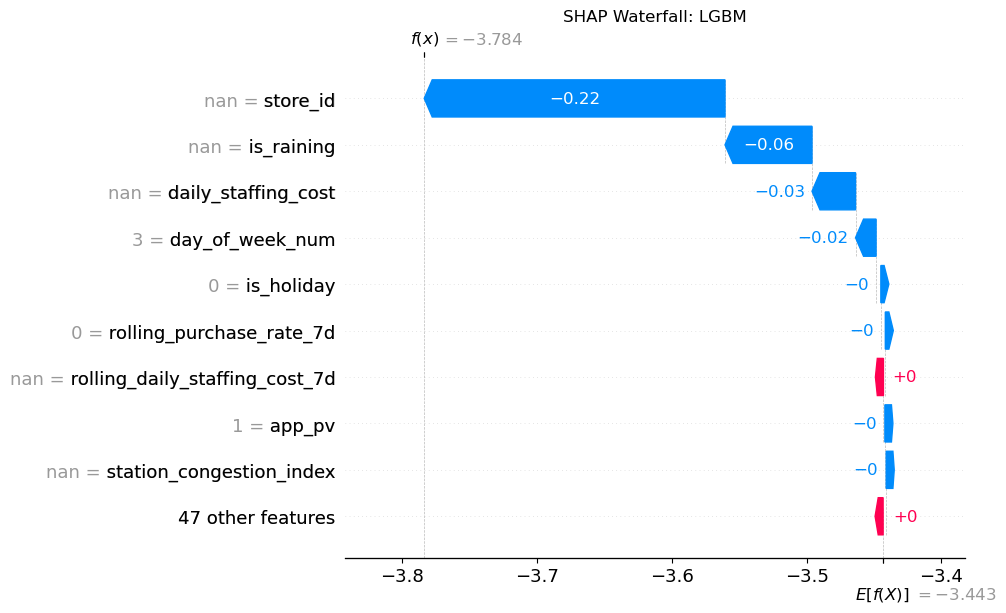

In [233]:
# waterfallをプロット
# ・

# # 1. 狙いたいインデックス（顧客IDなど）を指定
# target_id = 4  # これが DataFrame の index だとする
# # 2. test_df のインデックスから「行番号（0からの連番）」を取得
# target_row_num = df1.index.get_loc(target_id)


# 1. 狙いたいインデックス（顧客IDなど）を指定
target_id = 4  # これが DataFrame の index だとする

# 2. df1 のインデックスから「行番号（0からの連番）」を取得
target_row_num = df1.index.get_loc(target_id)

print(f"Index {target_id} は、dataframeの {target_row_num} 行目でした。")



shap.plots.waterfall(shap_values_obj[target_row_num], max_display=10, show=False)
plt.title(f"SHAP Waterfall: LGBM")
plt.show()


# fig, axes = plt.subplots(3, 2, figsize=(16, 12))
# # s-learner
# plt.sca(axes[0, 0])
# shap.plots.waterfall(exp_s[target_row_num], show=False, max_display=10)
# axes[0, 0].set_title('S-Learner: LGBM')

# # 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
# axes[0, 1].axis('off')

# # t-learner(treat)
# plt.sca(axes[1, 0])
# shap.plots.waterfall(exp_t_t[target_row_num], show=False, max_display=10)
# axes[1, 0].set_title('T-Learner, Treat: LGBM')

# # t-learner(control)
# plt.sca(axes[1, 1])
# shap.plots.waterfall(exp_t_c[target_row_num], show=False, max_display=10)
# axes[1, 1].set_title('T-Learner, Control: LGBM')

# # x-learner(treat)
# plt.sca(axes[2, 0])
# shap.plots.waterfall(exp_x_t[target_row_num], show=False, max_display=10)
# axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')

# # x-learner(control)
# plt.sca(axes[2, 1])
# shap.plots.waterfall(exp_x_c[target_row_num], show=False, max_display=10)
# axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')


# fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
# fig.suptitle(f'SHAP Waterfall: Index {target_id} of test_df (=row number {target_row_num} of exp_*)', fontsize=16)
# plt.tight_layout()
# # plt.tight_layout(rect=[0, 0, 1, 0.96]) # タイトルのスペースを空けるための調整
# plt.show()

In [234]:
# 1. このwater fallが意味すること（T-Learner: model_t）
# t-learnerのmodel_tの予測に基づいてプロットしてるということは、処置群においてis_purchasedする確率に対する影響度を表現してる
# 「赤が長いほど買う確率を大きく上げ、青が長いほど下げる」と読む

# 目的: 「もしクーポンをあげた場合、この人は買う（is_purchased=1）かどうか」の予測。
# 解釈: E[f(X)]=0.325（平均的な購買確率）からスタートして、この人の個別の事情（赤・青のバー）を足し引きした結果、f(x)=1.22（最終的なスコア）に到達した、という流れ。
# ちょっとした技術的補足
# 最終スコアが 1.22 と 1.0（確率100%）を超えてるのは、分類モデルの「確率」そのものではなく、その手前の「ロジット（Logit）」という値で計算されているため。

# 2. 縦軸のグレーの数値の意味
# Index 6252番さんの実際のデータ（観測値）が表示されてる。
# Store_B = store_id: この人は「店舗B」を利用している。
# 0.318 = past_coupon_usage_rate: 過去のクーポン利用率が約32%。
# 13 = visit_frequency: 来店頻度が13回。
# これらが並んでいるおかげで、「この人は来店頻度が13回とちょい多めだからスコアが+0.03押し上げられたんだな」という風に、「事実」と「影響度（SHAP）」をセットで読み解けるようになってる。
# 3. この人の特徴を読み解くと……
# この 6252番さんは、モデルから見るとかなり「有望（買う確率が高い）」と判断されてる。
# 最大のプラス要因: store_id (Store_B) です。この店舗を利用していることが、購買意欲を強烈に押し上げてる（+0.5）。
# マイナス要因: past_latte_ratio (0.33) ラテを飲む割合が33%程度であることが、この人に関しては少しマイナス（-0.23）に働いてる。

## SHAP scatter
- SHAP値でPartial Dependence Plotのようなグラフを描くこともできる


In [235]:
# SHAP Dependence Plot

# 特定の変数（例：membership_years）について、横軸に変数の値、縦軸にSHAP値をプロットする。
# メリット: PDP（Partial Dependence Plot）と似ているが、「個々のデータのバラツキが見える」ので、この値を超えると急にプラスに転じるなといった非線形な動きが見えやすい。
# 自動で「もっとも交互作用（Interaction）が強い別の変数」で色分けしてくれるので、予期せぬ発見がある。

# 例として 'membership_years' を指定
# shap_target_feature = 'membership_years'
shap_target_feature = 'past_coupon_usage_rate'

# Scatterプロットを実行（特定の変数を指定）色分けは自動で決まる
shap.plots.scatter(shap_values_obj[:, shap_target_feature], color=shap_values_obj, show=False)
plt.title(f'SHAP Dependence Plot: {shap_target_feature}\n(T-Learner, Treat: LGBM)')
plt.show()

# 1. 「入会したて」と「超常連」で効き方が違う
# 初期（0〜1年目）: SHAP値がプラスに振れてる。入会したばかりの人はクーポンがあると購入確率が上がりやすい。新奇性効果的なのかも。
# 中期（2〜3年目）: このあたりでSHAP値が一度マイナス（-0.1以下）に沈んでる。入会してしばらく経ち、少し飽きや慣れが来てのかも。
# 長期（4〜6年目）: そこからまた少し持ち直して、0付近やプラスに戻る層が出てる。長期常連客はまた違った反応を見せているらしい。

# 2. 色分け（past_latte_ratio）との興味深い関係
# 右側のカラーバーを見ると、past_latte_ratio（ラテ率）が相互作用として選ばれてる。
# 1〜2年目の沈んでいる層: 青い点（ラテ率が低い人）が目立ちます。
# 5年前後でプラスに浮上している層: 赤い点（ラテ率が高い人）が混ざってる。
# 解釈: 入会して数年経ち、かつラテをあまり飲まない人は、会員年数が長くなるほどむしろ購入確率（への貢献）が下がってしまうけれど、
# ラテ好きの常連さんになれば、年数が経ってもプラスの反応を維持できる、といった構造なのかも

# 3. PDP（平均）だけでは絶対に見えない「バラツキ」
# この図の一番のポイントは、同じ会員年数でも上下に大きくバラついていること。
# PDPだとこのバラツキが全部平均されて、なんとなく横ばいみたいな線になってるかも。

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

# PDP
Partial Dependence Plot  
- 特定の特徴量を変化させたときの、予測値の平均的な推移。SHAPをもっと直感的に説明するのに向いてる
- 変数の値が変化した際、予測対象がどう動くかの平均的な振る舞いを見る
- SHAPは点だけどこれは線なので「気温10度以下だとクーポンの効果が上がりやすそう」といった具体的なルールを提案しやすくなる
  - とはいえSHAPとは意味が違う。SHAPは予測値への貢献度の内訳を見てる（他の変数との相関もひっくるめて、実際のデータでの貢献度）
  - PDPは他の変数がどうであれ、その変数を変えたらどうなるかを見てる（他の変数は固定でその変数だけ仮想的に書き換えた予測値の平均）

In [236]:
df_shap_importance['feature'].head(10).tolist()

['store_id',
 'is_raining',
 'daily_staffing_cost',
 'day_of_week_num',
 'rolling_purchase_rate_7d',
 'is_holiday',
 'app_pv',
 'rolling_daily_staffing_cost_7d',
 'rolling_station_congestion_index_7d',
 'rolling_current_temp_7d']

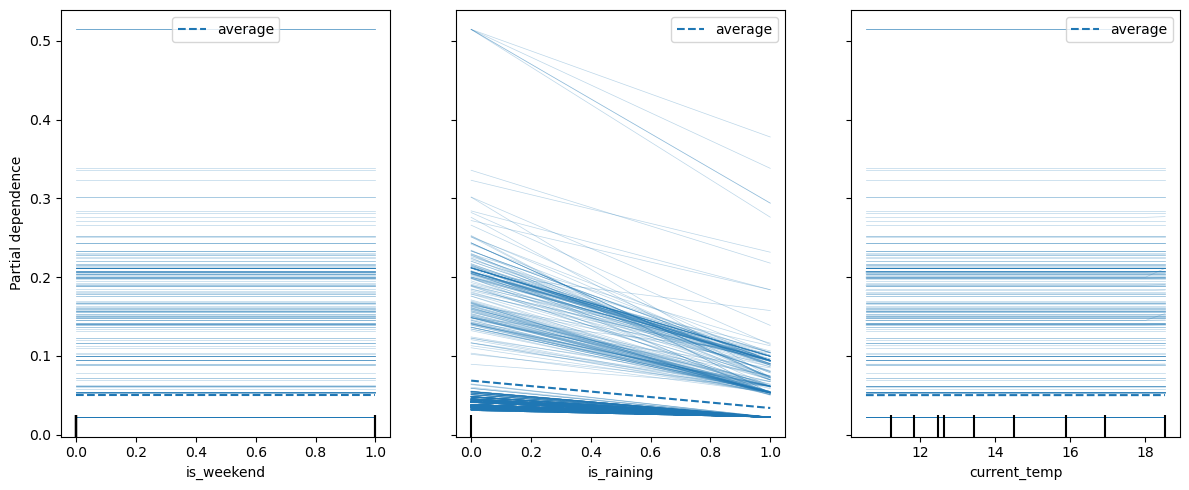

In [237]:
from sklearn.inspection import PartialDependenceDisplay

# どの特徴量のPDPを見たいか指定する
# features = ['past_latte_ratio', 'current_temp']
# features = X_train.columns.tolist()  # 全特徴量のPDPを見たいときはこれでOK
# features = df_shap_importance['feature'].head(5).tolist()

features = [
    # 'past_latte_ratio',
#  'is_treatment',
#  'past_coupon_usage_rate',
 'is_weekend',
 'is_raining',
 'current_temp',
]


# 描画（モデルとデータを渡すだけ！）
fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(model, X_val_sample, features, ax=ax, kind='both')
plt.tight_layout()
plt.show()

# predict test

In [238]:
# テストデータの予測確率（0.0〜1.0）を出す
y_pred_test = model.predict_proba(X_test)[:, 1]

# 元のデータフレームに予測値をくっつけると、後で分析しやすいよ
df_test_result = df_test.copy()
df_test_result['predict_prob'] = y_pred_test

# 確率が高い順に並べてみる
print(df_test_result[['customer_id', 'date', 'predict_prob']].sort_values('predict_prob', ascending=False).head())

       customer_id       date  predict_prob
182907    0xczrcym 2025-11-15      0.514607
182864    0zj369td 2025-11-15      0.514607
201162    jy4u0q64 2025-11-22      0.514607
204101    hw31mljq 2025-11-23      0.514607
204102    b1tpdhtz 2025-11-23      0.514607


# for auto ml

In [239]:
# スピード感を持って実力を出すなら AutoML（PyCaretなど） を使うのはめちゃくちゃ賢い選択。
# 「1つずつモデルを理解して進める道」と、「AutoMLで一気に最適解を探す道」。それぞれのメリットを整理。

# 1. なぜAutoML（PyCaretなど）が「最強」と言われるのか
# PyCaretのようなツールを使うと、以下の作業を全自動でやってくれる。
# 一括比較: compare_models() 1行で、LGBM、XGBoost、RandomForest、ロジスティック回帰などを一気に戦わせて、ランキングを作ってくれる。
# 自動チューニング: 面倒なハイパーパラメータ調整も、裏側で勝手に「一番いい組み合わせ」を探してくれる。
# 前処理の自動化: 欠損値処理やカテゴリ変数のエンコーディングも、お作法通りにやってくれるからミスが減る。

# 2. じゃあ、手動でやってることは無駄なの？
# 全然そんなことない！むしろ、手動でやった経験があるからこそ、AutoMLを使いこなせるようになる。
# 「なぜその精度が出たか」を説明できる: AutoMLは結果を出すのは速いけど、「なぜこの変数が効いたのか」「なぜこのモデルが選ばれたのか」を深掘りするには、SHAPや混同行列の知識が絶対に必要になる。
# 「変なデータ」に気づける: AutoMLは「とりあえず計算」しちゃうから、データにリーク（未来のデータが混じってる）があっても、ありえない高スコアを出してスルーしちゃうことがあるんだ。今の「おさらい」があれば、その違和感に気づけるよ。

# 3. 提案：ハイブリッド戦略
# AutoMLで「アタリ」をつける:
# PyCaretで一気に全モデルを比較して、今回のラテデータに一番相性がいいアルゴリズムを見つける。

# 上位のモデルを「深掘り」する:
# 選ばれた上位1〜2つのモデル（例えばLGBMとCatBoostなど）を、今作った「自作テンプレ（SHAP, PDP, 混同行列）」に流し込んで、中身をじっくり診察する。